# Setup

In [1]:
# imports 
%reload_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path
import xarray as xr
import pandas as pd

from scipy.signal import sosfiltfilt, butter, welch
from scipy.stats import entropy, skew, kurtosis, ks_2samp, wasserstein_distance

os.environ['KERAS_BACKEND'] = 'torch'
os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = '1'

import torch
import keras
from meegkit import dss

import mne
from mne.time_frequency import psd_array_welch
from src.EEGModalNet.preprocessing.preprocessing import preprocess_data
from src.EEGModalNet.models.FiLMGAN import FiLMGAN

from dataclasses import dataclass
from typing import Dict, Sequence, Tuple, Optional, List
from matplotlib.lines import Line2D
from matplotlib.colors import TwoSlopeNorm


# helper functions
def segment_data(x, time_dim):
    return torch.tensor(x.copy()).unfold(2, time_dim, time_dim).permute(0, 2, 3, 1).flatten(0, 1)

def reverse_segmentation(x, n_subjects):
    return x.unflatten(0, (n_subjects, -1)).flatten(1, 2).permute(0, 2, 1)
      
def generate_data(
    model,
    x,
    sub,
    pos,
    n_subjects,
    latent_dim=128,
    use_random_sub=False,
    device=None,
):
    """
    x:      (B, T, C) real data (only used for shape / optional stats later)
    sub:    (B, 1) subject ids for each segment
    pos:    (B, T, D_pos) positional encodings
    """

    model.generator.eval()

    if device is None:
        # infer device from model
        device = next(model.generator.parameters()).device
    else:
        device = torch.device(device)

    x      = x.float().to(device)
    sub    = sub.to(device)
    pos    = pos.to(device)

    B, T, C = x.shape
    x_gen   = torch.zeros_like(x)

    # assume balanced per-subject chunks
    bs = B // n_subjects
    n_chunks = B // bs

    for i in range(n_chunks):
        start = i * bs
        end   = (i + 1) * bs

        if use_random_sub:
            # sample labels uniformly in [0, n_subjects)
            sub_batch = torch.randint(0, n_subjects, (bs, 1), device=device)
        else:
            sub_batch = sub[start:end]

        z = torch.randn(bs, latent_dim, device=device)
        pos_batch = pos[start:end]

        with torch.no_grad():
            x_gen_batch = model.generator((z, sub_batch, pos_batch))
        x_gen[start:end] = x_gen_batch.cpu()

    # handle residual if B not divisible by bs
    tr_sh = (B // bs) * bs
    if tr_sh < B:
        res = B - tr_sh
        print("creating the residuals")

        if use_random_sub:
            sub_batch = torch.randint(0, n_subjects, (res, 1), device=device)
        else:
            sub_batch = sub[-res:]

        z = torch.randn(res, latent_dim, device=device)
        pos_batch = pos[-res:]

        with torch.no_grad():
            x_gen_tail = model.generator((z, sub_batch, pos_batch))
        x_gen[-res:] = x_gen_tail.cpu()

    return x_gen

def calculate_psd_different_methods(x, x_gen, n_subjects, psd_method='reorder_first', decibel=True):

    if psd_method == 'reverse_first':
        psd, freq = psd_array_welch(reverse_segmentation(x, n_subjects).numpy(), sfreq=128, fmin=1, fmax=60, n_fft=512, verbose=False)
        psd_gen, freq_gen = psd_array_welch(reverse_segmentation(x_gen, n_subjects).numpy(), sfreq=128, fmin=1, fmax=60, n_fft=512, verbose=False)

    if psd_method == 'flat_first':
        psd, freq = psd_array_welch(x.flatten(0, 1).permute(1, 0).numpy(), sfreq=128, fmin=1, fmax=60, n_fft=512, verbose=False)
        psd_gen, freq_gen = psd_array_welch(x_gen.flatten(0, 1).permute(1, 0).numpy(), sfreq=128, fmin=1, fmax=60, n_fft=512, verbose=False)

    if psd_method == 'reorder_first':
        psd, freq = psd_array_welch(x.permute(0, 2, 1).numpy(), sfreq=128, fmin=1, fmax=50, n_fft=512, verbose=False)
        psd_gen, freq_gen = psd_array_welch(x_gen.permute(0, 2, 1).numpy(), sfreq=128, fmin=1, fmax=50, n_fft=512, verbose=False)
    
    if decibel:
        psd = 10 * np.log10(np.clip(psd, 1e-12, None))
        psd_gen = 10 * np.log10(np.clip(psd_gen, 1e-12, None))
        
    return psd, psd_gen, freq


@dataclass
class ConditionData:
    raw_real: np.ndarray                  # (subjects, channels, times)
    raw_gen: np.ndarray                   # (subjects, channels, times)
    psd_real: np.ndarray                  # (subjects, channels, freqs)
    psd_gen: np.ndarray                   # (subjects, channels, freqs)
    conn_real: Dict[str, np.ndarray]      # band -> (subjects, channels, channels)
    conn_gen: Dict[str, np.ndarray]       # band -> (subjects, channels, channels)

# Data

In [2]:
# Data Parameters
TIME_DIM = 512
N_SUBJECTS = 202
CHANNELS = ['O1', 'O2', 'P1', 'P2', 'C1', 'C2', 'F1', 'F2']

# REAL DATA
def open_real_data(eeg_data_path, channels, n_subjects=202, time_dim=512, condition='EC'):
    xarray = xr.open_dataarray(eeg_data_path, engine='h5netcdf')

    x = xarray.sel(subject=xarray.subject[:n_subjects], channel=channels)
    x = x.to_numpy()

    # preprocess
    x = preprocess_data(x, sampling_rate=128)

    # filter
    sos = butter(4, 0.5, btype='high', fs=128, output='sos')
    x = sosfiltfilt(sos, x, axis=-1)

    # line noise removal
    x, _ = dss.dss_line(x.T, fline=50, sfreq=128, nremove=1)
    x = x.T

    raw_real = x.copy()
    x = segment_data(x, time_dim)
    sub = torch.tensor(np.arange(0, n_subjects).repeat(x.shape[0]//n_subjects)[:, np.newaxis])

    fill_v = 0 if condition == 'EC' else 1
    state = torch.full_like(sub, fill_value=fill_v) 
    return x, sub, state, raw_real

In [3]:
# Connectivity
from mne_connectivity import spectral_connectivity_time

def spectral_coonnectivity_subject_wise(x, N_SUBJECTS, fmin, fmax):
    all_conns = np.zeros([N_SUBJECTS, 8, 8, 5])
    x_rev = reverse_segmentation(x, N_SUBJECTS).numpy()
    for i in range(N_SUBJECTS):
        x_ind = np.array(np.array_split(x_rev[i], 16, axis=1))  # 30 seconds segments
        print(f'>>>>> subject {i+1}')
        cons_ind = spectral_connectivity_time(x_ind, freqs=np.arange(1, 45, 1), method='coh', sfreq=128, n_jobs=1, fmin=fmin, fmax=fmax, verbose=0, average=True, faverage=True)
        all_conns[i, ...] = cons_ind.get_data(output='dense')
    return all_conns

fs = 128
bands = {
    "delta": (1, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta":  (13, 30),
    "gamma": (30, 45),
}
band_names = list(bands.keys())
fmin = np.array([lo for (lo, hi) in bands.values()], dtype=float)
fmax = np.array([hi for (lo, hi) in bands.values()], dtype=float)

In [4]:
def make_condition_data(channels, model, fmin, fmax, condition='EC', n_subjects=202, return_only_raw=False):
    eeg_data_path = f'data/LEMON_data/{condition}_ch-8_sf-128.nc5'
    x, sub, state, raw_real = open_real_data(eeg_data_path, channels=channels, n_subjects=n_subjects, condition=condition)
    with torch.no_grad():
        x_gen = generate_data(model, x, sub, state, n_subjects, latent_dim=128, use_random_sub=False).detach().cpu()
    raw_gen = reverse_segmentation(x_gen, n_subjects).numpy()

    if return_only_raw:
        return x, x_gen, sub, state

    # PSD
    psd_real, psd_gen, freqs = calculate_psd_different_methods(x, x_gen, n_subjects, psd_method='reverse_first')

    # connectivity
    conn_real = spectral_coonnectivity_subject_wise(x, n_subjects, fmin, fmax)
    conn_real = {
        "delta": conn_real[:, :, :, 0],
        "theta": conn_real[:, :, :, 1],
        "alpha": conn_real[:, :, :, 2],
        "beta":  conn_real[:, :, :, 3],
        "gamma": conn_real[:, :, :, 4],
    }
    conn_gen = spectral_coonnectivity_subject_wise(x_gen, n_subjects, fmin, fmax)
    conn_gen = {
        "delta": conn_gen[:, :, :, 0],
        "theta": conn_gen[:, :, :, 1],
        "alpha": conn_gen[:, :, :, 2],
        "beta":  conn_gen[:, :, :, 3],
        "gamma": conn_gen[:, :, :, 4],
    }
    return ConditionData(
           raw_real=raw_real,
           raw_gen=raw_gen,
           psd_real=psd_real,
           psd_gen=psd_gen,
           conn_real=conn_real,
           conn_gen=conn_gen)


# fake data
CHECKPOINTS_PATH = 'logs/eo/20260330_epoch_200.model.keras'
model = keras.saving.load_model(CHECKPOINTS_PATH, custom_objects={'FiLMGAN': FiLMGAN}, compile=False)

# condition_data_eo = make_condition_data(CHANNELS, model, fmin, fmax, condition='EO', n_subjects=N_SUBJECTS)
# condition_data_ec = make_condition_data(CHANNELS, model, fmin, fmax, condition='EC', n_subjects=N_SUBJECTS)

In [5]:
import pickle
with open('data/viz/condition_data_eo.pkl', 'rb') as f:
     condition_data_eo = pickle.load(f)

with open('data/viz/condition_data_ec.pkl', 'rb') as f:
     condition_data_ec = pickle.load(f)

# Figure 1: Fidelity of generated data

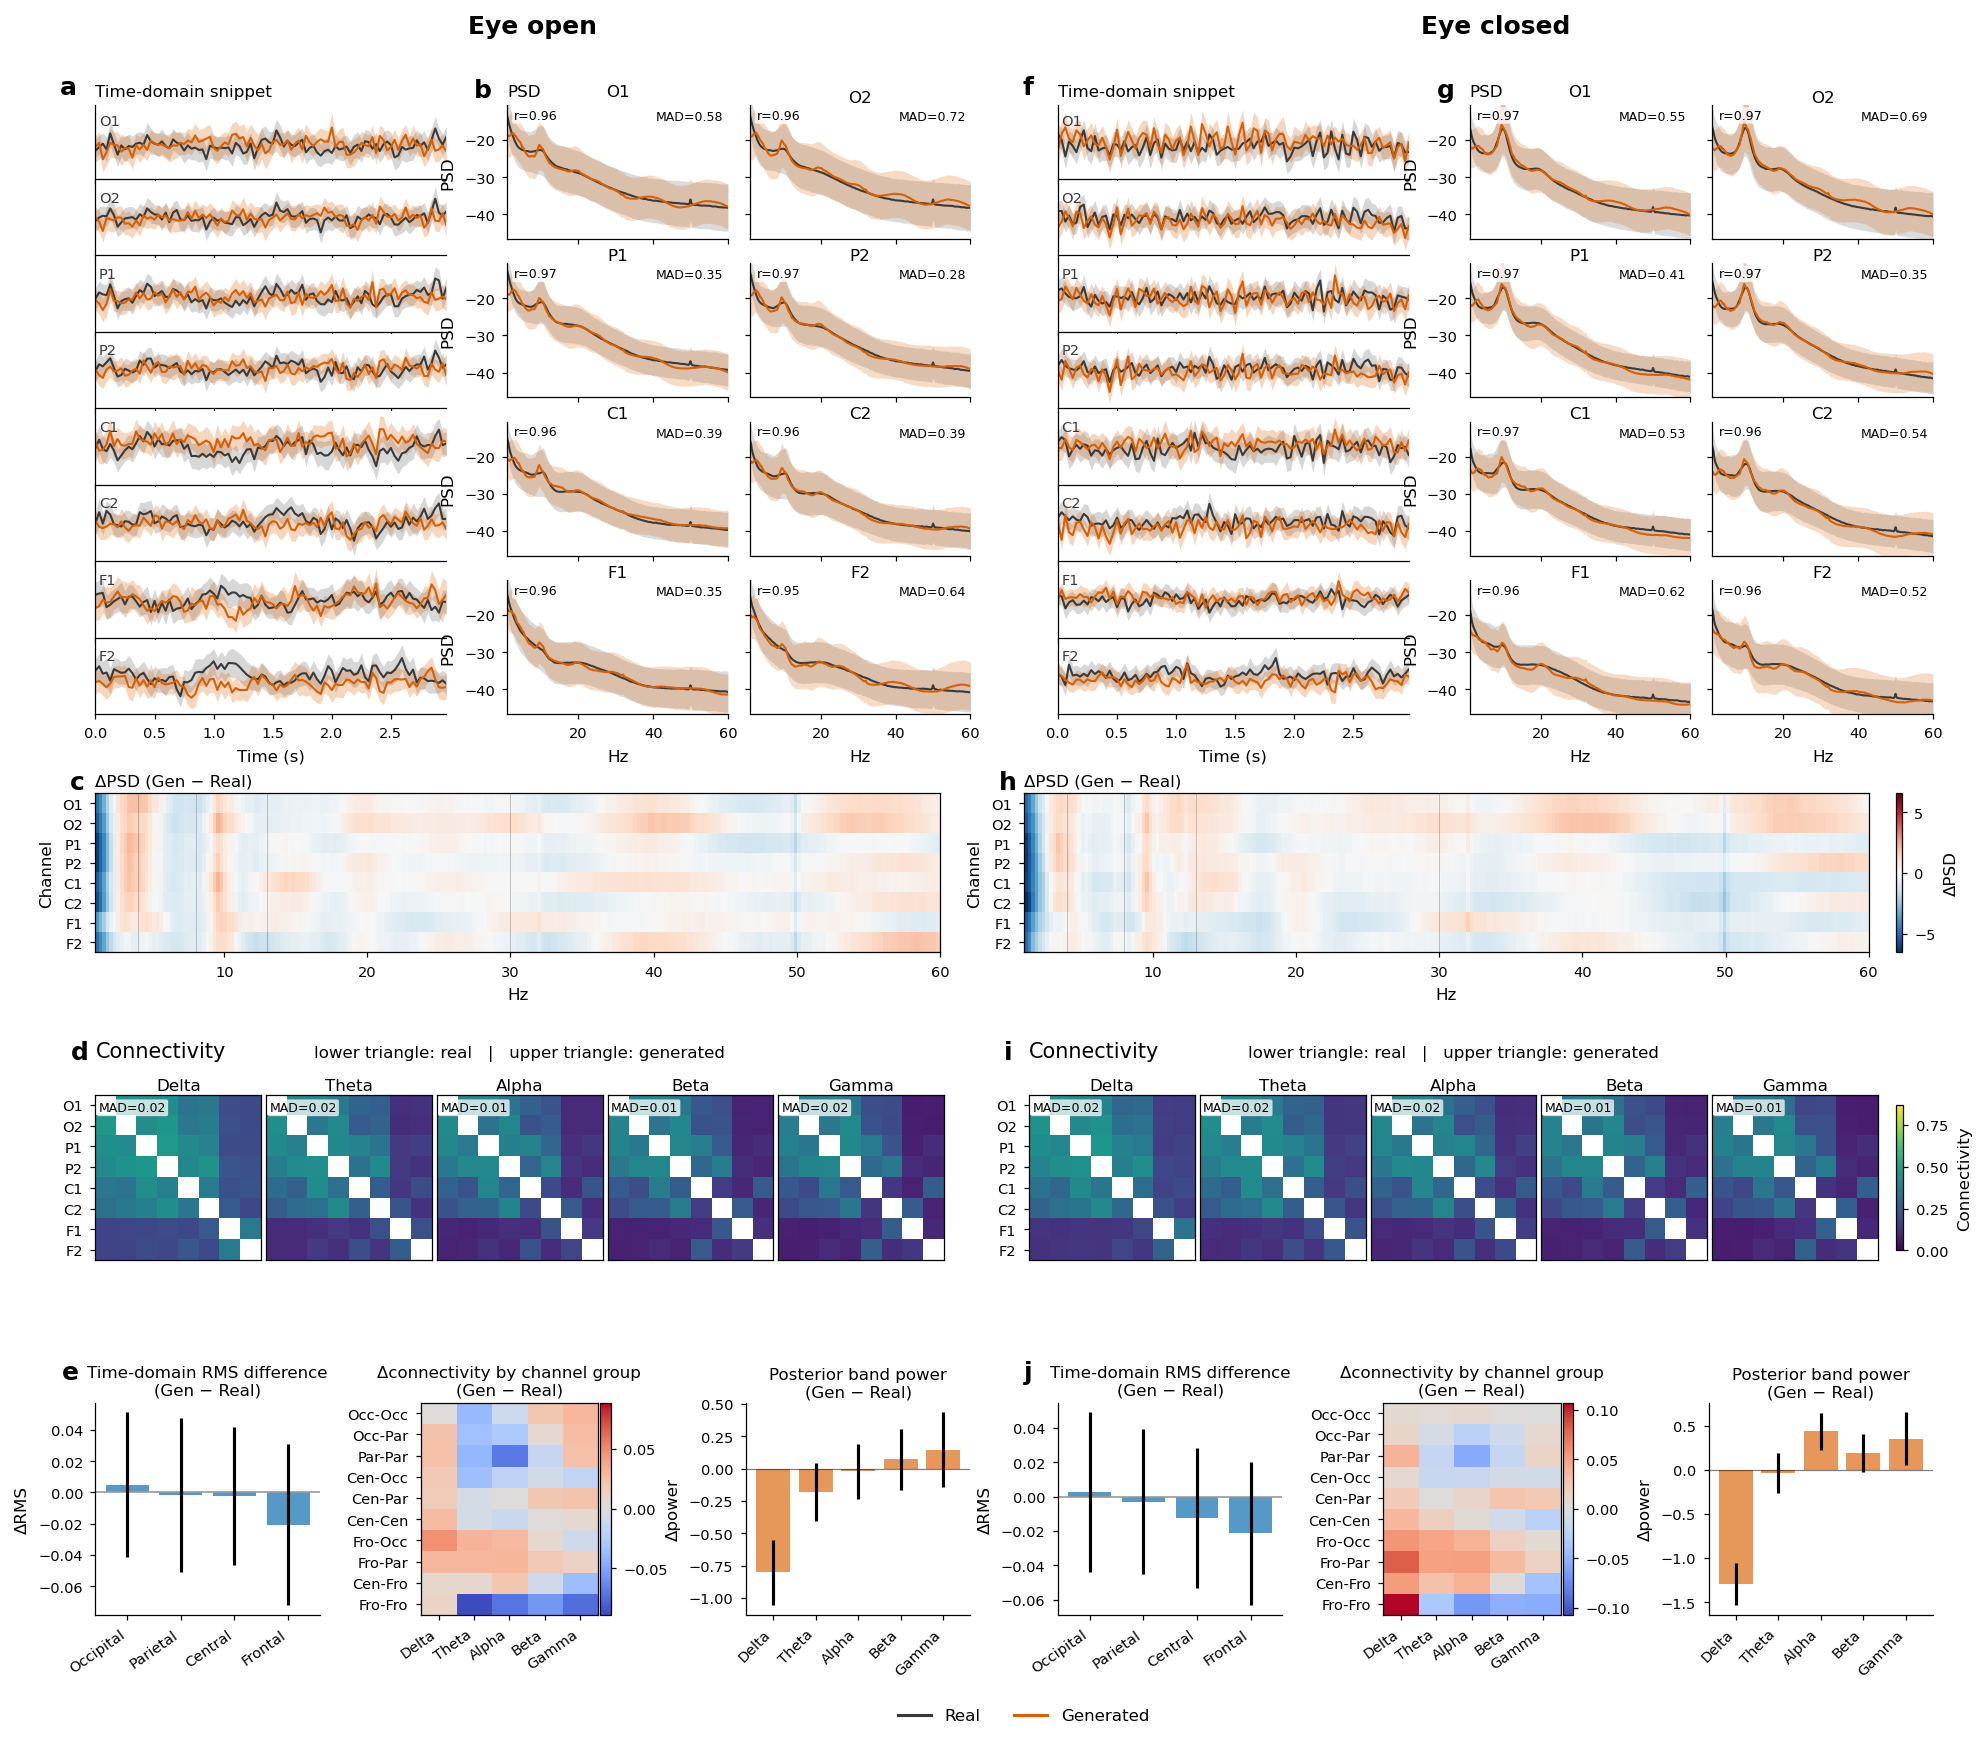

In [8]:
# -----------------------------------------------------------------------------
# Style
# -----------------------------------------------------------------------------

def set_publication_style() -> None:
    plt.rcParams.update({
        "font.family": "sans-serif",
        "font.size": 8,
        "axes.titlesize": 8,
        "axes.labelsize": 8,
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
        "legend.fontsize": 8,
        "axes.linewidth": 0.6,
        "xtick.major.width": 0.6,
        "ytick.major.width": 0.6,
        "xtick.major.size": 2.5,
        "ytick.major.size": 2.5,
        "savefig.dpi": 300,
        "figure.dpi": 150,
    })


# -----------------------------------------------------------------------------
# Small utilities
# -----------------------------------------------------------------------------

def mean_ci(x: np.ndarray, axis: int = 0, z: float = 1.96, return_std=False) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Mean ± normal-approx CI. Can be Replaced with bootstrap"""
    mean = np.nanmean(x, axis=axis)
    n = np.sum(np.isfinite(x), axis=axis)
    std = np.nanstd(x, axis=axis, ddof=1)
    if return_std:
        return mean, mean - std, mean + std
    se = np.divide(std, np.sqrt(np.maximum(n, 1)), out=np.zeros_like(std), where=n > 0)
    err = z * np.nan_to_num(se, nan=0.0)
    return mean, mean - err, mean + err


def safe_corr(x: np.ndarray, y: np.ndarray) -> float:
    """Pearson r, safely."""
    x = np.asarray(x).ravel()
    y = np.asarray(y).ravel()
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]
    if x.size < 3:
        return np.nan
    if np.std(x) < 1e-12 or np.std(y) < 1e-12:
        return np.nan
    return float(np.corrcoef(x, y)[0, 1])


def upper_tri_values(mat: np.ndarray) -> np.ndarray:
    idx = np.triu_indices_from(mat, k=1)
    return mat[idx]


def symmetrize_conn_matrix(mat: np.ndarray) -> np.ndarray:

    """Mirror triangular connectivity values so both halves are populated."""

    mat = mat.astype(float, copy=False)

    return np.nanmean(np.stack([mat, mat.T], axis=0), axis=0)



def extract_snippet(x: np.ndarray, sfreq: float, seconds: float = 3.0, decim: int = 1, start: int = 0) -> Tuple[np.ndarray, np.ndarray]:
    """
    x: (subjects, channels, times)
    Returns snippet and time vector.
    """
    n_times = x.shape[-1]
    win = int(round(seconds * sfreq))
    win = min(win, n_times)
    s = max(start, (n_times - win) // 2)
    stop = s + win
    snippet = x[..., s:stop]
    if decim > 1:
        snippet = snippet[..., ::decim]
    t = np.arange(snippet.shape[-1]) / (sfreq / decim)
    return snippet, t


def band_mask(freqs: np.ndarray, band: Tuple[float, float]) -> np.ndarray:
    lo, hi = band
    return (freqs >= lo) & (freqs < hi)


def flatten_channel_grid(channel_grid: Sequence[Sequence[str]]) -> List[str]:
    return [ch for row in channel_grid for ch in row]


def add_panel_label(ax: plt.Axes, label: str, x: float = -0.15, y: float = 1.2) -> None:
    ax.text(
        x, y, label,
        transform=ax.transAxes,
        fontsize=12, fontweight="bold",
        va="top", ha="left"
    )


def prettify_condition(name: str) -> str:
    mapping = {"EO": "Eye open", "EC": "Eye closed"}
    return mapping.get(name, name)


# -----------------------------------------------------------------------------
# Limit computation for consistent scaling
# -----------------------------------------------------------------------------

def compute_time_ylims(
    conditions: Dict[str, ConditionData],
    sfreq: float,
    channel_order: Sequence[str],
    channel_to_idx: Dict[str, int],
    seconds: float = 3.0,
    decim: int = 4,
    pad_frac: float = 0.08,
) -> Dict[str, Tuple[float, float]]:
    ylims = {}
    for ch in channel_order:
        ch_idx = channel_to_idx[ch]
        vals = []
        for cond in conditions.values():
            for arr in (cond.raw_real, cond.raw_gen):
                snippet, _ = extract_snippet(arr[:, [ch_idx], :], sfreq=sfreq, seconds=seconds, decim=decim, start=34000)
                _, lo, hi = mean_ci(snippet[:, 0, :], axis=0)
                vals.append(np.nanmin(lo))
                vals.append(np.nanmax(hi))
        y0, y1 = min(vals), max(vals)
        pad = (y1 - y0) * pad_frac if y1 > y0 else 0.1
        ylims[ch] = (y0 - pad, y1 + pad)
    return ylims


def compute_psd_ylim(
    conditions: Dict[str, ConditionData],
    channel_order: Sequence[str],
    channel_to_idx: Dict[str, int],
    pad_frac: float = 0.05,
) -> Tuple[float, float]:
    vals = []
    ch_idx = [channel_to_idx[ch] for ch in channel_order]
    for cond in conditions.values():
        for arr in (cond.psd_real, cond.psd_gen):
            mean, lo, hi = mean_ci(arr[:, ch_idx, :], axis=0)
            vals.extend([np.nanmin(lo), np.nanmax(hi)])
    y0, y1 = min(vals), max(vals)
    pad = (y1 - y0) * pad_frac if y1 > y0 else 0.1
    return y0 - pad, y1 + pad


def compute_delta_psd_vlim(conditions: Dict[str, ConditionData]) -> float:
    vals = []
    for cond in conditions.values():
        delta = np.nanmean(cond.psd_gen, axis=0) - np.nanmean(cond.psd_real, axis=0)
        vals.append(np.nanmax(np.abs(delta)))
    return float(max(vals)) if vals else 1.0


def compute_conn_vrange(
    conditions: Dict[str, ConditionData],
    band_order: Sequence[str],
    robust_percentile: float = 99.0,
) -> Tuple[float, float]:
    vals = []
    for cond in conditions.values():
        for band in band_order:
            vals.append(np.nanmean(cond.conn_real[band], axis=0).ravel())
            vals.append(np.nanmean(cond.conn_gen[band], axis=0).ravel())
    vals = np.concatenate(vals)
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return 0.0, 1.0
    vmin = np.percentile(vals, 100 - robust_percentile)
    vmax = np.percentile(vals, robust_percentile)
    return float(vmin), float(vmax)


# -----------------------------------------------------------------------------
# Panel plotting helpers
# -----------------------------------------------------------------------------

def plot_stacked_time_snippet(
    fig: plt.Figure,
    subspec,
    real_raw: np.ndarray,
    gen_raw: np.ndarray,
    sfreq: float,
    channel_order: Sequence[str],
    channel_to_idx: Dict[str, int],
    colors: Dict[str, str],
    seconds: float = 3.0,
    decim: int = 4,
    ylims: Optional[Dict[str, Tuple[float, float]]] = None,
) -> List[plt.Axes]:
    sub = subspec.subgridspec(len(channel_order), 1, hspace=0.03)
    axes = []

    real_snip, t = extract_snippet(real_raw, sfreq=sfreq, seconds=seconds, decim=decim, start=34000)
    gen_snip, _ = extract_snippet(gen_raw, sfreq=sfreq, seconds=seconds, decim=decim, start=34000)

    real_mean, real_lo, real_hi = mean_ci(real_snip, axis=0, return_std=False)
    gen_mean, gen_lo, gen_hi = mean_ci(gen_snip, axis=0, return_std=False)

    for i, ch in enumerate(channel_order):
        ax = fig.add_subplot(sub[i, 0])
        idx = channel_to_idx[ch]

        ax.fill_between(t, real_lo[idx], real_hi[idx], color=colors["real"], alpha=0.20, lw=0)
        ax.fill_between(t, gen_lo[idx], gen_hi[idx], color=colors["gen"], alpha=0.25, lw=0)
        ax.plot(t, real_mean[idx], color=colors["real"], lw=1.0)
        ax.plot(t, gen_mean[idx], color=colors["gen"], lw=1.0)

        ax.text(0.01, 0.78, ch, transform=ax.transAxes, ha="left", va="center",
                color=colors["real"], fontsize=7)

        if ylims is not None and ch in ylims:
            ax.set_ylim(*ylims[ch])

        ax.set_xlim(t[0], t[-1])

        if i < len(channel_order) - 1:
            ax.set_xticklabels([])
        else:
            ax.set_xlabel("Time (s)")

        ax.set_yticks([])
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        axes.append(ax)

    return axes


def plot_psd_minigrid(
    fig: plt.Figure,
    subspec,
    real_psd: np.ndarray,
    gen_psd: np.ndarray,
    freqs: np.ndarray,
    channel_grid: Sequence[Sequence[str]],
    channel_to_idx: Dict[str, int],
    colors: Dict[str, str],
    ylim: Optional[Tuple[float, float]] = None,
    correlation_annotation: bool = True,
) -> List[plt.Axes]:
    n_rows = len(channel_grid)
    n_cols = len(channel_grid[0])
    sub = subspec.subgridspec(n_rows, n_cols, hspace=0.18, wspace=0.10)
    axes = []

    real_mean, real_lo, real_hi = mean_ci(real_psd, axis=0, return_std=True)
    gen_mean, gen_lo, gen_hi = mean_ci(gen_psd, axis=0, return_std=True)

    for r in range(n_rows):
        for c in range(n_cols):
            ch = channel_grid[r][c]
            idx = channel_to_idx[ch]
            ax = fig.add_subplot(sub[r, c])

            ax.fill_between(freqs, real_lo[idx], real_hi[idx], color=colors["real"], alpha=0.18, lw=0)
            ax.fill_between(freqs, gen_lo[idx], gen_hi[idx], color=colors["gen"], alpha=0.22, lw=0)
            ax.plot(freqs, real_mean[idx], color=colors["real"], lw=1.0)
            ax.plot(freqs, gen_mean[idx], color=colors["gen"], lw=1.0)

            ax.set_title(ch, pad=1.5)
            ax.set_xlim(freqs[0], freqs[-1])

            if ylim is not None:
                ax.set_ylim(*ylim)

            if r < n_rows - 1:
                ax.set_xticklabels([])
            else:
                ax.set_xlabel("Hz")

            if c > 0:
                ax.set_yticklabels([])
            else:
                ax.set_ylabel("PSD")
            
            if correlation_annotation:
                # corr = safe_corr(real_psd[:, idx, :].mean(axis=0), gen_psd[:, idx, :].mean(axis=0))
                corrs = [
                            safe_corr(real_psd[i, idx, :], gen_psd[i, idx, :])
                            for i in range(real_psd.shape[0])
                        ]
                corr = np.median(corrs)
                ax.text(0.03, 0.97, f"r={corr:.2f}", transform=ax.transAxes,
                        va="top", ha="left", fontsize=6,
                        bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.7))

            
            mad_psd = np.median(np.abs(real_psd[:, idx, :].mean(axis=0) -
                                    gen_psd[:, idx, :].mean(axis=0)))
            ax.text(
                0.98, 0.96, f"MAD={mad_psd:.2f}",
                transform=ax.transAxes,
                ha="right", va="top",
                fontsize=6,
                bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.75),
            )

            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
            axes.append(ax)

    return axes


def plot_delta_psd_heatmap(
    fig: plt.Figure,
    subspec,
    real_psd: np.ndarray,
    gen_psd: np.ndarray,
    freqs: np.ndarray,
    channel_order: Sequence[str],
    channel_to_idx: Dict[str, int],
    band_defs: Dict[str, Tuple[float, float]],
    vlim: float,
    cmap: str = "RdBu_r",
) -> Tuple[plt.Axes, plt.Axes]:
    ax = fig.add_subplot(subspec)

    idx = [channel_to_idx[ch] for ch in channel_order]
    delta = np.nanmean(gen_psd, axis=0) - np.nanmean(real_psd, axis=0)
    delta = delta[idx, :]

    norm = TwoSlopeNorm(vcenter=0.0, vmin=-vlim, vmax=vlim)

    im = ax.imshow(
        delta,
        aspect="auto",
        origin="upper",
        cmap=cmap,
        norm=norm,
        interpolation="nearest",
        extent=[freqs[0], freqs[-1], len(channel_order) - 0.5, -0.5],
    )

    ax.set_xlabel("Hz")
    ax.set_ylabel("Channel")
    ax.set_yticks(range(len(channel_order)))
    ax.set_yticklabels(channel_order)

    for _, (_, hi) in band_defs.items():
        if freqs[0] < hi < freqs[-1]:
            ax.axvline(hi, color="k", lw=0.4, alpha=0.25)

    return ax, im


def plot_connectivity_strip(
    fig: plt.Figure,
    subspec,
    conn_real: Dict[str, np.ndarray],
    conn_gen: Dict[str, np.ndarray],
    band_order: Sequence[str],
    channel_order: Sequence[str],
    channel_to_idx: Dict[str, int],
    vmin: float,
    vmax: float,
    cmap: str = "viridis",
    annot: bool = False,
    metric: str = "MAD",
) -> Tuple[List[plt.Axes], plt.Axes]:
    sub = subspec.subgridspec(1, len(band_order), wspace=0.03)
    axes = []

    cmap_obj = plt.get_cmap(cmap).copy()
    cmap_obj.set_bad("white")

    # reorder channels if needed
    reorder = [channel_to_idx[ch] for ch in channel_order]
    last_im = None

    for i, band in enumerate(band_order):
        ax = fig.add_subplot(sub[0, i])

        real_mean = symmetrize_conn_matrix(np.nanmean(conn_real[band], axis=0)[np.ix_(reorder, reorder)])
        gen_mean = symmetrize_conn_matrix(np.nanmean(conn_gen[band], axis=0)[np.ix_(reorder, reorder)])

        combo = np.full_like(real_mean, np.nan, dtype=float)
        lower = np.tril(np.ones_like(combo, dtype=bool), k=-1)
        upper = np.triu(np.ones_like(combo, dtype=bool), k=1)

        combo[lower] = real_mean[lower]
        combo[upper] = gen_mean[upper]

        r = safe_corr(upper_tri_values(real_mean), upper_tri_values(gen_mean))

        masked = np.ma.masked_invalid(combo)
        last_im = ax.imshow(masked, vmin=vmin, vmax=vmax, cmap=cmap_obj, interpolation=None)
        if annot:
            for row in range(combo.shape[0]):
                for col in range(combo.shape[1]):
                    if np.isfinite(combo[row, col]):
                        ax.text(
                            col, row, f"{combo[row, col]:.2f}",
                            ha="center", va="center",
                            fontsize=5, color="white"
                        )
        ax.set_title(band.capitalize(), pad=2)

        if i == 0:
            ax.set_yticks(range(len(channel_order)))
            ax.set_yticklabels(channel_order)
        else:
            ax.set_yticks([])

        ax.set_xticks([])

        if metric == "r":
            ax.text(0.03, 0.97, f"r={r:.2f}", transform=ax.transAxes,
                    va="top", ha="left", fontsize=6,
                    bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.7))
        elif metric == "MAD":
            mask = ~np.eye(real_mean.shape[0], dtype=bool)   # exclude diagonal
            mad_conn = np.mean(np.abs(gen_mean[mask] - real_mean[mask]))

            ax.text(
                0.02, 0.96, f"MAD={mad_conn:.2f}",
                transform=ax.transAxes,
                ha="left", va="top",
                fontsize=6,
                bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.75),
            )
        else:
            raise ValueError("metric must be 'r' or 'MAD'")
        axes.append(ax)

    return axes, last_im

def compute_posterior_band_power_delta(
    real_psd: np.ndarray,
    gen_psd: np.ndarray,
    freqs: np.ndarray,
    band_defs: Dict[str, Tuple[float, float]],
    posterior_channels: Sequence[str],
    channel_to_idx: Dict[str, int],
) -> Dict[str, Tuple[float, float]]:
    idx = [channel_to_idx[ch] for ch in posterior_channels if ch in channel_to_idx]
    if len(idx) == 0:
        idx = list(range(real_psd.shape[1]))

    out = {}
    for band, fr in band_defs.items():
        mask = band_mask(freqs, fr)
        # subject-level signed difference
        subj_diff = (
            np.nanmean(gen_psd[:, idx][:, :, mask], axis=(1, 2))
            - np.nanmean(real_psd[:, idx][:, :, mask], axis=(1, 2))
        )
        m, lo, hi = mean_ci(subj_diff[:, None], axis=0)
        err = max(abs(m[0] - lo[0]), abs(hi[0] - m[0]))
        out[band] = (float(m[0]), float(err))
    return out

def compute_group_time_difference(
    raw_real,
    raw_gen,
    channel_groups,
    channel_to_idx,
    metric="rms",
):

    group_names = list(channel_groups.keys())
    mean_diff = np.zeros(len(group_names))
    err_diff = np.zeros(len(group_names))

    for gi, gname in enumerate(group_names):
        ch_idx = [channel_to_idx[ch] for ch in channel_groups[gname]]

        x_r = raw_real[:, ch_idx, :]
        x_g = raw_gen[:, ch_idx, :]

        if metric == "rms":
            real_val = np.sqrt((x_r ** 2).mean(axis=(1, 2)))
            gen_val  = np.sqrt((x_g ** 2).mean(axis=(1, 2)))
        elif metric == "var":
            real_val = x_r.var(axis=(1, 2))
            gen_val  = x_g.var(axis=(1, 2))
        else:
            raise ValueError("metric must be 'rms' or 'var'")

        diff = gen_val - real_val
        mean_diff[gi] = diff.mean()
        err_diff[gi] = diff.std(ddof=1)

    return mean_diff, err_diff, group_names

def compute_group_bandpower_delta(
    real_psd,
    gen_psd,
    freqs,
    channel_groups,
    channel_to_idx,
    band_defs,
):
    group_names = list(channel_groups.keys())
    band_names = list(band_defs.keys())

    n_subj = real_psd.shape[0]
    mean_diff = np.zeros((len(group_names), len(band_names)))
    err_diff = np.zeros((len(group_names), len(band_names)))

    for gi, gname in enumerate(group_names):
        ch_idx = [channel_to_idx[ch] for ch in channel_groups[gname]]

        for bi, bname in enumerate(band_names):
            f1, f2 = band_defs[bname]
            m = (freqs >= f1) & (freqs < f2)

            real_bp = real_psd[:, ch_idx][:, :, m].mean(axis=(1, 2))  # per subject
            gen_bp  = gen_psd[:, ch_idx][:, :, m].mean(axis=(1, 2))

            diff = gen_bp - real_bp
            mean_diff[gi, bi] = diff.mean()
            err_diff[gi, bi] = diff.std(ddof=1)

    return mean_diff, err_diff, group_names, band_names

def compute_pairwise_connectivity_delta(conn_real, conn_gen, band_names=None, include_diag=False):
    """
    conn_real, conn_gen: (n_subj, n_ch, n_ch, n_bands)

    Returns:
      mean_diff: (n_pairs, n_bands)   # mean(gen - real) across subjects
      err_diff:  (n_pairs, n_bands)   # std(gen - real) across subjects
      pair_names: list[str]
      band_names: list[str]
    """
    n_subj, n_ch, _, n_bands = conn_real.shape

    if band_names is None:
        band_names = ["Delta", "Theta", "Alpha", "Beta", "Gamma"][:n_bands]

    k = 0 if include_diag else -1
    ii, jj = np.tril_indices(n_ch, k=k)

    # extract pair values: (n_subj, n_pairs, n_bands)
    real_pairs = conn_real[:, ii, jj, :]
    gen_pairs  = conn_gen[:, ii, jj, :]

    # per-subject difference
    diff = gen_pairs - real_pairs   # (n_subj, n_pairs, n_bands)

    # summarize across subjects
    mean_diff = diff.mean(axis=0)                 # (n_pairs, n_bands)
    err_diff  = diff.std(axis=0, ddof=1)          # (n_pairs, n_bands)

    pair_names = [f"{i}-{j}" for i, j in zip(ii, jj)]

    return mean_diff, err_diff, pair_names, band_names

from collections import defaultdict

def aggregate_pair_diffs_to_region_groups(
    mean_diff, err_diff, pair_names, channel_names, channel_to_region=None
):
    """
    mean_diff, err_diff: (n_pairs, n_bands)
    pair_names: like ['1-0', '2-0', ...]
    channel_names: ['O1','O2','P1','P2','C1','C2','F1','F2']
    """
    group_rows = defaultdict(list)

    if channel_to_region is None:
        channel_to_region = {
            "O1": "Occ", "O2": "Occ",
            "P1": "Par", "P2": "Par",
            "C1": "Cen", "C2": "Cen",
            "F1": "Fro", "F2": "Fro",
        }

    for row_idx, pair in enumerate(pair_names):
        i, j = map(int, pair.split("-"))
        r1 = channel_to_region[channel_names[i]]
        r2 = channel_to_region[channel_names[j]]

        # sort so Occ-Par and Par-Occ collapse into same key
        key = "-".join(sorted([r1, r2]))
        group_rows[key].append(row_idx)

    group_names = list(group_rows.keys())
    group_mean = np.zeros((len(group_names), mean_diff.shape[1]))
    group_err = np.zeros((len(group_names), mean_diff.shape[1]))
    n_edges = np.zeros(len(group_names), dtype=int)

    for gi, gname in enumerate(group_names):
        rows = group_rows[gname]
        group_mean[gi] = mean_diff[rows].mean(axis=0)
        group_err[gi] = mean_diff[rows].std(axis=0, ddof=1) if len(rows) > 1 else 0.0
        n_edges[gi] = len(rows)

    return group_mean, group_err, group_names, n_edges


def plot_summary_row(
    fig: plt.Figure,
    subspec,
    real_psd: np.ndarray,
    gen_psd: np.ndarray,
    freqs: np.ndarray,
    raw_real: np.ndarray,
    raw_gen: np.ndarray,
    conn_real: Dict[str, int],
    conn_gen: Dict[str, int],
    channel_groups: Dict[str, Sequence[str]],
    channel_to_idx: Dict[str, int],
    band_order: Sequence[str],
    band_defs: Dict[str, Tuple[float, float]],
    posterior_channels: Sequence[str],
    colors: Dict[str, str],
    metric: str = "rms",
) -> List[plt.Axes]:
    """
    Horizontal summary block:
      [PSD similarity by channel] [Connectivity similarity by band] [Posterior Δpower]
    """
    sub = subspec.subgridspec(1, 3, wspace=0.45)
    axes = []

    # ------------------------------------------------------------------
    # 1) Time-domain amplitude difference
    # ------------------------------------------------------------------
    ax1 = fig.add_subplot(sub[0, 0])
    mean_diff, err_diff, group_names = compute_group_time_difference(
        raw_real, raw_gen, channel_groups, channel_to_idx, metric=metric)

    x = np.arange(len(group_names))
    ax1.axhline(0, color="0.6", lw=0.8)
    ax1.bar(x, mean_diff, yerr=err_diff, alpha=0.75)
    ax1.set_xticks(x)
    ax1.set_xticklabels(group_names, rotation=35, ha="right")
    ax1.set_title(f"Time-domain {metric.upper()} difference\n(Gen − Real)", pad=4)
    ax1.set_ylabel(f"Δ{metric.upper()}")
    ax1.spines["top"].set_visible(False)
    ax1.spines["right"].set_visible(False)
    axes.append(ax1)

    # ------------------------------------------------------------------
    # 2) Δpower by channel group
    # ------------------------------------------------------------------
    ax2 = fig.add_subplot(sub[0, 1])
    band_names = ["delta", "theta", "alpha", "beta", "gamma"]

    conn_real_np = np.zeros((*conn_real['delta'].shape, 5))
    for i, b in enumerate(band_names):
        conn_real_np[:, :, :, i] = conn_real[b]

    conn_gen_np = np.zeros((*conn_gen['delta'].shape, 5))
    for i, b in enumerate(band_names):
        conn_gen_np[:, :, :, i] = conn_gen[b]

    mean_diff, err_diff, pair_names, band_names = compute_pairwise_connectivity_delta(conn_real_np, conn_gen_np, band_names=band_names, include_diag=False)
    group_mean, group_err, group_names, n_edges = aggregate_pair_diffs_to_region_groups(
        mean_diff, err_diff, pair_names, channel_names)
    
    vlim = np.max(np.abs(group_mean))

    im = ax2.imshow(group_mean, aspect="auto", cmap="coolwarm", vmin=-vlim, vmax=vlim)
    im.colorbar = ax2.figure.colorbar(im, ax=ax2, fraction=0.2, pad=0.01)
    # im.colorbar.set_label("Δpower (Gen − Real)")
    ax2.set_xticks(np.arange(len(band_names)))
    ax2.set_xticklabels([b.capitalize() for b in band_names], rotation=35, ha="right")
    ax2.set_yticks(np.arange(len(group_names)))
    ax2.set_yticklabels(group_names)
    ax2.set_title("Δconnectivity by channel group\n(Gen − Real)", pad=4)
    axes.append(ax2)

    # ------------------------------------------------------------------
    # 3) Posterior band-power difference (Gen - Real)
    # ------------------------------------------------------------------
    ax3 = fig.add_subplot(sub[0, 2])
    delta_dict = compute_posterior_band_power_delta(
        real_psd, gen_psd, freqs, band_defs, posterior_channels, channel_to_idx
    )

    xv = np.arange(len(band_order))
    vals = np.array([delta_dict[b][0] for b in band_order])
    errs = np.array([delta_dict[b][1] for b in band_order])

    ax3.axhline(0, color="k", lw=0.6, alpha=0.5)
    ax3.bar(xv, vals, yerr=errs, color=colors["gen"], alpha=0.65, edgecolor="none")
    ax3.set_xticks(xv)
    ax3.set_xticklabels([b.capitalize() for b in band_order], rotation=45, ha="right")
    ax3.set_ylabel("Δpower")
    ax3.set_title("Posterior band power\n(Gen − Real)", pad=3)
    ax3.spines["top"].set_visible(False)
    ax3.spines["right"].set_visible(False)
    axes.append(ax3)

    return axes


# -----------------------------------------------------------------------------
# Figure builder
# -----------------------------------------------------------------------------

def build_population_comparison_figure_columns(
    conditions: Dict[str, ConditionData],
    freqs: np.ndarray,
    sfreq: float,
    channel_names: Sequence[str],
    channel_grid: Optional[Sequence[Sequence[str]]] = None,
    band_defs: Optional[Dict[str, Tuple[float, float]]] = None,
    channel_groups: Optional[Dict[str, Sequence[str]]] = None,
    condition_order: Sequence[str] = ("EO", "EC"),
    snippet_seconds: float = 3.0,
    decim: int = 4,
    include_delta_psd: bool = True,
    figsize: Tuple[float, float] = (14.5, 11.5),
    save_path: Optional[str] = None,
) -> plt.Figure:
    set_publication_style()

    if channel_grid is None:
        channel_grid = [
            ["O1", "O2"],
            ["P1", "P2"],
            ["C1", "C2"],
            ["F1", "F2"],
        ]

    if band_defs is None:
        band_defs = {
            "delta": (1.0, 4.0),
            "theta": (4.0, 8.0),
            "alpha": (8.0, 13.0),
            "beta":  (13.0, 30.0),
            "gamma": (30.0, 60.0),
        }
    
    if channel_groups is None:
        channel_groups = {
            "Occipital": ["O1", "O2"],
            "Parietal":  ["P1", "P2"],
            "Central":   ["C1", "C2"],
            "Frontal":   ["F1", "F2"],
        }

    channel_order = flatten_channel_grid(channel_grid)
    channel_to_idx = {ch: i for i, ch in enumerate(channel_names)}
    band_order = list(band_defs.keys())
    posterior_channels = [ch for ch in ["O1", "O2", "P1", "P2"] if ch in channel_to_idx]

    colors = {
        "real": "#3A3A3A",
        "gen": "#D95F02",
    }

    # ------------------------------------------------------------------
    # Shared limits for fair comparison
    # ------------------------------------------------------------------
    time_ylims = compute_time_ylims(
        conditions, sfreq, channel_order, channel_to_idx,
        seconds=snippet_seconds, decim=decim
    )
    psd_ylim = compute_psd_ylim(conditions, channel_order, channel_to_idx)
    delta_vlim = compute_delta_psd_vlim(conditions)
    conn_vmin, conn_vmax = compute_conn_vrange(conditions, band_order)

    # ------------------------------------------------------------------
    # Main figure grid: 1 row x 2 condition columns
    # ------------------------------------------------------------------
    fig = plt.figure(figsize=figsize)
    outer = fig.add_gridspec(
        1, len(condition_order),
         left=0.005, right=0.985, top=0.92, bottom=0.005,
         wspace=0.1
    )

    delta_axes = []
    conn_axes_all = []
    panel_letters = list("abcdefghij")
    p = 0

    # store handles for shared colorbars
    last_delta_im = None
    last_conn_im = None

    for col, cond_name in enumerate(condition_order):
        cond = conditions[cond_name]

        # --------------------------------------------------------------
        # nested grid per condition column
        # --------------------------------------------------------------
        if include_delta_psd:
            gs = outer[0, col].subgridspec(
                4, 2,
                height_ratios=[2.3, 0.6, 1.1, 0.8],  # [2.3, 1.0, 1.15, 0.95]
                width_ratios=[1.0, 1.32],
                hspace=0.25,
                wspace=0.15,
            )

        else:
            gs = outer[0, col].subgridspec(
                3, 2,
                height_ratios=[2.4, 1.6, 1.0],
                width_ratios=[1.0, 1.28],
                hspace=0.01,
                wspace=0.28,
            )

        # --------------------------------------------------------------
        # Top-left: time
        # --------------------------------------------------------------
        time_axes = plot_stacked_time_snippet(
            fig, gs[0, 0],
            cond.raw_real, cond.raw_gen,
            sfreq=sfreq,
            channel_order=channel_order,
            channel_to_idx=channel_to_idx,
            colors=colors,
            seconds=snippet_seconds,
            decim=decim,
            ylims=time_ylims,
        )
        add_panel_label(time_axes[0], panel_letters[p], x=-0.1, y=1.4); p += 1
        # --------------------------------------------------------------
        # Top-right: PSD
        # --------------------------------------------------------------
        psd_axes = plot_psd_minigrid(
            fig, gs[0, 1],
            cond.psd_real, cond.psd_gen,
            freqs=freqs,
            channel_grid=channel_grid,
            channel_to_idx=channel_to_idx,
            colors=colors,
            ylim=psd_ylim,
        )
        add_panel_label(psd_axes[0], panel_letters[p]); p += 1

        # --------------------------------------------------------------
        # Optional middle row: ΔPSD
        # --------------------------------------------------------------
        if include_delta_psd:
            ax_delta, im_delta = plot_delta_psd_heatmap(
                fig, gs[1, :],
                cond.psd_real, cond.psd_gen,
                freqs=freqs,
                channel_order=channel_order,
                channel_to_idx=channel_to_idx,
                band_defs=band_defs,
                vlim=delta_vlim,
            )
            add_panel_label(ax_delta, panel_letters[p], x=-0.03, y=1.15); p += 1
            delta_axes.append(ax_delta)
            last_delta_im = im_delta

            conn_row = 2
            summary_row = 3
        else:
            conn_row = 1
            summary_row = 2

        # --------------------------------------------------------------
        # Connectivity row spanning full width
        # --------------------------------------------------------------
        conn_axes, im_conn = plot_connectivity_strip(
            fig, gs[conn_row, :],
            cond.conn_real, cond.conn_gen,
            band_order=band_order,
            channel_order=channel_order,
            channel_to_idx=channel_to_idx,
            vmin=conn_vmin,
            vmax=conn_vmax,
            cmap="viridis",
        )
        add_panel_label(conn_axes[0], panel_letters[p], y=1.33); p += 1
        conn_axes_all.extend(conn_axes)
        last_conn_im = im_conn

        # --------------------------------------------------------------
        # Summary row spanning full width
        # --------------------------------------------------------------
        summary_axes = plot_summary_row(
            fig, gs[summary_row, :],
            cond.psd_real, cond.psd_gen,
            freqs=freqs,
            raw_real=cond.raw_real,
            raw_gen=cond.raw_gen,
            conn_real=cond.conn_real,
            conn_gen=cond.conn_gen,
            channel_groups=channel_groups,
            channel_to_idx=channel_to_idx,
            band_order=band_order,
            band_defs=band_defs,
            posterior_channels=posterior_channels,
            colors=colors,
        )
        add_panel_label(summary_axes[0], panel_letters[p]); p += 1

        # --------------------------------------------------------------
        # Condition title
        # --------------------------------------------------------------
        col_bbox = outer[0, col].get_position(fig)
        fig.text(
            (col_bbox.x0 + col_bbox.x1) / 2,
            0.975,
            prettify_condition(cond_name),
            ha="center",
            va="top",
            fontsize=12,
            fontweight="bold",
        )

        # section headers
        time_axes[0].set_title("Time-domain snippet", loc="left", pad=4)
        psd_axes[0].set_title("PSD", loc="left", pad=4)

        if include_delta_psd:
            ax_delta.set_title("ΔPSD (Gen − Real)", loc="left", pad=4)

        # conn_axes[0].set_title("Connectivity", loc="left", pad=2, y=1.1)
        conn_axes[0].text(0.0, 1.2, "Connectivity", transform=conn_axes[0].transAxes,
                          fontsize=10, va="bottom", ha="left")
        conn_axes[len(conn_axes) // 2].text(
            0.5, 1.20,
            "lower triangle: real   |   upper triangle: generated",
            transform=conn_axes[len(conn_axes) // 2].transAxes,
            ha="center", va="bottom", fontsize=8
        )
        # summary_axes[0].set_title("Summary", loc="left", pad=4)

    # ------------------------------------------------------------------
    # Shared colorbars
    # ------------------------------------------------------------------
    if include_delta_psd and last_delta_im is not None and len(delta_axes) > 0:
        cbar1 = fig.colorbar(
            last_delta_im,
            ax=delta_axes,
            fraction=0.020,
            pad=0.015,
            aspect=30
        )
        cbar1.set_label("ΔPSD")

    if last_conn_im is not None and len(conn_axes_all) > 0:
        cbar2 = fig.colorbar(
            last_conn_im,
            ax=conn_axes_all,
            fraction=0.02,
            pad=0.01,
            aspect=20,
            shrink=0.50,
        )
        cbar2.set_label("Connectivity")

    # ------------------------------------------------------------------
    # Shared legend
    # ------------------------------------------------------------------
    handles = [
        Line2D([0], [0], color=colors["real"], lw=1.5, label="Real"),
        Line2D([0], [0], color=colors["gen"], lw=1.5, label="Generated"),
    ]
    fig.legend(
        handles=handles,
        loc="lower center",
        ncol=2,
        frameon=False,
        bbox_to_anchor=(0.5, -0.07),
    )

    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight")

    return fig

# -----------------------------------------------------------------------------
# usage
# -----------------------------------------------------------------------------

if __name__ == "__main__":
    np.random.seed(7)

    channel_names = ["O1", "O2", "P1", "P2", "C1", "C2", "F1", "F2"]
    freqs = np.linspace(1, 60, 237)
    sfreq = 128.0

    conditions = {
        "EO": condition_data_eo,
        "EC": condition_data_ec,
    }

    fig = build_population_comparison_figure_columns(
    conditions=conditions,
    freqs=freqs,
    sfreq=sfreq,
    channel_names=channel_names,
    snippet_seconds=3.0,
    decim=4,
    include_delta_psd=True,
    figsize=(12.5, 11), # figsize=(10.5, 8.5),
    save_path=None)

    plt.show()

TODOs:
add MAD, r for the time domain as well? 
add r for the connectivity domain as well?
reorder in summary panels: switch the connectivity and PSD panels.
update posterior band power to posterior band power difference (or change) to be more clear.

# Figure 2: Interpretability of generated data

In [6]:
from matplotlib.lines import Line2D
from matplotlib.patches import FancyArrowPatch, Circle
from matplotlib.colors import Normalize

from scipy.linalg import logm, norm
from scipy.spatial.distance import pdist, cdist, squareform
from scipy.stats import ks_2samp, spearmanr, pearsonr
from sklearn.cluster import KMeans
from scipy.signal import savgol_filter, find_peaks

# =============================================================================
# Data containers
# =============================================================================

@dataclass
class GeometryDistribution:
    """Population-geometry comparison: Real-Real vs Gen-Gen distance distributions."""
    rr: np.ndarray                      # real-real distances
    gg: np.ndarray                      # gen-gen distances
    corr: float                         # e.g. Spearman correlation between rr and gg distributions
    pval: Optional[float] = None        # p-value for the correlation
    xlabel: str = "Pairwise distance"


@dataclass
class IAFDistribution:
    """IAF comparison for the PSD panel inset."""
    real: np.ndarray
    gen: np.ndarray
    ks: float
    wd: float


@dataclass
class PRPoint:
    """One point in the precision-recall plane."""
    label: str
    precision: float
    recall: float
    kind: str                          # "time", "psd", or "conn"
    color: Optional[str] = None


@dataclass
class ConditionFigure2Data:
    # Top row
    time_geom: GeometryDistribution
    psd_geom: GeometryDistribution
    iaf: Optional[IAFDistribution]

    # Connectivity strip: one GeometryDistribution per band
    conn_geom: Dict[str, GeometryDistribution]

    # Summary block
    metric_rows: List[str]             # e.g. ["Time", "PSD", "Delta", ...]
    metric_cols: List[str]             # e.g. ["KS", "Coverage", "kNN ratio"]         # shape = (len(rows), len(cols)), already normalized if desired
    pr_points: List[PRPoint]
    paired_similarity: Dict[str, np.ndarray]   # e.g. {"PSD": arr, "Delta": arr, ...}
    paired_similarity_z: Dict[str, np.ndarray] 

    # State-space
    state_positions: np.ndarray        # (n_states, 2)
    real_transitions: np.ndarray       # (n_states, n_states)
    gen_transitions: np.ndarray        # (n_states, n_states)
    state_labels: Optional[List[str]] = None
    state_similarity_text: Optional[str] = None

    # Summary block optional
    metric_values: Optional[np.ndarray] = None


def _knn_radii(X, k=5, metric='correlation'):
    """
    k-NN radius within X, excluding self.
    X: (N, D)
    returns: (N,)
    """
    X = np.asarray(X, float)
    N = X.shape[0]
    if k < 1 or k > N - 1:
        raise ValueError(f"k must be in [1, {N-1}] for N={N}")

    D = squareform(pdist(X, metric=metric))
    np.fill_diagonal(D, np.inf)
    return np.partition(D, k - 1, axis=1)[:, k - 1]


def precision_recall_kynkaanniemi(X_real, X_gen, k=5, metric='correlation'):
    """
    Kynkäänniemi precision / recall in a given feature space.
    X_real, X_gen: (N, D)
    """
    Xr = np.asarray(X_real, float)
    Xg = np.asarray(X_gen,  float)

    r_r = _knn_radii(Xr, k=k, metric=metric)   # real manifold radii
    r_g = _knn_radii(Xg, k=k, metric=metric)   # gen manifold radii

    D_rg = cdist(Xr, Xg, metric=metric)        # shape (N_r, N_g)

    # precision: fraction of generated points inside the real manifold
    inside_real = (D_rg <= r_r[:, None])       # broadcast over real radii
    precision = inside_real.any(axis=0).mean()

    # recall: fraction of real points inside the generated manifold
    inside_gen = (D_rg <= r_g[None, :])        # broadcast over gen radii
    recall = inside_gen.any(axis=1).mean()

    return float(precision), float(recall)

def density_coverage_naeem(X_real, X_fake, k=5):
    """
    Naeem et al. (2020) density and coverage, computed in Euclidean feature space.

    Parameters
    ----------
    X_real : array, shape (N, D)
        Real feature vectors
    X_fake : array, shape (M, D)
        Generated feature vectors
    k : int
        k for k-nearest-neighbor radii around real samples

    Returns
    -------
    density : float
    coverage : float
    radii : array, shape (N,)
        Radius around each real sample = distance to its k-th nearest real neighbor
    dist_fr : array, shape (M, N)
        Distances from fake samples to real samples
    """
    X_real = np.asarray(X_real, dtype=float)
    X_fake = np.asarray(X_fake, dtype=float)

    N = X_real.shape[0]
    M = X_fake.shape[0]

    if k < 1:
        raise ValueError("k must be >= 1")
    if N <= k:
        raise ValueError("Need at least k+1 real samples")

    # Real-real distances
    dist_rr = cdist(X_real, X_real, metric="euclidean")

    # Ignore self-distance when finding k-th nearest real neighbor
    np.fill_diagonal(dist_rr, np.inf)

    # radii[i] = distance from real sample i to its k-th nearest real neighbor
    # partition index k-1 because of 0-based indexing after removing self with inf
    radii = np.partition(dist_rr, kth=k-1, axis=1)[:, k-1]

    # Fake-to-real distances: shape (M, N)
    dist_fr = cdist(X_fake, X_real, metric="euclidean")

    # Indicator matrix: fake j lies in ball around real i
    inside = dist_fr <= radii[None, :]

    # Density: (1 / (kM)) * sum_j sum_i 1[y_j in B(x_i, r_i)]
    density = inside.sum() / (k * M)

    # Coverage: (1 / N) * sum_i 1[exists j s.t. y_j in B(x_i, r_i)]
    coverage = inside.any(axis=0).mean()

    return density, coverage

## Temporal Geometry

In [7]:
# ============================================================================
# 1) Windowing
# ============================================================================

def sliding_windows(X, fs, win_s=2.0, step_s=1.0):
    """
    X: (n_ch, n_time)
    Returns: (n_win, n_ch, win_len)
    """
    w = int(round(win_s * fs))
    s = int(round(step_s * fs))

    if X.shape[1] < w:
        raise ValueError(f"Signal too short for one window: n_time={X.shape[1]}, win_len={w}")

    starts = range(0, X.shape[1] - w + 1, s)
    idx = [np.arange(t, t + w) for t in starts]
    return np.stack([X[:, i] for i in idx], axis=0)


# ============================================================================
# 2) SPD -> log-Euclidean vector
# ============================================================================

def cov_logvec(win, eps=1e-6):
    """
    win: (n_ch, win_len)
    Returns lower-triangular log-cov vector, shape (d,)
    For 8 channels: d = 8*9/2 = 36
    """
    C = np.cov(win, bias=False)  # (n_ch, n_ch)
    C = C + eps * np.eye(C.shape[0])  # numerical stability
    L = logm(C).real
    iu = np.tril_indices(L.shape[0])  # lower triangle incl. diagonal
    return L[iu]


def subject_windows_to_vecs(X, fs, win_s=2.0, step_s=1.0, eps=1e-6):
    """
    X: (n_ch, n_time)
    Returns:
        V: (n_win, d) where d is log-cov feature dimension
    """
    W = sliding_windows(X, fs=fs, win_s=win_s, step_s=step_s)
    V = np.stack([cov_logvec(w, eps=eps) for w in W], axis=0)
    return V


# ============================================================================
# 3) Subject-level summary of window vectors
# ============================================================================

def summarize_subject_vectors(V, summary="meanstd"):
    """
    V: (n_win, d)

    summary options:
      - "mean":      mean only                 -> (d,)
      - "meanstd":   mean + std               -> (2d,)
      - "meanstdq":  mean + std + q25 + q75   -> (4d,)
    """
    mu = V.mean(axis=0)

    if summary == "mean":
        return mu

    sd = V.std(axis=0, ddof=1)

    if summary == "meanstd":
        return np.concatenate([mu, sd], axis=0)

    if summary == "meanstdq":
        q25 = np.percentile(V, 25, axis=0)
        q75 = np.percentile(V, 75, axis=0)
        return np.concatenate([mu, sd, q25, q75], axis=0)

    raise ValueError(f"Unknown summary='{summary}'")


def subjects_to_descriptors(X_list, fs, win_s=2.0, step_s=1.0, summary="meanstd", eps=1e-6):
    """
    X_list: iterable of subjects, each (n_ch, n_time)

    Returns:
      S: (n_subjects, d_subj)
    """
    descs = []
    for X in X_list:
        V = subject_windows_to_vecs(X, fs=fs, win_s=win_s, step_s=step_s, eps=eps)
        s = summarize_subject_vectors(V, summary=summary)
        descs.append(s)
    return np.stack(descs, axis=0)


# ============================================================================
# 4) Correct z-scoring: fit on real, apply to both
# ============================================================================

def fit_zscore(A, eps=1e-12):
    """
    Fit z-score parameters on real descriptors only.
    Returns:
      mu:   (1, d_keep)
      sd:   (1, d_keep)
      keep: (d,) boolean mask of non-constant columns
    """
    A = np.asarray(A)
    mu_all = A.mean(axis=0, keepdims=True)
    sd_all = A.std(axis=0, keepdims=True, ddof=1)
    keep = (sd_all.ravel() > eps)

    mu = mu_all[:, keep]
    sd = sd_all[:, keep]
    return mu, sd, keep


def apply_zscore(A, mu, sd, keep):
    """
    Apply previously fit z-score transform.
    """
    A = np.asarray(A)
    return (A[:, keep] - mu) / sd


# ============================================================================
# 5) Distances and kNN radii
# ============================================================================

def condensed_corr_dists(X, metric="correlation"):
    """
    Within-set pairwise correlation distances.
    Returns 1D condensed vector of length n*(n-1)/2
    """
    return pdist(X, metric=metric)


def knn_radius(X, Y, k=5, same_set=False):
    """
    Distance from each row in X to its k-th nearest neighbor in Y
    using correlation distance.

    If same_set=True, diagonal self-distances are excluded.
    """
    D = cdist(X, Y, metric="correlation")

    if same_set:
        if X.shape[0] != Y.shape[0]:
            raise ValueError("same_set=True requires X and Y to have same number of rows.")
        np.fill_diagonal(D, np.inf)

    if k < 1:
        raise ValueError("k must be >= 1")

    if k > D.shape[1] - (1 if same_set else 0):
        raise ValueError(
            f"k={k} too large for available neighbors: "
            f"{D.shape[1] - (1 if same_set else 0)}"
        )

    return np.partition(D, k - 1, axis=1)[:, k - 1]


# ============================================================================
# 6) Subject-level geometry report
# ============================================================================

def subject_geometry_report(Sr, Sg, method="spearman", z_transform=True):
    """
    Sr, Sg: subject-level descriptor matrices
            shapes (n_real_subjects, d_subj), (n_gen_subjects, d_subj)

    Returns:
      dict with:
        - Sr_z, Sg_z: z-scored descriptors
        - rr, gg: within-set pairwise distance distributions
        - r_gr, r_rr: kNN radii used for coverage / ratio
        - KS, coverage, knn_ratio
    """
    # Fit transform on real only
    if z_transform:
        mu, sd, keep = fit_zscore(Sr)
        Sr_z = apply_zscore(Sr, mu, sd, keep)
        Sg_z = apply_zscore(Sg, mu, sd, keep)

        # Within-set diversity geometry
        rr = condensed_corr_dists(Sr_z, metric='euclidean')  # Real–Real subject distances
        gg = condensed_corr_dists(Sg_z, metric='euclidean')  # Gen–Gen subject distances
    else:
        rr = condensed_corr_dists(Sr, metric='euclidean')  # Real–Real subject distances
        gg = condensed_corr_dists(Sg, metric='euclidean')  # Gen–Gen subject distances

    if method == "spearman":
        stat, pval = spearmanr(rr, gg)
    elif method == "pearson":
        stat, pval = pearsonr(rr, gg)
    else:
        raise ValueError("method must be 'spearman' or 'pearson'")

    return {
        "Sr": Sr,
        "Sg": Sg,
        "Sr_z": Sr_z if z_transform else None,
        "Sg_z": Sg_z if z_transform else None,
        "rr": rr,
        "gg": gg,
        "corr": stat,
        "pval": pval,
        "n_real_subjects": int(Sr.shape[0]),
        "n_gen_subjects": int(Sg.shape[0]),
        "descriptor_dim_raw": int(Sr.shape[1]),
    }

# ============================================================================
# 8) Paired Subject Similarity
# ============================================================================

def paired_subject_similarity(Sr, Sg):
    """
    Sr, Sg : (n_subjects, d)

    Returns
    -------
    sims : (n_subjects,)
        Pearson correlation between paired subject descriptors
    """
    if Sr.shape != Sg.shape:
        raise ValueError("Sr and Sg must have the same shape")

    sims = np.array([
        pearsonr(Sr[i], Sg[i])[0]
        for i in range(Sr.shape[0])
    ])

    return sims

# ============================================================================
# 9) End-to-end convenience wrapper
# ============================================================================

def temporal_subject_geometry_from_raw(
    X_real,
    X_gen,
    fs,
    win_s=2.0,
    step_s=1.0,
    summary="meanstd",
    eps=1e-6,
    k=5,
):
    """
    X_real, X_gen:
      arrays/lists of subjects, each subject shape (n_ch, n_time)

    Returns:
      dict from subject_geometry_report(...)
    """
    Sr = subjects_to_descriptors(
        X_real, fs=fs, win_s=win_s, step_s=step_s, summary=summary, eps=eps
    )
    Sg = subjects_to_descriptors(
        X_gen, fs=fs, win_s=win_s, step_s=step_s, summary=summary, eps=eps
    )

    out = subject_geometry_report(Sr, Sg, method="spearman", z_transform=True)
    out["Sr"] = Sr
    out["Sg"] = Sg
    out["summary"] = summary
    out["win_s"] = win_s
    out["step_s"] = step_s
    return out

In [25]:
# reuse from earlier
# fit_zscore(A), apply_zscore(A, mu, sd, keep)
# subject_windows_to_vecs(X, fs, win_s=2.0, step_s=1.0, eps=1e-6)

def subject_stream(X, fs, win_s=2.0, step_s=1.0):
    return subject_windows_to_vecs(X, fs, win_s=win_s, step_s=step_s)  # (n_win, d)

def fit_states(X_real, X_gen, fs, K=6, fit_on="real", random_state=0):
    streams_r = [subject_stream(x, fs) for x in X_real]
    streams_g = [subject_stream(x, fs) for x in X_gen]

    if fit_on == "real":
        V_fit = np.vstack(streams_r)
    elif fit_on == "real+gen":
        V_fit = np.vstack(streams_r + streams_g)
    else:
        raise ValueError("fit_on must be 'real' or 'real+gen'")

    mu, sd, keep = fit_zscore(V_fit)
    V_fit_z = apply_zscore(V_fit, mu, sd, keep)

    km = KMeans(n_clusters=K, n_init=10, random_state=random_state).fit(V_fit_z)
    return km, streams_r, streams_g, mu, sd, keep

def label_stream(stream, km, mu, sd, keep):
    V = apply_zscore(stream, mu, sd, keep)
    return km.predict(V)

def occupancy(labels, K):
    occ = np.bincount(labels, minlength=K).astype(float)
    return occ / occ.sum()

def transitions(labels, K):
    T = np.zeros((K, K), float)
    for a, b in zip(labels[:-1], labels[1:]):
        T[a, b] += 1
    row_sums = T.sum(axis=1, keepdims=True)
    T = np.divide(T, row_sums, out=np.zeros_like(T), where=row_sums > 0)
    return T

def js_divergence(p, q):
    p = np.clip(p, 1e-12, 1)
    q = np.clip(q, 1e-12, 1)
    p = p / p.sum()
    q = q / q.sum()
    m = 0.5 * (p + q)
    return 0.5 * (np.sum(p * np.log(p / m)) + np.sum(q * np.log(q / m)))

def state_space_report(X_real, X_gen, fs, K=6, fit_on="real"):
    km, streams_r, streams_g, mu, sd, keep = fit_states(
        X_real, X_gen, fs, K=K, fit_on=fit_on
    )
    K = km.n_clusters

    occ_r, occ_g, T_r, T_g = [], [], [], []

    for s in streams_r:
        lab = label_stream(s, km, mu, sd, keep)
        occ_r.append(occupancy(lab, K))
        T_r.append(transitions(lab, K))

    for s in streams_g:
        lab = label_stream(s, km, mu, sd, keep)
        occ_g.append(occupancy(lab, K))
        T_g.append(transitions(lab, K))

    occ_r = np.stack(occ_r)
    occ_g = np.stack(occ_g)
    T_r = np.stack(T_r)
    T_g = np.stack(T_g)

    occ_r_med = np.median(occ_r, axis=0)
    occ_g_med = np.median(occ_g, axis=0)
    js = js_divergence(occ_r_med, occ_g_med)

    T_r_mean = T_r.mean(axis=0)
    T_g_mean = T_g.mean(axis=0)
    fro = norm(T_r_mean - T_g_mean, ord="fro")

    # optional occupancy-geometry comparison, using real-fit scaling
    mu_occ, sd_occ, keep_occ = fit_zscore(occ_r)
    occ_r_z = apply_zscore(occ_r, mu_occ, sd_occ, keep_occ)
    occ_g_z = apply_zscore(occ_g, mu_occ, sd_occ, keep_occ)
    Dr = pdist(occ_r_z, metric="correlation")
    Dg = pdist(occ_g_z, metric="correlation")
    ks = ks_2samp(Dr, Dg).statistic

    return {
        "JS_occupancy": float(js),
        "Fro_transition": float(fro),
        "KS_occ_geometry": float(ks),
        "occ_real_med": occ_r_med,
        "occ_gen_med": occ_g_med,
        "T_real_mean": T_r_mean,
        "T_gen_mean": T_g_mean,
        "occ_real": occ_r,
        "occ_gen": occ_g,
        "T_real": T_r,
        "T_gen": T_g,
        "mu": mu,
        "sd": sd,
        "keep": keep,
        "kmeans": km,
        "streams_r": streams_r,
        "streams_g": streams_g
    }

In [ ]:
x_real, x_fake, sub, state = make_condition_data(CHANNELS, model, fmin=1, fmax=60, return_only_raw=True, n_subjects=10)
X_real = reverse_segmentation(x_real, 10)
X_gen = reverse_segmentation(x_fake, 10)

In [63]:
def subject_stream(X, fs, win_s=2.0, step_s=1.0):
    return subject_windows_to_vecs(X, fs, win_s=4, step_s=1)  # (n_win, d)

def fit_states(X_real, X_gen, fs, K=6, fit_on="real", random_state=0):
    streams_r = [subject_stream(x, fs) for x in X_real]
    streams_g = [subject_stream(x, fs) for x in X_gen]

    if fit_on == "real":
        V_fit = np.vstack(streams_r)
    elif fit_on == "real+gen":
        V_fit = np.vstack(streams_r + streams_g)
    else:
        raise ValueError("fit_on must be 'real' or 'real+gen'")

    mu, sd, keep = fit_zscore(V_fit)
    V_fit_z = apply_zscore(V_fit, mu, sd, keep)

    km = KMeans(n_clusters=K, n_init=10, random_state=random_state).fit(V_fit_z)
    return km, streams_r, streams_g, mu, sd, keep


km, streams_r, streams_g, mu, sd, keep = fit_states(
        X_real, X_gen, fs, K=6, fit_on='real'
    )

km, streams_r, streams_g, mu, sd, keep = fit_states(
    X_real, X_gen, fs, K=6, fit_on="real"
)
K = km.n_clusters

In [69]:
s = streams_r[2]

lab = label_stream(s, km, mu, sd, keep)
occ_r = occupancy(lab, K)
T_r = transitions(lab, K)
occ_r

array([0.95807128, 0.03983229, 0.        , 0.        , 0.00209644,
       0.        ])

## Functional Connectivity Geometry

In [9]:
# ---------------------------------------------------------------------
# Edge extraction
# ---------------------------------------------------------------------
def edge_vectors(conn):
    """
    conn: dict with keys ['delta','theta','alpha','beta','gamma']
          each value shape (n_subj, n_ch, n_ch)

    returns: V of shape (n_subj, n_edges, n_bands)
    """
    bands = list(conn.keys())
    n_subj, n_ch, _ = conn[bands[0]].shape
    n_bands = len(bands)

    iu = np.tril_indices(n_ch, k=-1)

    V = np.stack(
        [conn[b][:, iu[0], iu[1]] for b in bands],
        axis=-1
    )  # (n_subj, n_edges, n_bands)

    return V

# ---------------------------------------------------------------------
# Real-fit z-scoring (optional)
# ---------------------------------------------------------------------
def fit_zscore(X, eps=1e-12):
    mu = X.mean(axis=0, keepdims=True)
    sd = X.std(axis=0, keepdims=True, ddof=1)
    keep = (sd.ravel() > eps)
    return mu[:, keep], sd[:, keep], keep

def apply_zscore(X, mu, sd, keep):
    return (X[:, keep] - mu) / sd


# ---------------------------------------------------------------------
# Regularized inverse covariance for Mahalanobis
# ---------------------------------------------------------------------
def fit_mahalanobis_VI(X, reg=1e-6):
    """
    X: (n_samples, n_features)
    Returns VI = inverse covariance matrix, regularized.
    """
    C = np.cov(X, rowvar=False)
    C = C + reg * np.eye(C.shape[0])
    VI = np.linalg.inv(C)
    return VI


# ---------------------------------------------------------------------
# NN stats using a shared metric geometry
# ---------------------------------------------------------------------
def nn_stats(X_real, X_gen, metric="correlation", VI=None, ref_percentile=95, eps=1e-8):
    """
    X_real, X_gen: (n_subj, n_features)
    """
    kwargs = {}
    if metric == "mahalanobis":
        if VI is None:
            raise ValueError("For Mahalanobis, pass a shared VI explicitly.")
        kwargs["VI"] = VI

    # gen -> real nearest neighbor
    Drg = cdist(X_gen, X_real, metric=metric, **kwargs)
    nn_gr = Drg.min(axis=1)

    # real -> real nearest neighbor baseline, excluding self
    Drr = cdist(X_real, X_real, metric=metric, **kwargs)
    np.fill_diagonal(Drr, np.inf)
    nn_rr = Drr.min(axis=1)

    thresh = np.percentile(nn_rr, ref_percentile)
    coverage = float(np.mean(nn_gr <= thresh))

    ratio = float(np.median(nn_gr) / (np.percentile(nn_rr, 75) + eps))

    return nn_gr, nn_rr, coverage, ratio


# ---------------------------------------------------------------------
# Main geometry analysis
# ---------------------------------------------------------------------
def geometry_analysis_connectivity(
    conn_real,
    conn_fake,
    band_names=None,
    bins=40,
    metric="correlation",
    zscore=False,
    ref_percentile=95,
    reg=1e-6,
    make_plot=False,
):
    """
    Subject-level geometry analysis for connectivity features.

    conn_real, conn_fake: (n_subj, n_ch, n_ch, n_bands)
    """
    V_real = edge_vectors(conn_real)   # (n_subj, n_edges, n_bands)
    V_gen  = edge_vectors(conn_fake)

    n_subj, n_edges, n_bands = V_real.shape

    if band_names is None:
        band_names = ['Delta', 'Theta', 'Alpha', 'Beta', 'Gamma'][:n_bands]

    RHO = np.zeros(n_bands)

    Dr_all = {}
    Dg_all = {}
    nn_gr_all = {}
    nn_rr_all = {}
    Xr_all = {}
    Xg_all = {}

    if make_plot:
        fig, axes = plt.subplots(1, n_bands, figsize=(3.2 * n_bands, 3.0), constrained_layout=True)
        if n_bands == 1:
            axes = [axes]

    for b in range(n_bands):
        Xr = V_real[..., b]
        Xg = V_gen[..., b]

        # Optional preprocessing only for correlation metric
        if zscore:
            mu, sd, keep = fit_zscore(Xr)
            Xr = apply_zscore(Xr, mu, sd, keep)
            Xg = apply_zscore(Xg, mu, sd, keep)

        # Shared metric geometry
        kwargs = {}
        if metric == "mahalanobis":
            VI = fit_mahalanobis_VI(Xr, reg=reg)   # fit on real only
            kwargs["VI"] = VI

        Dr = pdist(Xr, metric=metric, **kwargs)   # Real–Real
        Dg = pdist(Xg, metric=metric, **kwargs)   # Gen–Gen

        RHO[b], _ = spearmanr(Dr, Dg)

        nn_gr, nn_rr, cov, rat = nn_stats(
            X_real=Xr,
            X_gen=Xg,
            metric=metric,
            VI=kwargs.get("VI", None),
            ref_percentile=ref_percentile,
        )

        Dr_all[band_names[b]] = Dr
        Dg_all[band_names[b]] = Dg
        nn_gr_all[band_names[b]] = nn_gr
        nn_rr_all[band_names[b]] = nn_rr
        Xr_all[band_names[b]] = Xr
        Xg_all[band_names[b]] = Xg

        if make_plot:
            ax = axes[b]
            lo = min(Dr.min(), Dg.min())
            hi = max(Dr.max(), Dg.max())

            ax.hist(Dr, bins=bins, range=(lo, hi), alpha=0.6, density=True, label='Real–Real')
            ax.hist(Dg, bins=bins, range=(lo, hi), alpha=0.6, density=True, label='Gen–Gen')

            ax.set_title(f'{band_names[b]}\nRHO={RHO[b]:.02f}')
            ax.set_xlabel(f'Pairwise {metric} distance')
            if b == 0:
                ax.set_ylabel('Density')
            if b == n_bands - 1:
                ax.legend(frameon=False)

    if make_plot:
        plt.show()

    for b, name in enumerate(band_names):
        print(f"{name:6s} | RHO={RHO[b]:.03f}")

    return {
        "rho": RHO,
        "Dr": Dr_all,
        "Dg": Dg_all,
        "nn_gr": nn_gr_all,
        "nn_rr": nn_rr_all,
        "Xr": Xr_all,
        "Xg": Xg_all,
    }

## PSD Geometry

In [10]:
# ------------------------------------------------------------------
# Utilities
# ------------------------------------------------------------------
def fit_zscore(A, eps=1e-12):
    mu = A.mean(axis=0, keepdims=True)
    sd = A.std(axis=0, keepdims=True, ddof=1)
    keep = (sd.ravel() > eps)
    return mu[:, keep], sd[:, keep], keep

def apply_zscore(A, mu, sd, keep):
    return (A[:, keep] - mu) / sd

def condensed_corr_dists(X, metric='correlation'):
    return pdist(X, metric=metric)

def knn_radius(X, Y, k=5, same_set=False):
    D = cdist(X, Y, metric='correlation')
    if same_set:
        if X.shape[0] != Y.shape[0]:
            raise ValueError("same_set=True requires X and Y to have the same number of rows")
        np.fill_diagonal(D, np.inf)
    return np.partition(D, k - 1, axis=1)[:, k - 1]


# ------------------------------------------------------------------
# Spectral feature builders
# ------------------------------------------------------------------
bands = {
    'delta': (1, 4),
    'theta': (4, 8),
    'alpha': (8, 13),
    'beta':  (13, 30),
    'gamma': (30, 45),
}

def bandpower_topo(psd, freqs):
    """
    psd: (n_subj, n_ch, n_freq)
    returns: (n_subj, 8*5) for 8 channels and 5 bands
    """
    total = psd.sum(axis=-1, keepdims=True) + 1e-12  # total per subject/channel
    feats = []
    for f1, f2 in bands.values():
        m = (freqs >= f1) & (freqs < f2)
        bp = psd[..., m].sum(axis=-1) / total.squeeze(-1)  # (n_subj, n_ch)
        feats.append(bp)
    return np.concatenate(feats, axis=-1)


# ------------------------------------------------------------------
# Real-fit PCA on PSD shape per channel
# ------------------------------------------------------------------
def fit_pca_channel_concat(psd_real, k=5):
    """
    Fit per-channel PCA on real log-PSD.
    Returns a list of fitted channel models.
    """
    n_subj, n_ch, _ = psd_real.shape
    models = []

    for ch in range(n_ch):
        X = np.log(psd_real[:, ch, :] + 1e-12)                 # (n_subj, n_freq)
        mean = X.mean(axis=0, keepdims=True)
        Xc = X - mean
        U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
        comps = Vt[:k]                                         # (k, n_freq)
        models.append({"mean": mean, "components": comps})

    return models

def transform_pca_channel_concat(psd, models):
    """
    Project PSD onto PCA bases fitted on real data.
    Returns: (n_subj, n_ch*k)
    """
    n_subj, n_ch, _ = psd.shape
    out = []

    for ch in range(n_ch):
        X = np.log(psd[:, ch, :] + 1e-12)
        mean = models[ch]["mean"]
        comps = models[ch]["components"]                       # (k, n_freq)
        scores = (X - mean) @ comps.T                          # (n_subj, k)
        out.append(scores)

    return np.concatenate(out, axis=1)


# ------------------------------------------------------------------
# Geometry analysis helper
# ------------------------------------------------------------------
def psd_geometry_report(X_real, X_fake, k=5, ref_percentile=95, eps=1e-6):
    """
    Subject-level geometry report using correlation distance.
    """
    mu, sd, keep = fit_zscore(X_real)
    Xr = apply_zscore(X_real, mu, sd, keep)
    Xg = apply_zscore(X_fake, mu, sd, keep)

    rr = condensed_corr_dists(Xr, metric="Euclidean")
    gg = condensed_corr_dists(Xg, metric="Euclidean")

    rho, _ = spearmanr(rr, gg)

    return {
        "Xr": Xr,
        "Xg": Xg,
        "rr": rr,
        "gg": gg,
        "corr": rho,
    }

# ------------------------------------------------------------------
# Plotting helper
# ------------------------------------------------------------------
def plot_distance_distributions(report, title='', bins=50):
    rr = report["rr"]
    gg = report["gg"]
    ks = report["KS"]
    cov = report["coverage"]
    ratio = report["knn_ratio"]

    lo, hi = min(rr.min(), gg.min()), max(rr.max(), gg.max())
    plt.hist(rr, bins=bins, range=(lo, hi), density=True, alpha=0.60, label='Real–Real')
    plt.hist(gg, bins=bins, range=(lo, hi), density=True, alpha=0.60, label='Gen–Gen')
    plt.xlabel('Pairwise correlation distance')
    plt.ylabel('Density')

    ttl = title + ('' if not title else ' — ') + f'KS={ks:.02f}, Cov={cov:.02f}, Ratio={ratio:.02f}'
    plt.title(ttl)
    plt.legend(frameon=False)

    print({'KS': ks, 'coverage': cov, 'knn_ratio': ratio})

## IAF

In [11]:
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False


def _safe_savgol_window(n_points, polyorder=3):
    if n_points <= polyorder + 1:
        return None
    w = max(5, (n_points // 3) | 1)
    w = min(w, n_points if n_points % 2 == 1 else n_points - 1)
    if w <= polyorder:
        return None
    return w


def compute_iaf_strict(
    psd,
    freqs,
    posterior_ch_idx=(0, 1, 2, 3),
    fmin=8.0,
    fmax=13.0,
    min_prominence=0.08,      # in log-PSD units
    min_height_over_median=0.05,
    edge_buffer_hz=0.3,
    return_debug=False,
):
    """
    Strict IAF extraction.
    Returns NaN when no convincing alpha peak is present.
    psd: (n_subj, n_ch, n_freq)
    """
    band_mask = (freqs >= fmin) & (freqs <= fmax)
    f_band = freqs[band_mask]
    n_subj = psd.shape[0]
    iaf = np.full(n_subj, np.nan)

    w = _safe_savgol_window(len(f_band), polyorder=3)

    debug = []

    for s in range(n_subj):
        p = psd[s, posterior_ch_idx].mean(axis=0)
        y = p[band_mask].copy()

        if w is not None:
            y = savgol_filter(y, window_length=w, polyorder=3, mode='interp')

        baseline = np.median(y)

        peaks, props = find_peaks(
            y,
            prominence=min_prominence,
            height=baseline + min_height_over_median
        )

        # reject if no peak passes criteria
        if len(peaks) == 0:
            debug.append({"subject": s, "status": "no_peak"})
            continue

        # reject peaks too close to band edges
        valid = (
            (f_band[peaks] >= fmin + edge_buffer_hz) &
            (f_band[peaks] <= fmax - edge_buffer_hz)
        )

        peaks = peaks[valid]
        for k in list(props.keys()):
            props[k] = props[k][valid]

        if len(peaks) == 0:
            debug.append({"subject": s, "status": "edge_peak_only"})
            continue

        # choose the most prominent valid peak
        best = np.argmax(props["prominences"])
        peak_idx = peaks[best]
        iaf[s] = f_band[peak_idx]

        debug.append({
            "subject": s,
            "status": "ok",
            "peak_hz": float(f_band[peak_idx]),
            "prominence": float(props["prominences"][best]),
            "height": float(props["peak_heights"][best]),
        })

    if return_debug:
        return iaf, debug
    return iaf


def iaf_analysis_strict(
    psd_real,
    psd_gen,
    freqs,
    posterior_ch_idx=(0, 1, 2, 3),
    fmin=8.0,
    fmax=13.0,
    bins=20,
    min_prominence=0.08,
    min_height_over_median=0.05,
    edge_buffer_hz=0.3,
    plot=True,
):
    iaf_r, dbg_r = compute_iaf_strict(
        psd_real, freqs,
        posterior_ch_idx=posterior_ch_idx,
        fmin=fmin, fmax=fmax,
        min_prominence=min_prominence,
        min_height_over_median=min_height_over_median,
        edge_buffer_hz=edge_buffer_hz,
        return_debug=True,
    )

    iaf_g, dbg_g = compute_iaf_strict(
        psd_gen, freqs,
        posterior_ch_idx=posterior_ch_idx,
        fmin=fmin, fmax=fmax,
        min_prominence=min_prominence,
        min_height_over_median=min_height_over_median,
        edge_buffer_hz=edge_buffer_hz,
        return_debug=True,
    )

    iaf_r = iaf_r[np.isfinite(iaf_r)]
    iaf_g = iaf_g[np.isfinite(iaf_g)]

    print(f"Valid IAFs — Real: {len(iaf_r)}, Gen: {len(iaf_g)}")

    if len(iaf_r) < 5 or len(iaf_g) < 5:
        ks = np.nan
        wd = np.nan
    else:
        ks = ks_2samp(iaf_r, iaf_g).statistic
        wd = wasserstein_distance(iaf_r, iaf_g)

    if plot and len(iaf_r) > 0 and len(iaf_g) > 0:
        lo = float(min(iaf_r.min(), iaf_g.min()))
        hi = float(max(iaf_r.max(), iaf_g.max()))
        plt.figure(figsize=(6, 4))
        plt.hist(iaf_r, bins=bins, range=(lo, hi), alpha=0.6, density=True, label='Real')
        plt.hist(iaf_g, bins=bins, range=(lo, hi), alpha=0.6, density=True, label='Gen')
        plt.xlabel('Individual Alpha Frequency (Hz)')
        plt.ylabel('Density')
        plt.title(f'IAF (strict): KS={ks:.02f}, WD={wd:.02f}')
        plt.legend(frameon=False)
        plt.tight_layout()
        plt.show()

    n_valid_r = np.isfinite(compute_iaf_strict(
        psd_real, freqs, posterior_ch_idx, fmin, fmax,
        min_prominence, min_height_over_median, edge_buffer_hz
    )).sum()
    n_valid_g = np.isfinite(compute_iaf_strict(
        psd_gen, freqs, posterior_ch_idx, fmin, fmax,
        min_prominence, min_height_over_median, edge_buffer_hz
    )).sum()

    print(f"Valid IAFs — Real: {n_valid_r}/{psd_real.shape[0]}, Gen: {n_valid_g}/{psd_gen.shape[0]}")
    print(f"KS={ks:.3f}, WD={wd:.3f}")

    return {
        "iaf_r": iaf_r,
        "iaf_g": iaf_g,
        "KS": float(ks),
        "WD": float(wd),
        "debug_real": dbg_r,
        "debug_gen": dbg_g,
    }


def compute_iaf(psd, freqs, posterior_ch_idx=(0, 1, 2, 3), fmin=8.0, fmax=13.0,
                min_prominence=0.0, reject_edge_peaks=False):
    """
    Return IAF (Hz) per subject using posterior-average log-PSD peak.
    psd: (n_subj, n_ch, n_freq)
    """
    band_mask = (freqs >= fmin) & (freqs <= fmax)
    f_band = freqs[band_mask]
    n_subj = psd.shape[0]
    iaf = np.full(n_subj, np.nan)

    w = _safe_savgol_window(len(f_band), polyorder=3)

    for s in range(n_subj):
        p = psd[s, posterior_ch_idx].mean(axis=0)      # average posterior PSD
        lp_band = p[band_mask]

        if w is not None:
            lp_band = savgol_filter(lp_band, window_length=w, polyorder=3, mode='interp')

        peak_idx = np.argmax(lp_band)

        # optional: reject edge peaks
        if reject_edge_peaks and (peak_idx == 0 or peak_idx == len(lp_band) - 1):
            continue

        # optional: reject weak peaks
        if min_prominence > 0:
            baseline = np.median(lp_band)
            if (lp_band[peak_idx] - baseline) < min_prominence:
                continue

        iaf[s] = f_band[peak_idx]

    return iaf


def iaf_analysis(psd_real, psd_gen, freqs, posterior_ch_idx=(0, 1, 2, 3),
                 fmin=8.0, fmax=13.0, bins=20, plot=True):
    iaf_r = compute_iaf(psd_real, freqs, posterior_ch_idx, fmin, fmax)
    iaf_g = compute_iaf(psd_gen,  freqs, posterior_ch_idx, fmin, fmax)

    iaf_r = iaf_r[np.isfinite(iaf_r)]
    iaf_g = iaf_g[np.isfinite(iaf_g)]

    print(f"Valid IAFs — Real: {len(iaf_r)}, Gen: {len(iaf_g)}")

    if len(iaf_r) < 5 or len(iaf_g) < 5:
        ks = np.nan
        wd = np.nan
    else:
        ks = ks_2samp(iaf_r, iaf_g).statistic
        wd = wasserstein_distance(iaf_r, iaf_g)

    if plot:
        lo = float(min(iaf_r.min(), iaf_g.min()))
        hi = float(max(iaf_r.max(), iaf_g.max()))
        plt.figure(figsize=(6, 4))
        plt.hist(iaf_r, bins=bins, range=(lo, hi), alpha=0.6, density=True, label='Real')
        plt.hist(iaf_g, bins=bins, range=(lo, hi), alpha=0.6, density=True, label='Gen')
        plt.xlabel('Individual Alpha Frequency (Hz)')
        plt.ylabel('Density')
        plt.title(f'IAF (posterior channels): KS={ks:.02f}, WD={wd:.02f}')
        plt.legend(frameon=False)
        plt.tight_layout()
        plt.show()

    def med_iqr(x):
        q1, med, q3 = np.percentile(x, [25, 50, 75])
        return med, (q1, q3)

    med_r, iqr_r = med_iqr(iaf_r)
    med_g, iqr_g = med_iqr(iaf_g)

    print(f"Real IAF: median={med_r:.2f} Hz, IQR=({iqr_r[0]:.2f}, {iqr_r[1]:.2f})")
    print(f"Gen  IAF: median={med_g:.2f} Hz, IQR=({iqr_g[0]:.2f}, {iqr_g[1]:.2f})")
    print(f"KS={ks:.3f}, WD={wd:.3f}")

    return {
        "iaf_r": iaf_r,
        "iaf_g": iaf_g,
        "KS": float(ks),
        "WD": float(wd),
    }

## Prepare data for visualisation

In [12]:
# x, x_gen, _, _ = make_condition_data(CHANNELS, model, fmin, fmax, n_subjects=N_SUBJECTS, return_only_raw=True, condition='EO')
# psd_real, psd_fake, freqs = calculate_psd_different_methods(x, x_gen, N_SUBJECTS, psd_method='reverse_first', decibel=True)

# X_real = reverse_segmentation(x, n_subjects=N_SUBJECTS)
# X_fake = reverse_segmentation(x_gen, n_subjects=N_SUBJECTS)

In [13]:
def create_time_geom(X_real, X_fake):
    results = temporal_subject_geometry_from_raw(
        X_real=X_real,
        X_gen=X_fake,
        fs=128,
        win_s=2.0,
        step_s=1.0,
        summary="meanstd",
        k=5,
    )

    time_geom = GeometryDistribution(
        rr=results["rr"],
        gg=results["gg"],
        corr=results["corr"],
        xlabel="Pairwise correlation distance",
    )

    paired_corr = paired_subject_similarity(results["Sr"], results["Sg"])
    paired_corr_z = paired_subject_similarity(results["Sr_z"], results["Sg_z"])
    d_time, c_time = precision_recall_kynkaanniemi(results["Sr_z"], results["Sg_z"], k=5)

    return time_geom, paired_corr, paired_corr_z, d_time, c_time

In [14]:
def create_psd_geom_and_iaf_report(psd_real, psd_fake, freqs):
    '''
    psd_real and fake should be log scaled
    '''
    XA_real = bandpower_topo(psd_real, freqs)
    XA_fake = bandpower_topo(psd_fake, freqs)

    report_psd = psd_geometry_report(XA_real, XA_fake, k=5)

    psd_geom = GeometryDistribution(
        rr=report_psd['rr'],
        gg=report_psd['gg'],
        corr=report_psd['corr'],
        xlabel="Pairwise correlation distance"
    )
    paired_psd = paired_subject_similarity(XA_real, XA_fake)
    paired_psd_z = paired_subject_similarity(report_psd["Xr"], report_psd["Xg"])
    d_psd, c_psd = precision_recall_kynkaanniemi(report_psd["Xr"], report_psd["Xg"], k=5)

    iaf_report = iaf_analysis_strict(
    psd_real, psd_fake, freqs,
    posterior_ch_idx=(0, 1, 2, 3),
    min_prominence=0.08,  #0.05
    min_height_over_median=0.05, # 0.03
    edge_buffer_hz=0.3,  # 0.2
    plot=False)

    iaf = IAFDistribution(
        real=iaf_report["iaf_r"],
        gen=iaf_report["iaf_g"],
        ks=iaf_report["KS"],
        wd=iaf_report["WD"],
    )

    return psd_geom, paired_psd, paired_psd_z, iaf, d_psd, c_psd

# plt.figure(figsize=(6, 4))
# plot_distance_distributions(report_psd, title='Band-power geometry')
# plt.show()

In [15]:
def create_conn_geom(conn_real, conn_fake):
    band_names = ["Delta", "Theta", "Alpha", "Beta", "Gamma"]
    band_keys  = ["delta", "theta", "alpha", "beta", "gamma"]

    results = geometry_analysis_connectivity(
        conn_real,
        conn_fake,
        metric="Euclidean",
        zscore=True,
        make_plot=False,
    )

    V_real = edge_vectors(conn_real)
    V_gen  = edge_vectors(conn_fake)

    conn_geom = {}
    for i, (band_name, band_key) in enumerate(zip(band_names, band_keys)):
        conn_geom[band_key] = GeometryDistribution(
            rr=results["Dr"][band_name],
            gg=results["Dg"][band_name],
            corr=results["rho"][i],
            xlabel="Pairwise correlation distance",
        )

    paired_conn = {}
    paired_conn_z = {}
    pr_conn = {}

    for band_name in band_names:
        paired_conn[band_name] = paired_subject_similarity(
            V_real[..., band_names.index(band_name)],
            V_gen[..., band_names.index(band_name)],
        )

        paired_conn_z[band_name] = paired_subject_similarity(
            results["Xr"][band_name],
            results["Xg"][band_name],
        )

        d, c = precision_recall_kynkaanniemi(
            results["Xr"][band_name],
            results["Xg"][band_name],
            k=5
        )
        pr_conn[band_name] = {"precision": d, "recall": c}

    return conn_geom, paired_conn, paired_conn_z, pr_conn

In [16]:
def make_true_condition_fig2(
    condition_data: ConditionData,
    condition,
    fs=128,
    K=6,
) -> ConditionFigure2Data:
    
    X_real = condition_data.raw_real
    X_fake = condition_data.raw_gen
    psd_real = condition_data.psd_real
    psd_fake = condition_data.psd_gen
    conn_real = condition_data.conn_real
    conn_fake = condition_data.conn_gen
    freqs = np.linspace(1, 60, psd_real.shape[-1])

    if Path(f'data/viz/time_geom_results_eo_{model}.pkl').exists() and Path(f'data/viz/time_geom_results_ec_{model}.pkl').exists():
        print('uploading time geom results...')
        time_geom_r_dir = 'data/viz/time_geom_results_eo.pkl' if condition == 'EO' else 'data/viz/time_geom_results_ec.pkl'
        with open(time_geom_r_dir, 'rb') as f:
            time_geom_results = pickle.load(f)
        
        time_geom = time_geom_results["time_geom"]
        paired_time = time_geom_results["paired_time"]
        p_time = time_geom_results["p_time"]
        r_time = time_geom_results["r_time"]
    
    else:
        print('running time geom analysis...')
        time_geom, paired_time, paired_time_z, p_time, r_time = create_time_geom(X_real, X_fake)

    psd_geom, paired_psd, paired_psd_z, iaf, p_psd, r_psd = create_psd_geom_and_iaf_report(psd_real, psd_fake, freqs)
    conn_geom, paired_conn, paired_conn_z, pr_conn = create_conn_geom(conn_real, conn_fake)

    # Summary metrics table
    metric_rows = ["Time", "PSD", "Delta", "Theta", "Alpha", "Beta", "Gamma"]
    metric_cols = ["KS", "Coverage", "kNN ratio"]

    raw_metric_vals = np.array([
        [time_geom.corr,],
        [psd_geom.corr,],
        [conn_geom["delta"].corr],
        [conn_geom["theta"].corr],
        [conn_geom["alpha"].corr],
        [conn_geom["beta"].corr],
        [conn_geom["gamma"].corr],
    ])
    # metric_values = normalize_metric_columns(raw_metric_vals, metric_cols, lower_is_better=("KS",))

    # PR points
    pr_points = [
        PRPoint("Time",  precision=p_time, recall=r_time, kind="time"),
        PRPoint("PSD",   precision=p_psd,  recall=r_psd,  kind="psd"),
        PRPoint("Delta", precision=pr_conn["Delta"]["precision"], recall=pr_conn["Delta"]["recall"], kind="conn"),
        PRPoint("Theta", precision=pr_conn["Theta"]["precision"], recall=pr_conn["Theta"]["recall"], kind="conn"),
        PRPoint("Alpha", precision=pr_conn["Alpha"]["precision"], recall=pr_conn["Alpha"]["recall"], kind="conn"),
        PRPoint("Beta",  precision=pr_conn["Beta"]["precision"],  recall=pr_conn["Beta"]["recall"],  kind="conn"),
        PRPoint("Gamma", precision=pr_conn["Gamma"]["precision"], recall=pr_conn["Gamma"]["recall"], kind="conn"),
    ]

    # Paired similarity
    paired_similarity = {
        "Time":  paired_time,
        "PSD":   paired_psd,
        "Delta": paired_conn["Delta"],
        "Theta": paired_conn["Theta"],
        "Alpha": paired_conn["Alpha"],
        "Beta":  paired_conn["Beta"],
        "Gamma": paired_conn["Gamma"],
    }

    paired_similarity_z = {
        "Time":  paired_time_z,
        "PSD":   paired_psd_z,
        "Delta": paired_conn_z["Delta"],
        "Theta": paired_conn_z["Theta"],
        "Alpha": paired_conn_z["Alpha"],
        "Beta":  paired_conn_z["Beta"],
        "Gamma": paired_conn_z["Gamma"],
    }

    # State-space
    state_res = state_space_report(
        X_real=X_real,
        X_gen=X_fake,
        fs=fs,
        K=K,
        fit_on="real",
    )

    real_T = state_res["T_real_mean"]
    gen_T  = state_res["T_gen_mean"]

    # simple shared circular layout
    theta = np.linspace(0, 2 * np.pi, K, endpoint=False)
    state_positions = np.c_[np.cos(theta), np.sin(theta)]

    # transition-matrix correlation
    tr_corr = np.corrcoef(real_T.ravel(), gen_T.ravel())[0, 1]

    return ConditionFigure2Data(
        time_geom=time_geom,
        psd_geom=psd_geom,
        iaf=iaf,
        conn_geom=conn_geom,
        metric_rows=metric_rows,
        metric_cols=metric_cols,
        pr_points=pr_points,
        paired_similarity=paired_similarity,
        paired_similarity_z=paired_similarity_z,
        state_positions=state_positions,
        real_transitions=real_T,
        gen_transitions=gen_T,
        state_labels=[str(i) for i in range(1, K + 1)],
        state_similarity_text=f"Transition corr = {tr_corr:.2f}",
    )

## Figure

Uploading condition data for figure 2...


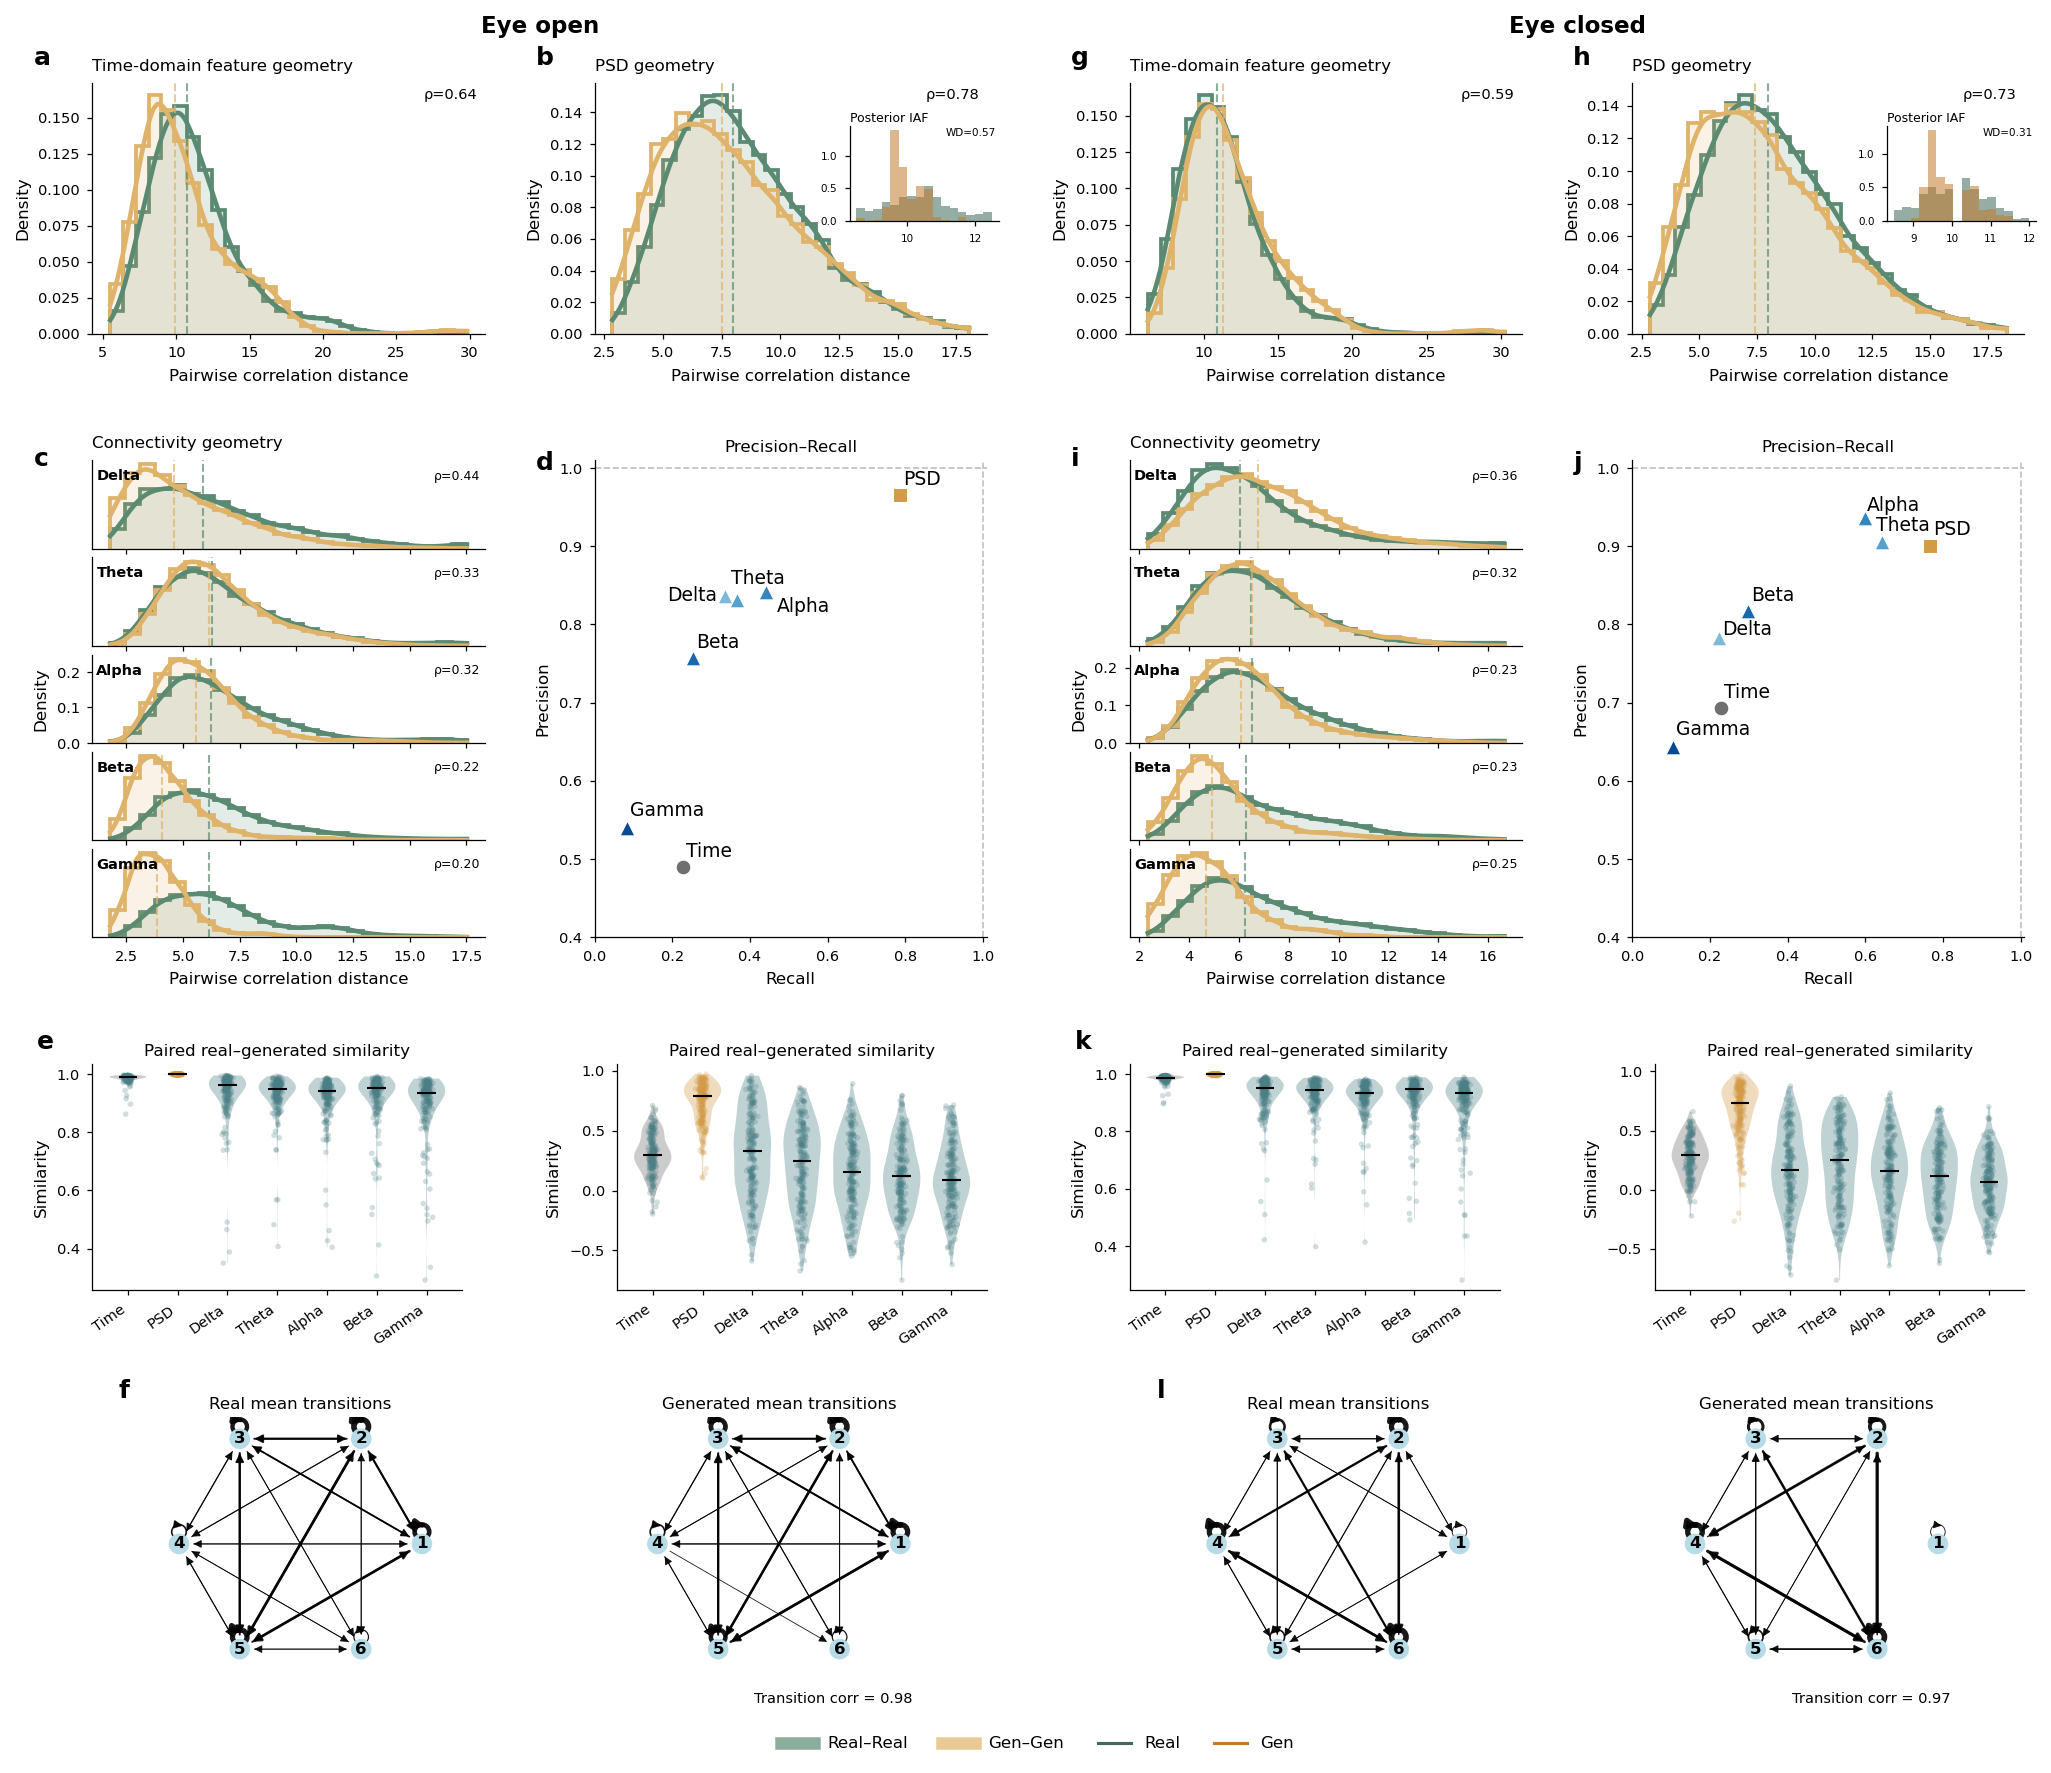

In [18]:
# =============================================================================
# Style helpers
# =============================================================================

def set_publication_style() -> None:
    plt.rcParams.update({
        "font.family": "sans-serif",
        "font.size": 8,
        "axes.titlesize": 8,
        "axes.labelsize": 8,
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
        "legend.fontsize": 8,
        "axes.linewidth": 0.6,
        "xtick.major.width": 0.6,
        "ytick.major.width": 0.6,
        "xtick.major.size": 2.5,
        "ytick.major.size": 2.5,
        "figure.dpi": 150,
        "savefig.dpi": 300,
    })


def add_panel_label(ax: plt.Axes, label: str, x=-0.15, y=1.15) -> None:
    ax.text(
        x, y, label,
        transform=ax.transAxes,
        fontsize=12,
        fontweight="bold",
        va="top",
        ha="left",
    )


def prettify_condition(name: str) -> str:
    return {"EO": "Eye open", "EC": "Eye closed"}.get(name, name)


# =============================================================================
# Small utilities
# =============================================================================

def robust_hist_range(*arrays: np.ndarray, q_low: float = 0.5, q_high: float = 99.5) -> Tuple[float, float]:
    vals = np.concatenate([np.asarray(a).ravel() for a in arrays if a is not None and len(a) > 0])
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return 0.0, 1.0
    lo = np.percentile(vals, q_low)
    hi = np.percentile(vals, q_high)
    if np.isclose(lo, hi):
        hi = lo + 1.0
    return float(lo), float(hi)


def normalize_metric_columns(
    values: np.ndarray,
    col_names: Sequence[str],
    lower_is_better: Sequence[str] = ("KS",),
) -> np.ndarray:
    """
    Normalize each metric column to [0, 1] with 'higher is better'.
    Useful for the heatmap summary.
    """
    vals = np.asarray(values, dtype=float).copy()
    out = np.zeros_like(vals)

    for j, name in enumerate(col_names):
        col = vals[:, j]
        finite = np.isfinite(col)
        if not np.any(finite):
            out[:, j] = np.nan
            continue

        c = col.copy()
        if name in lower_is_better:
            c = -c

        cmin, cmax = np.nanmin(c[finite]), np.nanmax(c[finite])
        if np.isclose(cmin, cmax):
            out[:, j] = 1.0
        else:
            out[:, j] = (c - cmin) / (cmax - cmin)

    return out


# =============================================================================
# Geometry panels
# =============================================================================
def gaussian_kde_manual(x, grid, bw=None):
    """
    Lightweight KDE without scipy dependency.
    Good enough for plotting scaffold.
    """
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    n = len(x)
    if n < 2:
        return np.zeros_like(grid)

    std = x.std(ddof=1)
    if bw is None:
        bw = 1.06 * std * n ** (-1 / 5) if std > 0 else 0.1
    bw = max(bw, 1e-6)

    diffs = (grid[:, None] - x[None, :]) / bw
    dens = np.exp(-0.5 * diffs**2).sum(axis=1) / (n * bw * np.sqrt(2 * np.pi))
    return dens


def draw_fancy_hist(ax, x, bins, hist_range, color, label):
    x = np.asarray(x)
    x = x[np.isfinite(x)]

    hist, edges = np.histogram(
        x, bins=bins, range=hist_range, density=True)

    # soft area
    ax.stairs(hist, edges, fill=True, alpha=0.16, color=color, linewidth=0)

    # crisp outline
    ax.stairs(hist, edges, fill=False, color=color, linewidth=1.8, label=label)

    # smooth density curve
    grid = np.linspace(hist_range[0], hist_range[1], 300)
    kde = gaussian_kde_manual(x, grid)
    ax.plot(grid, kde, color=color, linewidth=2.2)

    # optional median marker
    ax.axvline(np.median(x), color=color, linewidth=1.0, alpha=0.7, linestyle="--")


def plot_geometry_distribution(
    ax: plt.Axes,
    geom: GeometryDistribution,
    colors: Dict[str, str],
    title: Optional[str] = None,
    annotate: bool = True,
    bins: int = 30,
    show_legend: bool = False,
) -> None:
    xmin, xmax = robust_hist_range(geom.rr, geom.gg)

    # ax.hist(
    #     geom.rr, bins=bins, range=(xmin, xmax), density=True,
    #     color=colors["rr"], alpha=0.60, label="Real–Real", edgecolor="none"
    # )
    # ax.hist(
    #     geom.gg, bins=bins, range=(xmin, xmax), density=True,
    #     color=colors["gg"], alpha=0.60, label="Gen–Gen", edgecolor="none"
    # )

    hist_range = (xmin, xmax)

    draw_fancy_hist(ax, geom.rr, bins, hist_range, colors["rr"], "Real–Real")
    draw_fancy_hist(ax, geom.gg, bins, hist_range, colors["gg"], "Gen–Gen")


    if title is not None:
        ax.set_title(title, loc="left", pad=6)

    ax.set_xlabel(geom.xlabel)
    ax.set_ylabel("Density")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if annotate:
        text = f"ρ={geom.corr:.2f}"
        ax.text(
            0.98, 0.98, text,
            transform=ax.transAxes,
            ha="right", va="top",
            fontsize=7,
            bbox=dict(boxstyle="round,pad=0.22", fc="white", ec="none", alpha=0.8),
        )

    if show_legend:
        ax.legend(frameon=False, loc="upper right")


def plot_psd_geometry_with_iaf_inset(
    ax: plt.Axes,
    psd_geom: GeometryDistribution,
    iaf: Optional[IAFDistribution],
    colors: Dict[str, str],
    bins: int = 30,
    inset_rect: Tuple[float, float, float, float] = (0.65, 0.45, 0.38, 0.38),
) -> None:
    plot_geometry_distribution(
        ax=ax,
        geom=psd_geom,
        colors=colors,
        title="PSD geometry",
        annotate=True,
        bins=bins,
        show_legend=False,
    )

    if iaf is None:
        return

    inset = ax.inset_axes(inset_rect)
    xmin, xmax = robust_hist_range(iaf.real, iaf.gen)

    inset.hist(
        iaf.real, bins=16, range=(xmin, xmax), density=True,
        color=colors["real"], alpha=0.55, edgecolor="none", label="Real", histtype="stepfilled"
    )
    inset.hist(
        iaf.gen, bins=16, range=(xmin, xmax), density=True,
        color=colors["gen"], alpha=0.55, edgecolor="none", label="Gen", histtype="stepfilled"
    )
    inset.set_title("Posterior IAF", fontsize=6, pad=2, loc="left")
    inset.tick_params(labelsize=5)
    inset.spines["top"].set_visible(False)
    inset.spines["right"].set_visible(False)

    inset.text(
        0.98, 0.98,
        f"WD={iaf.wd:.2f}",
        transform=inset.transAxes,
        ha="right", va="top",
        fontsize=5,
        bbox=dict(boxstyle="round,pad=0.16", fc="white", ec="none", alpha=0.75),
    )


def plot_connectivity_geometry_strip(
    fig: plt.Figure,
    subspec,
    conn_geom: Dict[str, GeometryDistribution],
    band_order: Sequence[str],
    colors: Dict[str, str],
    bins: int = 26,
) -> List[plt.Axes]:
    sub = subspec.subgridspec(len(band_order), 1, hspace=0.10)
    axes = []

    global_xmin, global_xmax = robust_hist_range(
        *[conn_geom[b].rr for b in band_order],
        *[conn_geom[b].gg for b in band_order]
    )

    for i, band in enumerate(band_order):
        ax = fig.add_subplot(sub[i, 0])
        geom = conn_geom[band]

        # ax.hist(
        #     geom.rr, bins=bins, range=(global_xmin, global_xmax), density=True,
        #     color=colors["rr"], alpha=0.58, edgecolor="none"
        # )
        # ax.hist(
        #     geom.gg, bins=bins, range=(global_xmin, global_xmax), density=True,
        #     color=colors["gg"], alpha=0.58, edgecolor="none"
        # )

        hist_range = (global_xmin, global_xmax)

        draw_fancy_hist(ax, geom.rr, bins, hist_range, colors["rr"], "Real–Real")
        draw_fancy_hist(ax, geom.gg, bins, hist_range, colors["gg"], "Gen–Gen")

        ax.text(
            0.01, 0.82, band.capitalize(),
            transform=ax.transAxes,
            ha="left", va="center",
            fontsize=7, fontweight="bold"
        )
        ax.text(
            0.99, 0.82,
            f"ρ={geom.corr:.02f}",
            transform=ax.transAxes,
            ha="right", va="center",
            fontsize=6,
            bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.75),
        )

        if i < len(band_order) - 1:
            ax.set_xticklabels([])
        else:
            ax.set_xlabel(conn_geom[band_order[-1]].xlabel)

        if i == len(band_order) // 2:
            ax.set_ylabel("Density")
        else:
            ax.set_yticks([])

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        axes.append(ax)

    return axes


# =============================================================================
# Summary block
# =============================================================================

def plot_metric_heatmap(
    ax: plt.Axes,
    metric_rows: Sequence[str],
    metric_cols: Sequence[str],
    metric_values: np.ndarray,
    cmap: str = "YlGnBu",
    add_text: bool = True,
) -> plt.Axes:
    im = ax.imshow(metric_values, aspect="auto", cmap=cmap, vmin=0, vmax=1, interpolation="nearest")

    ax.set_xticks(np.arange(len(metric_cols)))
    ax.set_xticklabels(metric_cols, rotation=35, ha="right")
    ax.set_yticks(np.arange(len(metric_rows)))
    ax.set_yticklabels(metric_rows)
    ax.set_title("NN metrics", pad=4)

    for spine in ax.spines.values():
        spine.set_visible(False)

    if add_text:
        for i in range(metric_values.shape[0]):
            for j in range(metric_values.shape[1]):
                val = metric_values[i, j]
                txt = "nan" if not np.isfinite(val) else f"{val:.2f}"
                ax.text(j, i, txt, ha="center", va="center", fontsize=6, color="black")

    return im


def plot_pr_plane(
    ax: plt.Axes,
    pr_points: Sequence[PRPoint],
    band_order: Sequence[str],
    default_colors: Dict[str, str],
    cond_name: str,
) -> None:
    ax.axvline(1.0, color="0.75", lw=0.8, ls="--")
    ax.axhline(1.0, color="0.75", lw=0.8, ls="--")
    # ax.fill_between([0.9, 1.02], 0.9, 1.02, color="#E8F5E9", alpha=0.8, zorder=0)

    marker_map = {"time": "o", "psd": "s", "conn": "^"}
    color_map = {
        "time": default_colors["time"],
        "psd": default_colors["psd"],
    }

    label_offsets = {
    "Delta": (-0.15, -0.012),
    "Alpha": (0.029, -0.03),
    "Theta": (-0.015, 0.015),
    "Beta": (0.008, 0.008),
    "Gamma": (0.008, 0.010),
    "Time": (0.008, 0.008),
    "PSD": (0.008, 0.008),}

    if cond_name == "EC":
        label_offsets["Alpha"] = (0.005, 0.004)
        label_offsets["Delta"] = (0.008, 0.0)
        label_offsets["Theta"] = (-0.015, 0.008)

    conn_palette = plt.get_cmap("Blues")(np.linspace(0.45, 0.90, max(len(band_order), 2)))
    band_to_color = {band.capitalize(): conn_palette[i] for i, band in enumerate(band_order)}

    for pt in pr_points:
        marker = marker_map.get(pt.kind, "o")
        color = pt.color
        if color is None:
            if pt.kind == "conn":
                color = band_to_color.get(pt.label.capitalize(), default_colors["conn"])
            else:
                color = color_map.get(pt.kind, "k")

        ax.scatter(pt.recall, pt.precision, s=50, marker=marker, color=color, edgecolor="white", linewidth=0.5, zorder=3)
        dx, dy = label_offsets.get(pt.label, (0.01, 0.01))
        ax.text(
            pt.recall + dx, pt.precision + dy,
            pt.label, fontsize=9, ha="left", va="bottom"
        )

    ax.set_xlim(0.0, 1.01)
    ax.set_ylim(0.4, 1.01)
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title("Precision–Recall", pad=4)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


def plot_paired_similarity(
    ax: plt.Axes,
    paired_similarity: Dict[str, np.ndarray],
    pair_order: Sequence[str],
    colors: Dict[str, str],
) -> None:
    data = [np.asarray(paired_similarity[k]) for k in pair_order if k in paired_similarity]
    labels = [k for k in pair_order if k in paired_similarity]

    if len(data) == 0:
        ax.text(0.5, 0.5, "No paired similarity data", ha="center", va="center", transform=ax.transAxes)
        ax.set_axis_off()
        return

    positions = np.arange(1, len(data) + 1)

    vp = ax.violinplot(
        data, positions=positions, widths=0.75,
        showmeans=False, showmedians=True, showextrema=False
    )

    for i, body in enumerate(vp["bodies"]):
        label = labels[i]
        if label in {"PSD"}:
            body.set_facecolor(colors["psd"])
        elif label in {"Time"}:
            body.set_facecolor(colors["time"])
        else:
            body.set_facecolor(colors["conn"])
        body.set_alpha(0.35)
        body.set_edgecolor("none")

    vp["cmedians"].set_color("black")
    vp["cmedians"].set_linewidth(1.0)

    # jittered points
    rng = np.random.default_rng(7)
    for x, arr, label in zip(positions, data, labels):
        jitter = rng.normal(0, 0.045, size=len(arr))
        c = colors["psd"] if label == "PSD" else colors["conn"]
        ax.scatter(np.full_like(arr, x) + jitter, arr, s=7, alpha=0.25, color=c, edgecolor="none")

    ax.set_xticks(positions)
    ax.set_xticklabels(labels, rotation=35, ha="right")
    ax.set_ylabel("Similarity")
    ax.set_title("Paired real–generated similarity", pad=4)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


# =============================================================================
# State-space drawing
# =============================================================================

def draw_state_graph(
    ax: plt.Axes,
    positions: np.ndarray,
    transitions: np.ndarray,
    node_labels: Optional[Sequence[str]] = None,
    title: str = "",
    node_facecolor: str = "#B7DCE8",
    edge_color: str = "black",
) -> None:
    """
    Simple pure-matplotlib directed graph renderer.
    transitions[i, j] controls arrow thickness from i -> j.
    """
    n_states = positions.shape[0]
    T = np.asarray(transitions, dtype=float)
    T = np.nan_to_num(T, nan=0.0)

    # scale edges
    nonzero = T[T > 0]
    if nonzero.size == 0:
        tmin, tmax = 0.0, 1.0
    else:
        tmin, tmax = float(np.min(nonzero)), float(np.max(nonzero))
        if np.isclose(tmin, tmax):
            tmax = tmin + 1e-6

    def edge_width(w):
        if w <= 0:
            return 0.0
        return 0.4 + 2.3 * (w - tmin) / (tmax - tmin)

    radius = 0.085

    # edges first
    for i in range(n_states):
        for j in range(n_states):
            w = T[i, j]
            if w <= 0:
                continue

            p1 = positions[i]
            p2 = positions[j]

            if i == j:
                # self-loop
                loop_center = p1 + np.array([0.0, 0.10])
                circ = Circle(loop_center, 0.06, fill=False, lw=edge_width(w), ec=edge_color, alpha=0.9)
                ax.add_patch(circ)
                arrow = FancyArrowPatch(
                    posA=loop_center + np.array([-0.03, 0.06]),
                    posB=loop_center + np.array([0.03, 0.05]),
                    arrowstyle="-|>",
                    mutation_scale=8,
                    lw=edge_width(w),
                    color=edge_color,
                    alpha=0.9,
                )
                ax.add_patch(arrow)
            else:
                vec = p2 - p1
                norm = np.linalg.norm(vec)
                if norm < 1e-12:
                    continue
                unit = vec / norm
                start = p1 + unit * radius
                end = p2 - unit * radius

                arrow = FancyArrowPatch(
                    posA=start,
                    posB=end,
                    arrowstyle="-|>",
                    mutation_scale=8,
                    lw=edge_width(w),
                    color=edge_color,
                    alpha=0.9,
                    connectionstyle="arc3,rad=0.0",
                )
                ax.add_patch(arrow)

    # nodes
    for i, p in enumerate(positions):
        circle = Circle(p, radius=radius, fc=node_facecolor, ec="none", zorder=3)
        ax.add_patch(circle)
        label = str(i + 1) if node_labels is None else node_labels[i]
        ax.text(p[0], p[1], label, ha="center", va="center", fontsize=8, fontweight="bold")

    ax.set_title(title, pad=4)
    ax.set_xlim(positions[:, 0].min() - 0.15, positions[:, 0].max() + 0.15)
    ax.set_ylim(positions[:, 1].min() - 0.15, positions[:, 1].max() + 0.18)
    ax.set_aspect("equal")
    ax.axis("off")


def plot_state_space_block(
    fig: plt.Figure,
    subspec,
    positions: np.ndarray,
    real_transitions: np.ndarray,
    gen_transitions: np.ndarray,
    node_labels: Optional[Sequence[str]] = None,
    similarity_text: Optional[str] = None,
) -> List[plt.Axes]:
    sub = subspec.subgridspec(1, 2, wspace=0.15)
    ax_real = fig.add_subplot(sub[0, 0])
    ax_gen = fig.add_subplot(sub[0, 1])

    draw_state_graph(
        ax_real,
        positions=positions,
        transitions=real_transitions,
        node_labels=node_labels,
        title="Real mean transitions",
    )
    draw_state_graph(
        ax_gen,
        positions=positions,
        transitions=gen_transitions,
        node_labels=node_labels,
        title="Generated mean transitions",
    )

    if similarity_text is not None:
        ax_gen.text(
            0.98, -0.10, similarity_text,
            transform=ax_gen.transAxes,
            ha="right", va="top",
            fontsize=7
        )

    return [ax_real, ax_gen]


# =============================================================================
# Figure builder
# =============================================================================

def build_diversity_figure(
    conditions: Dict[str, ConditionFigure2Data],
    condition_order: Sequence[str] = ("EO", "EC"),
    band_order: Sequence[str] = ("delta", "theta", "alpha", "beta", "gamma"),
    pair_order: Sequence[str] = ("Time", "PSD", "Delta", "Theta", "Alpha", "Beta", "Gamma"),
    figsize: Tuple[float, float] = (14.0, 11.0),
    save_path: Optional[str] = None,
) -> plt.Figure:
    set_publication_style()

    colors = {
    "rr": "#5B8A72",
    "gg": "#E0B36A",

    "real": "#3E6B5A",
    "gen": "#C27A2C",

    "time": "#6F6F6F",
    "psd": "#D39B47",
    "conn": "#4A7F86",
    }

    fig = plt.figure(figsize=figsize)
    outer = fig.add_gridspec(
        1, len(condition_order),
        left=0.05, right=0.97, top=0.95, bottom=0.07,
        wspace=0.16
    )

    panel_letters = list("abcdefghijkl")
    p = 0

    heatmap_ims = []

    for col, cond_name in enumerate(condition_order):
        cond = conditions[cond_name]

        # Per-condition layout
        gs = outer[0, col].subgridspec(
            4, 2,
            height_ratios=[1.05, 2.0, 0.95, 1.05],
            width_ratios=[1.0, 1.0],
            hspace=0.42,
            wspace=0.28,
        )

        # ---------------------------------------------------------------------
        # Row 1
        # ---------------------------------------------------------------------
        ax_time = fig.add_subplot(gs[0, 0])
        plot_geometry_distribution(
            ax_time,
            cond.time_geom,
            colors=colors,
            title="Time-domain feature geometry",
            annotate=True,
            bins=28,
            show_legend=False,
        )
        add_panel_label(ax_time, panel_letters[p]); p += 1

        ax_psd = fig.add_subplot(gs[0, 1])
        plot_psd_geometry_with_iaf_inset(
            ax_psd,
            cond.psd_geom,
            cond.iaf,
            colors=colors,
            bins=28,
        )
        add_panel_label(ax_psd, panel_letters[p]); p += 1

        # ---------------------------------------------------------------------
        # Row 2: connectivity geometry strip
        # ---------------------------------------------------------------------
        conn_axes = plot_connectivity_geometry_strip(
            fig,
            gs[1, 0],
            cond.conn_geom,
            band_order=band_order,
            colors=colors,
            bins=24,
        )
        conn_axes[0].set_title("Connectivity geometry", loc="left", pad=6)
        add_panel_label(conn_axes[0], panel_letters[p]); p += 1

        pr_gs = gs[1, 1].subgridspec(1, 1, wspace=0.42)
        ax_pr = fig.add_subplot(pr_gs[0, :2])
        plot_pr_plane(
            ax_pr,
            pr_points=cond.pr_points,
            band_order=band_order,
            default_colors=colors,
            cond_name=cond_name,
        )
        add_panel_label(ax_pr, panel_letters[p], y=1.02); p += 1

        # ---------------------------------------------------------------------
        # Row 3: summary block
        # ---------------------------------------------------------------------
        summary_gs = gs[2, :].subgridspec(1, 2, wspace=0.42)

        # ax_heat = fig.add_subplot(summary_gs[0, 0])
        # heat_im = plot_metric_heatmap(
        #     ax_heat,
        #     metric_rows=cond.metric_rows,
        #     metric_cols=cond.metric_cols,
        #     metric_values=cond.metric_values,
        #     cmap="YlGnBu",
        #     add_text=True,
        # )
        # heatmap_ims.append(heat_im)
        # add_panel_label(ax_heat, panel_letters[p]); p += 1

        # ax_pr = fig.add_subplot(summary_gs[0, :2])
        # plot_pr_plane(
        #     ax_pr,
        #     pr_points=cond.pr_points,
        #     band_order=band_order,
        #     default_colors=colors,
        # )
        # add_panel_label(ax_pr, panel_letters[p]); p += 1

        ax_pair = fig.add_subplot(summary_gs[0, 0])
        plot_paired_similarity(
            ax_pair,
            paired_similarity=cond.paired_similarity,
            pair_order=pair_order,
            colors=colors,
        )
        add_panel_label(ax_pair, panel_letters[p]); p += 1

        ax_pair_z = fig.add_subplot(summary_gs[0, 1])
        plot_paired_similarity(
            ax_pair_z,
            paired_similarity=cond.paired_similarity_z,
            pair_order=pair_order,
            colors=colors,
        )

        # ---------------------------------------------------------------------
        # Row 4: state-space block
        # ---------------------------------------------------------------------
        state_axes = plot_state_space_block(
            fig,
            gs[3, :],
            positions=cond.state_positions,
            real_transitions=cond.real_transitions,
            gen_transitions=cond.gen_transitions,
            node_labels=cond.state_labels,
            similarity_text=cond.state_similarity_text,
        )
        add_panel_label(state_axes[0], panel_letters[p]); p += 1

        # Condition title
        bbox = outer[0, col].get_position(fig)
        fig.text(
            (bbox.x0 + bbox.x1) / 2,
            0.988,
            prettify_condition(cond_name),
            ha="center",
            va="top",
            fontsize=11,
            fontweight="bold",
        )

    # Shared heatmap colorbar
    if len(heatmap_ims) > 0:
        cbar = fig.colorbar(heatmap_ims[-1], ax=[ax for ax in fig.axes if ax in [hm.axes for hm in heatmap_ims]],
                            fraction=0.025, pad=0.015, aspect=30)
        cbar.set_label("Normalized score\n(higher = better)")

    # Shared legend
    handles = [
        Line2D([0], [0], color=colors["rr"], lw=6, alpha=0.7, label="Real–Real"),
        Line2D([0], [0], color=colors["gg"], lw=6, alpha=0.7, label="Gen–Gen"),
        Line2D([0], [0], color=colors["real"], lw=1.5, label="Real"),
        Line2D([0], [0], color=colors["gen"], lw=1.5, label="Gen"),
    ]
    fig.legend(
        handles=handles,
        loc="lower center",
        ncol=4,
        frameon=False,
        bbox_to_anchor=(0.5, 0.015),
    )

    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight")

    return fig


# =============================================================================
# Mock-data helpers
# =============================================================================

def sample_geometry(
    n: int = 1000,
    rr_mu: float = 0.80,
    rr_sd: float = 0.22,
    gg_mu: float = 0.78,
    gg_sd: float = 0.20,
    ks: float = 0.08,
    cov: float = 0.92,
    knn: float = 0.97,
    xmin_clip: float = 0.0,
) -> GeometryDistribution:
    rr = np.random.normal(rr_mu, rr_sd, size=n)
    gg = np.random.normal(gg_mu, gg_sd, size=n)
    rr = np.clip(rr, xmin_clip, None)
    gg = np.clip(gg, xmin_clip, None)
    return GeometryDistribution(rr=rr, gg=gg, ks=ks, coverage=cov, knn_ratio=knn)


def sample_iaf(n: int = 120, mean_real: float = 10.1, mean_gen: float = 9.9) -> IAFDistribution:
    real = np.random.normal(mean_real, 0.65, size=n)
    gen = np.random.normal(mean_gen, 0.55, size=n)
    return IAFDistribution(real=real, gen=gen, ks=0.19, wd=0.31)


def sample_transition_matrix(n_states: int = 6, noise: float = 0.05) -> np.ndarray:
    base = np.random.rand(n_states, n_states)
    base = base / base.sum(axis=1, keepdims=True)
    base += noise * np.random.rand(n_states, n_states)
    base = np.clip(base, 0, None)
    base = base / base.sum(axis=1, keepdims=True)
    return base

# =============================================================================
# Figure
# =============================================================================

if __name__ == "__main__":
    # np.random.seed(7)
    USE_PR = True

    # N_SUBJECTS = 10
    # condition_data_eo = make_condition_data(CHANNELS, model, fmin, fmax, n_subjects=N_SUBJECTS, return_only_raw=False, condition='EO')
    # condition_data_ec = make_condition_data(CHANNELS, model, fmin, fmax, n_subjects=N_SUBJECTS, return_only_raw=False, condition='EC')

    if Path('data/viz/figure2_condition_data_v2.pkl').exists():
        print('Uploading condition data for figure 2...')
        with open('data/viz/figure2_condition_data_v2.pkl', 'rb') as f:
            conditions = pickle.load(f)
        if USE_PR:
            with open('data/viz/pr_points.pkl', 'rb') as f:
                pr_points = pickle.load(f)
            conditions['EC'].pr_points = pr_points['EC']
            conditions['EO'].pr_points = pr_points['EO']
    else:
        conditions = {
            "EO": make_true_condition_fig2(condition_data_eo, condition='EO'),
            "EC": make_true_condition_fig2(condition_data_ec, condition='EC'),
        }

    fig = build_diversity_figure(
        conditions=conditions,
        condition_order=("EO", "EC"),
        band_order=("delta", "theta", "alpha", "beta", "gamma"),
        pair_order=("Time", "PSD", "Delta", "Theta", "Alpha", "Beta", "Gamma"),
        figsize=(14, 12),
        save_path=None,  # e.g. "figure2_diversity.png"
    )
    plt.show()

# Figure 3: Feature-Learning trajectory

In [26]:
from scipy.linalg import sqrtm

def hjorth_parameters_multi_channel(signal, axis=-1, eps=1e-12): # x: (n_samples, n_channels, n_timepoints) 
    activity = np.var(signal, axis=axis)
    first_derivative = np.diff(signal, axis=axis)
    var_d1 = np.var(first_derivative, axis=axis)
    mobility = np.sqrt(var_d1 / (activity + eps))
    second_derivative = np.diff(first_derivative, axis=axis)
    var_d2 = np.var(second_derivative, axis=axis)
    complexity = np.sqrt(var_d2 / (var_d1 + eps)) / (mobility + eps)
    return np.stack([activity, mobility, complexity], axis=-1)   # (n_samples, n_channels, n_features)

def spectral_features_multi_channel(signal, fs=128, nperseg=512):
    f, Pxx = welch(signal, fs=fs, nperseg=nperseg, axis=-1)
    total_power = np.sum(Pxx, axis=-1)
    delta = np.sum(Pxx[:, :, (f >= 0.25) & (f < 4)], axis=-1) / total_power
    theta = np.sum(Pxx[:, :, (f >= 4) & (f < 8)], axis=-1) / total_power
    alpha = np.sum(Pxx[:, :, (f >= 8) & (f < 13)], axis=-1) / total_power
    beta = np.sum(Pxx[:, :, (f >= 13) & (f <= 30)], axis=-1) / total_power
    gamma = np.sum(Pxx[:, :, (f > 30) & (f <= 50)], axis=-1) / total_power

    return np.stack([delta, theta, alpha, beta, gamma], axis=-1)

# Fréchet Inception Distanc (FID)
def compute_fid(x_features, y_features, eps=1e-6):
    mean1, cov1 = x_features.mean(axis=0), np.cov(x_features, rowvar=False)
    mean2, cov2 = y_features.mean(axis=0), np.cov(y_features, rowvar=False)

    if np.ndim(cov1) == 0: cov1 = np.array([[cov1]])
    if np.ndim(cov2) == 0: cov2 = np.array([[cov2]])

    cov1 = cov1 + eps * np.eye(cov1.shape[0])
    cov2 = cov2 + eps * np.eye(cov2.shape[0])

    mean_diff = np.sum((mean1 - mean2) ** 2)
    covmean = sqrtm(cov1 @ cov2)
    covmean = np.real_if_close(covmean)

    fid = mean_diff + np.trace(cov1 + cov2 - 2 * covmean)
    return float(max(fid, 0.0))

def aggregate_features(signal):
    # Extract features
    hjorth_features = hjorth_parameters_multi_channel(signal)
    spectral_features = spectral_features_multi_channel(signal)

    # Concatenate features
    features = np.concatenate([hjorth_features, spectral_features], axis=-1)
    
    return features

In [ ]:
from pathlib import Path
import re

epochs = []
MODEL_NUM = "20260328"
AVERAGE_FIRST = False

for chk in Path(f"logs/eo/{MODEL_NUM}").glob("*_epoch_*.model.keras"):
    match = re.search(r"(.*)_epoch_(\d+)\.model.keras", chk.name).groups()
    if match:
        epoch_num = int(match[1])
        epochs.append(epoch_num)

epochs = sorted(epochs)

# FID calculation for different models and plot them across the epochs
all_fd = {}

eeg_data_path = 'data/LEMON_DATA/EC_ch-8_sf-128.nc5'
channels = CHANNELS
N_SUBJECTS = 202
f_names = ["activity", "mobility", "complexity", 'delta', 'theta', 'alpha', 'beta', 'gamma']

early_epoch = 20
late_epoch = 200

x, sub, state, raw_real = open_real_data(eeg_data_path, channels, n_subjects=N_SUBJECTS, time_dim=512, condition='EC')
real_f = aggregate_features(raw_real)  # (n_subjects, n_channels, n_features)

for epoch in epochs:
    chk_path = f'logs/eo/{MODEL_NUM}/{MODEL_NUM}_epoch_{epoch}.model.keras'
    model = keras.saving.load_model(chk_path, custom_objects={'FiLMGAN': FiLMGAN}, compile=False)
    print(f'Calculating WD for {epoch}...')
    # generated data
    with torch.no_grad():
        x_gen = generate_data(model, x, sub, state, n_subjects=N_SUBJECTS).cpu().detach()  # (n_samples, n_channels, n_timepoints)

    raw_fake = reverse_segmentation(x_gen, N_SUBJECTS).numpy()  # (n_subjects, n_channels, total_timepoints)
    fake_f = aggregate_features(raw_fake)

    if epoch == early_epoch:
        fake_f_early = fake_f
    elif epoch == late_epoch:
        fake_f_late = fake_f



    if AVERAGE_FIRST:
        for fn in range(len(f_names)):
            all_fd[f'{f_names[fn]}_{epoch}'] = compute_fid(real_f[:, :, fn],
                                                        fake_f[:, :, fn])

    else:
        for ch in range(0, len(channels)):
            for fn in range(len(f_names)):
                all_fd[f'{channels[ch]}_{f_names[fn]}_{epoch}'] = compute_fid(real_f[:, ch, fn],
                                                                            fake_f[:, ch, fn])

if AVERAGE_FIRST:
    all_fd_df = pd.DataFrame(all_fd, index=[0])
    all_fd_df = all_fd_df.melt(var_name='name', value_name='WD')
    all_fd_df[['feature', 'epoch']] = all_fd_df['name'].apply(lambda x: x.split('_')).apply(pd.Series)
    all_fd_df.drop('name', axis=1, inplace=True)

    all_fd_df = all_fd_df.pivot(columns='feature', values='WD', index=['epoch'])
    all_fd_df.reset_index(inplace=True)
    all_fd_df['epoch'] = all_fd_df.epoch.astype(int)
    all_fd_df.set_index(['epoch'], inplace=True)

else:   
    all_fd_df = pd.DataFrame(all_fd, index=[0])
    all_fd_df = all_fd_df.melt(var_name='name', value_name='WD')
    all_fd_df[['channel', 'feature', 'epoch']] = all_fd_df['name'].apply(lambda x: x.split('_')).apply(pd.Series)
    all_fd_df.drop('name', axis=1, inplace=True)
    all_fd_df = all_fd_df.pivot(columns='feature', values='WD', index=['channel', 'epoch'])
    all_fd_df.reset_index(inplace=True)
    all_fd_df['epoch'] = all_fd_df.epoch.astype(int)
    all_fd_df.set_index(['channel', 'epoch'], inplace=True)

    all_fd_df_avg = all_fd_df.groupby('epoch').mean().reset_index()
    all_fd_df_avg.set_index('epoch', inplace=True)

Calculating WD for 10...
Calculating WD for 20...
Calculating WD for 30...
Calculating WD for 40...
Calculating WD for 50...
Calculating WD for 60...
Calculating WD for 70...
Calculating WD for 80...
Calculating WD for 90...
Calculating WD for 100...
Calculating WD for 110...
Calculating WD for 120...
Calculating WD for 130...
Calculating WD for 140...
Calculating WD for 150...
Calculating WD for 160...
Calculating WD for 170...
Calculating WD for 180...
Calculating WD for 190...
Calculating WD for 200...


## Figure

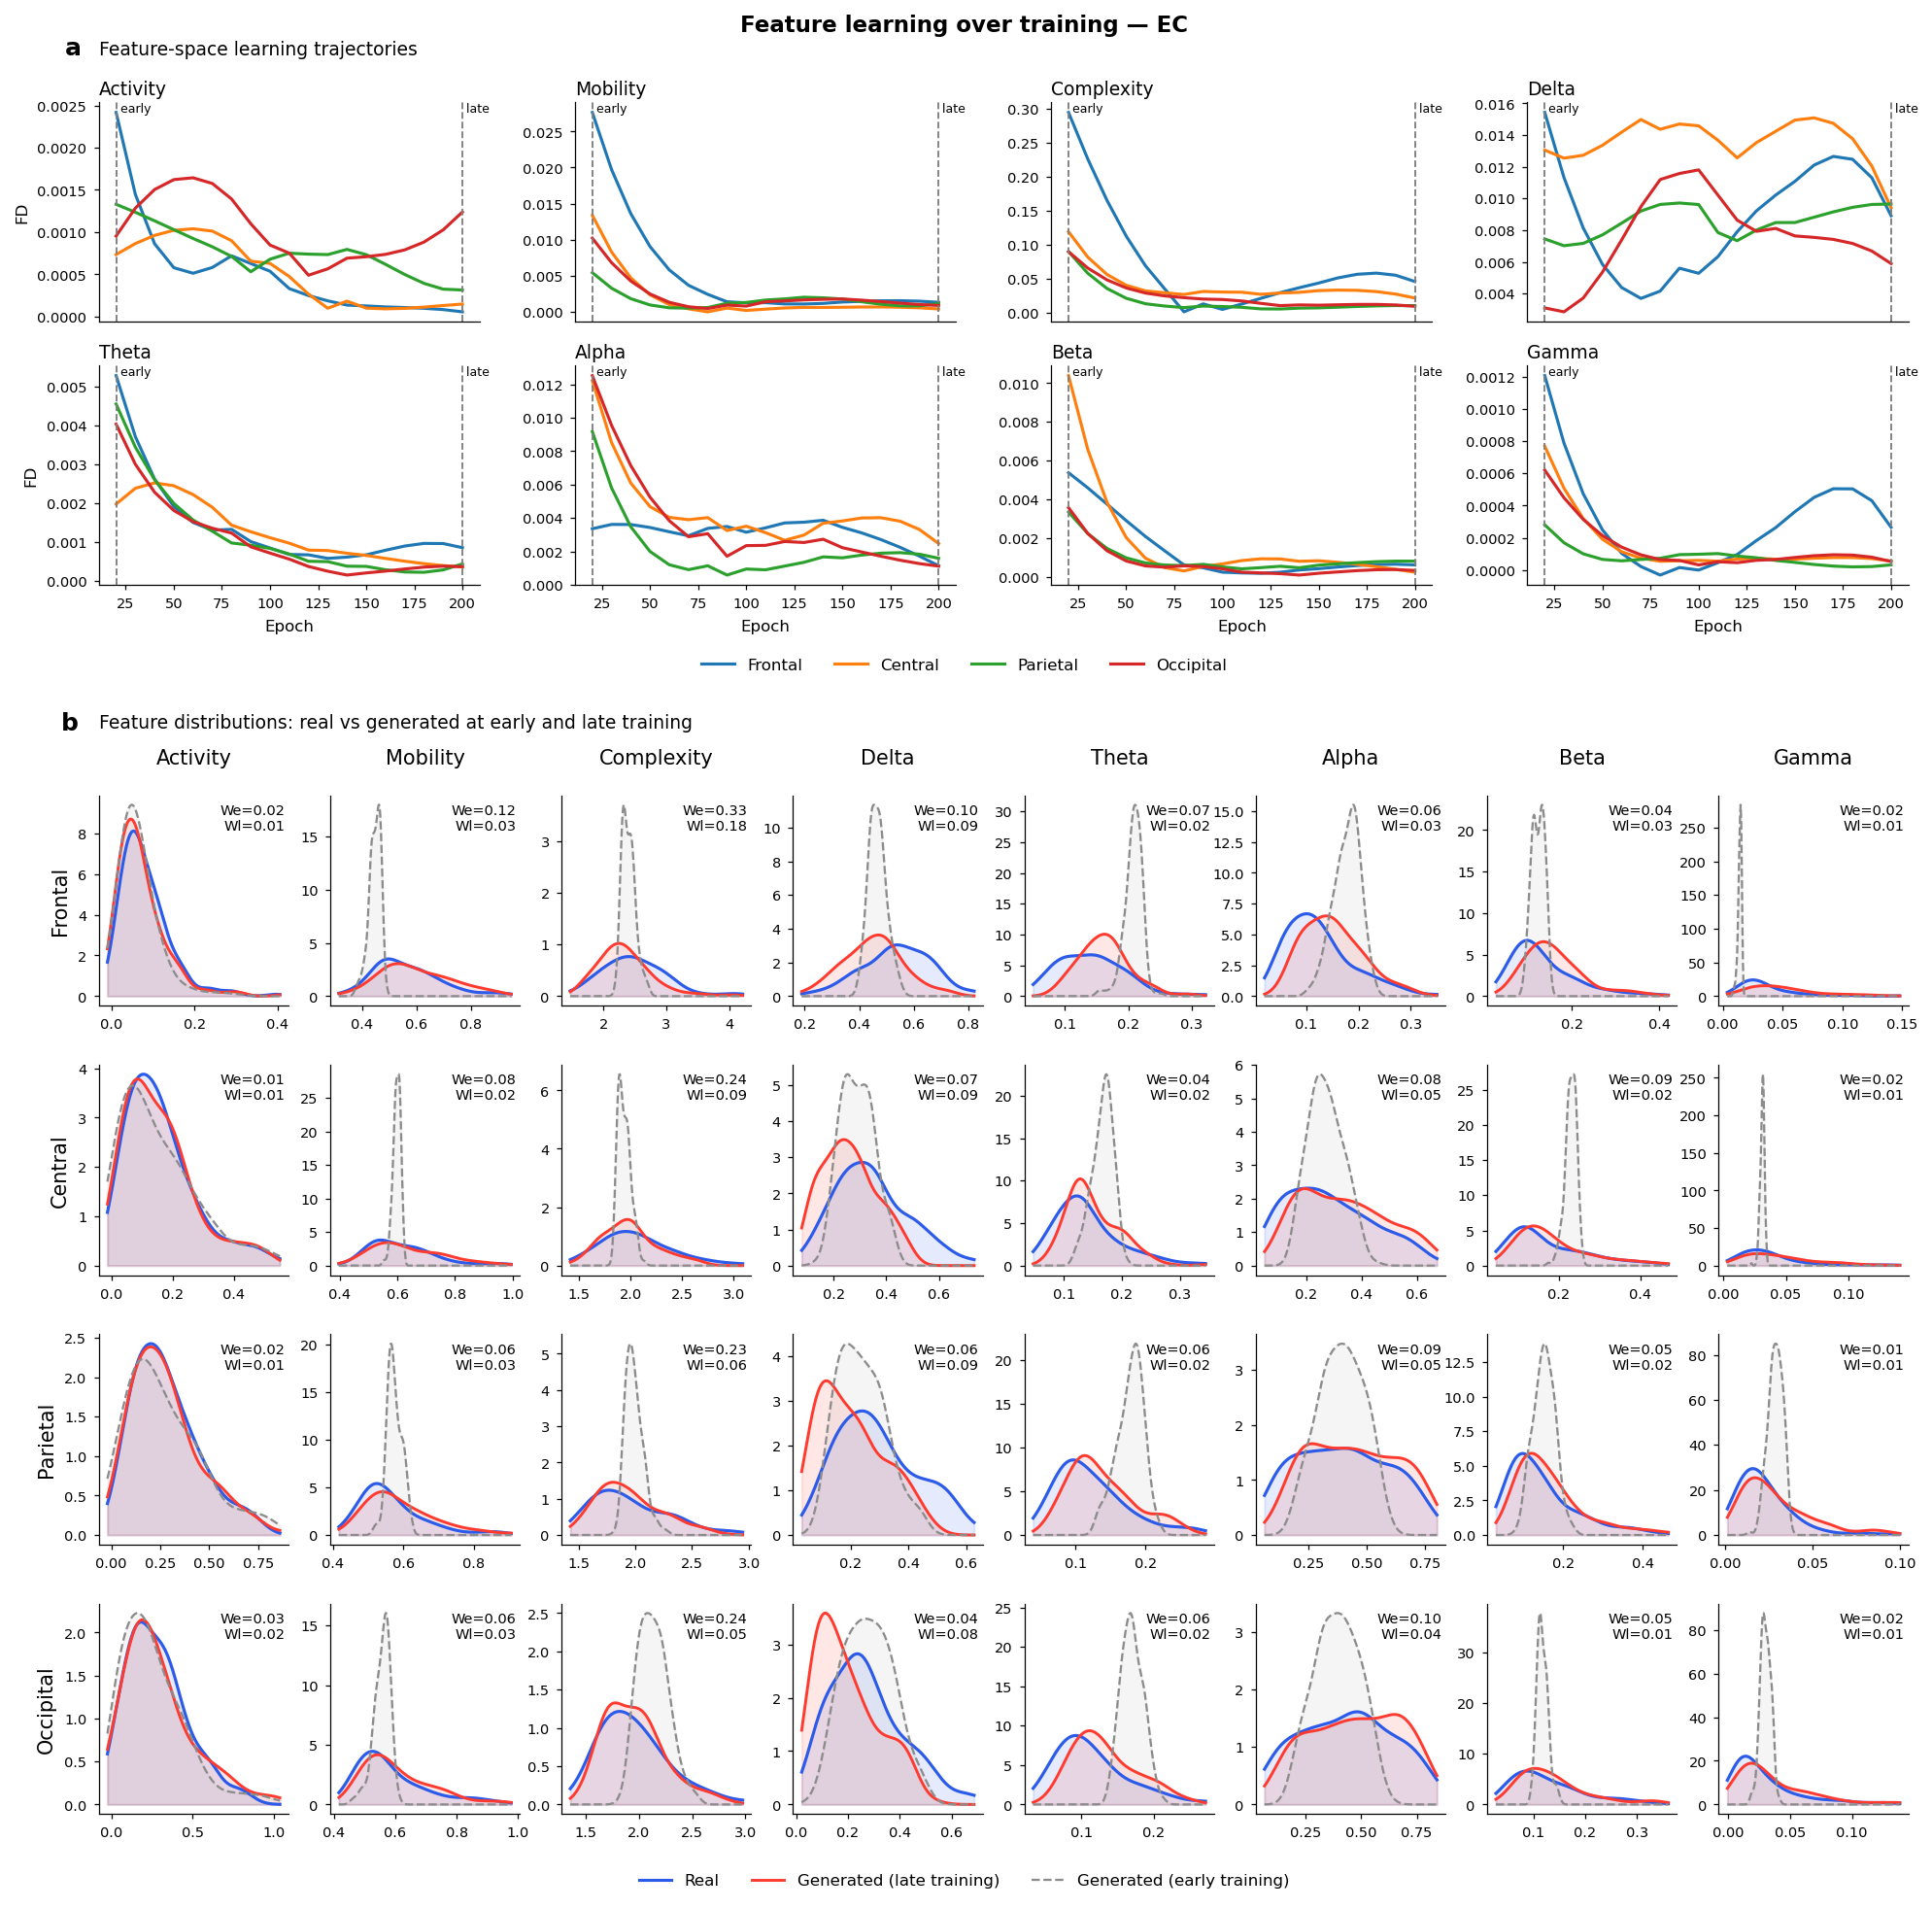

In [ ]:
# =============================================================================
# Data containers
# =============================================================================

@dataclass
class FDTrajectory:
    epochs: np.ndarray                    # (n_epochs,)
    values_by_feature: Dict[str, np.ndarray]   # feature -> (n_epochs,)


@dataclass
class DistributionPanelData:
    """
    For one small distribution subplot:
      real vs generated-early vs generated-late
    """
    real: np.ndarray
    gen_early: np.ndarray
    gen_late: np.ndarray
    title: str
    xlabel: str
    we_early: Optional[float] = None
    we_late: Optional[float] = None


@dataclass
class Figure3ConditionData:
    condition_name: str                   # e.g. "EC"

    # Panel a
    activity: FDTrajectory
    mobility: FDTrajectory
    complexity: FDTrajectory

    # Panel b
    delta: FDTrajectory
    theta: FDTrajectory
    alpha: FDTrajectory
    beta: FDTrajectory
    gamma: FDTrajectory

    # Panels c and d
    # key = (region, feature_or_band)
    nonspectral_distributions: Dict[Tuple[str, str], DistributionPanelData]
    spectral_distributions: Dict[Tuple[str, str], DistributionPanelData]
    all_distributions: Dict[Tuple[str, str], DistributionPanelData]

    # Which regions/features to show in the bottom grids
    representative_regions: List[str]     # e.g. ["Occipital", "Frontal"]
    nonspectral_features: List[str]       # e.g. ["activity", "mobility", "complexity"]
    spectral_features: List[str]          # e.g. ["alpha", "beta", "gamma"]
    feature_names: List[str] 

    # Shared training checkpoints
    early_epoch: int
    late_epoch: int


# =============================================================================
# Style
# =============================================================================

def set_publication_style() -> None:
    plt.rcParams.update({
        "font.family": "sans-serif",
        "font.size": 8,
        "axes.titlesize": 8,
        "axes.labelsize": 8,
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
        "legend.fontsize": 8,
        "axes.linewidth": 0.6,
        "xtick.major.width": 0.6,
        "ytick.major.width": 0.6,
        "xtick.major.size": 2.5,
        "ytick.major.size": 2.5,
        "figure.dpi": 150,
        "savefig.dpi": 300,
    })


def add_panel_label(ax: plt.Axes, label: str, x=-0.18, y=1.10,) -> None:
    ax.text(
        x, y, label,
        transform=ax.transAxes,
        fontsize=12,
        fontweight="bold",
        va="top",
        ha="left",
    )


# =============================================================================
# Helpers
# =============================================================================

def robust_xlim_from_arrays(*arrays, q=(0.5, 99.5), pad_frac=0.03):
    vals = []
    for a in arrays:
        a = np.asarray(a).ravel()
        a = a[np.isfinite(a)]
        if a.size:
            vals.append(a)
    if not vals:
        return (0.0, 1.0)
    vals = np.concatenate(vals)
    lo, hi = np.percentile(vals, q)
    if np.isclose(lo, hi):
        hi = lo + 1.0
    pad = (hi - lo) * pad_frac
    return float(lo - pad), float(hi + pad)


def gaussian_kde_manual(x, grid, bw=None):
    """
    Lightweight KDE without scipy dependency.
    Good enough for plotting scaffold.
    """
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    n = len(x)
    if n < 2:
        return np.zeros_like(grid)

    std = x.std(ddof=1)
    if bw is None:
        bw = 1.06 * std * n ** (-1 / 5) if std > 0 else 0.1
    bw = max(bw, 1e-6)

    diffs = (grid[:, None] - x[None, :]) / bw
    dens = np.exp(-0.5 * diffs**2).sum(axis=1) / (n * bw * np.sqrt(2 * np.pi))
    return dens

# =============================================================================
# Trajectory smoothing utilities
# =============================================================================

def smooth_trajectory_spline(x, y, smoothing_factor=0.5, n_points=300):
    from scipy.interpolate import UnivariateSpline
    # Convert smoothing_factor to spline smoothing parameter (inverse relationship)
    s = (1 - smoothing_factor) * len(x) * y.std()**2
    spline = UnivariateSpline(x, y, s=s, k=min(3, len(x)-1))
    x_smooth = np.linspace(x.min(), x.max(), n_points)
    y_smooth = spline(x_smooth)
    return x_smooth, y_smooth


def smooth_trajectory_savgol(y, window_length=11, polyorder=3):
    from scipy.signal import savgol_filter
    # Ensure window_length is odd and not larger than data
    window_length = min(window_length, len(y) if len(y) % 2 == 1 else len(y) - 1)
    window_length = max(window_length, 5)
    if window_length % 2 == 0:
        window_length -= 1
    polyorder = min(polyorder, window_length - 1)
    return savgol_filter(y, window_length, polyorder)


def smooth_trajectory_gaussian(y, sigma=2.0):
    from scipy.ndimage import gaussian_filter1d
    return gaussian_filter1d(y, sigma=sigma)

# =============================================================================
# Plotting: top-row FD trajectories
# =============================================================================

def plot_fd_trajectories(
    ax,
    traj: FDTrajectory,
    early_epoch: int,
    late_epoch: int,
    title: str,
    ylabel: str = "Fréchet Distance",
    feature_order: Optional[Sequence[str]] = None,
) -> None:
    epochs = traj.epochs
    items = traj.values_by_feature

    if feature_order is None:
        feature_order = list(items.keys())

    for feat in feature_order:
        ax.plot(epochs, items[feat], lw=1.5, label=feat.capitalize())

    ax.axvline(early_epoch, color="0.5", lw=0.9, ls="--")
    ax.axvline(late_epoch, color="0.5", lw=0.9, ls="--")

    ax.text(early_epoch, ax.get_ylim()[1] if len(ax.lines) else 1.0, " early",
            fontsize=6, va="top", ha="left")
    ax.text(late_epoch, ax.get_ylim()[1] if len(ax.lines) else 1.0, " late",
            fontsize=6, va="top", ha="left")

    ax.set_title(title, loc="left", pad=6)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

def plot_single_fd_trajectory(ax, traj, title, early_epoch, late_epoch, drop_epo=1, region_colors=None):
    items = traj.values_by_feature
    epochs = traj.epochs
    feature_order = list(items.keys())
    
    # Default colors for brain regions if not provided
    if region_colors is None:
        region_colors = {
            "frontal": "#1f77b4",
            "central": "#ff7f0e",
            "parietal": "#2ca02c",
            "occipital": "#d62728",
        }

    for k in feature_order:
        y = smooth_trajectory_savgol(np.array(items[k][drop_epo:]))
        color = region_colors.get(k, "#000000")
        ax.plot(epochs[drop_epo:], y, lw=1.5, label=k.capitalize(), color=color)

    ax.axvline(early_epoch, color="0.5", lw=0.9, ls="--")
    ax.axvline(late_epoch, color="0.5", lw=0.9, ls="--")

    ax.text(early_epoch, ax.get_ylim()[1] if len(ax.lines) else 1.0, " early",
            fontsize=6, va="top", ha="left")
    ax.text(late_epoch, ax.get_ylim()[1] if len(ax.lines) else 1.0, " late",
            fontsize=6, va="top", ha="left")

    ax.set_title(title, pad=4, loc='left', fontsize=9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# =============================================================================
# Plotting: small density comparison panels
# =============================================================================

def plot_distribution_triplet(
    ax: plt.Axes,
    panel: DistributionPanelData,
    colors: Dict[str, str],
    use_kde: bool = True,
    bins: int = 30,
) -> None:
    xr = panel.real
    xe = panel.gen_early
    xl = panel.gen_late

    xmin, xmax = robust_xlim_from_arrays(xr, xe, xl)

    if use_kde:
        grid = np.linspace(xmin, xmax, 300)
        yr = gaussian_kde_manual(xr, grid)
        ye = gaussian_kde_manual(xe, grid)
        yl = gaussian_kde_manual(xl, grid)

        ax.plot(grid, yr, color=colors["real"], lw=1.5, label="Real")
        ax.plot(grid, yl, color=colors["late"], lw=1.4, label="Generated (late)")
        ax.plot(grid, ye, color=colors["early"], lw=1.1, ls="--", label="Generated (early)")
        ax.fill_between(grid, 0, yr, color=colors["real"], alpha=0.12)
        ax.fill_between(grid, 0, yl, color=colors["late"], alpha=0.12)
        ax.fill_between(grid, 0, ye, color=colors["early"], alpha=0.08)
    else:
        ax.hist(xr, bins=bins, range=(xmin, xmax), density=True,
                histtype="step", lw=1.5, color=colors["real"], label="Real")
        ax.hist(xl, bins=bins, range=(xmin, xmax), density=True,
                histtype="step", lw=1.4, color=colors["late"], label="Generated (late)")
        ax.hist(xe, bins=bins, range=(xmin, xmax), density=True,
                histtype="step", lw=1.1, ls="--", color=colors["early"], label="Generated (early)")

    txt_lines = []
    if panel.we_early is not None:
        txt_lines.append(f"We={panel.we_early:.02f}")
    if panel.we_late is not None:
        txt_lines.append(f"Wl={panel.we_late:.02f}")
    if txt_lines:
        ax.text(
            0.98, 0.96, "\n".join(txt_lines),
            transform=ax.transAxes,
            ha="right", va="top",
            fontsize=7,
            bbox=dict(boxstyle="round,pad=0.18", fc="white", ec="none", alpha=0.75),
        )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# =============================================================================
# Main builder
# =============================================================================

def build_feature_learning_figure(
    data: Figure3ConditionData,
    figsize: Tuple[float, float] = (13.5, 9.5),
    save_path: Optional[str] = None,
) -> plt.Figure:
    set_publication_style()

    colors = {
        "real": "#2C5BEA",
        "late": "#FF3B30",
        "early": "#8C8C8C",
    }

    fig = plt.figure(figsize=figsize)
    outer = fig.add_gridspec(
        2, 1,
        height_ratios=[0.90, 1.9],
        width_ratios=[1],
        left=0.06, right=0.98, top=0.95, bottom=0.08,
        hspace=0.28, wspace=0.18,
    )

    # -------------------------------------------------------------------------
    # a: trajectories
    # -------------------------------------------------------------------------

    a_gs = outer[0].subgridspec(2, 4, wspace=0.25)

    a_axes = []
    for j, feat in enumerate(data.feature_names):
        ax = fig.add_subplot(a_gs[j//4, j%4])
        plot_single_fd_trajectory(
            ax,
            getattr(data, feat),
            feat.capitalize(),
            data.early_epoch,
            data.late_epoch,
        )
        if j%4 == 0:
            ax.set_ylabel("FD")
    
        if j//4 == 1:
            ax.set_xlabel("Epoch")
        else:
            ax.set_xticks([])
        a_axes.append(ax)

    a_axes[0].text(
        0.0, 1.2,
        "Learning trajectories of Hjorth parameters and spectral features",
        transform=a_axes[0].transAxes,
        ha="left", va="bottom", fontsize=9,
    )
    add_panel_label(a_axes[0], "a", x=-0.09, y=1.3)

    # Brain area legend for trajectories
    region_colors = {
        "frontal": "#1f77b4",
        "central": "#ff7f0e",
        "parietal": "#2ca02c",
        "occipital": "#d62728",
    }
    region_handles = [
        Line2D([0], [0], color=region_colors[region], lw=1.5, label=region.capitalize())
        for region in region_colors.keys()
    ]
    fig.legend(
        handles=region_handles,
        loc="upper center",
        ncol=4,
        frameon=False,
        bbox_to_anchor=(0.5, 0.675),
        fontsize=8,
    )


    # -------------------------------------------------------------------------
    # b: distributions
    # -------------------------------------------------------------------------
    c_gs = outer[1].subgridspec(
        len(data.representative_regions),
        len(data.feature_names),
        hspace=0.28,
        wspace=0.22,
    )

    b_axes = []
    for i, region in enumerate(data.representative_regions):
        for j, feat in enumerate(data.feature_names):
            ax = fig.add_subplot(c_gs[i, j])
            panel = data.all_distributions[(region, feat)]
            plot_distribution_triplet(ax, panel, colors=colors, use_kde=True)

            if j == 0:
                ax.set_ylabel(region.capitalize(), fontsize=10)
            else:
                # ax.set_yticklabels([])
                ax.set_ylabel("")

            # Column labels (features on top) - set in title or via text
            if i == 0:
                ax.text(0.5, 1.15, feat.capitalize(), transform=ax.transAxes, ha='center', fontsize=10)
            
            b_axes.append(ax)

    b_axes[0].text(
        0.0, 1.3,
        "Feature distributions: real vs generated at early and late training",
        transform=b_axes[0].transAxes,
        ha="left", va="bottom", fontsize=9,
    )
    add_panel_label(b_axes[0], "b", x=-0.2, y=1.4)

    # -------------------------------------------------------------------------
    # shared legend for bottom panels
    # -------------------------------------------------------------------------
    handles = [
        Line2D([0], [0], color=colors["real"], lw=1.5, label="Real"),
        Line2D([0], [0], color=colors["late"], lw=1.4, label="Generated (late training)"),
        Line2D([0], [0], color=colors["early"], lw=1.1, ls="--", label="Generated (early training)"),
    ]
    fig.legend(
        handles=handles,
        loc="lower center",
        ncol=3,
        frameon=False,
        bbox_to_anchor=(0.5, 0.035),
    )

    fig.suptitle(
        f"Feature learning over training — {data.condition_name}",
        y=0.995,
        fontsize=11,
        fontweight="bold"
    )

    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight")

    return fig


# =============================================================================
# Mock-data generator for testing the scaffold
# =============================================================================

def _make_curve(n_epochs, start, end, noise=0.02, bump=False, seed=None):
    rng = np.random.default_rng(seed)
    x = np.linspace(0, 1, n_epochs)
    y = start + (end - start) * (1 - np.exp(-4 * x)) / (1 - np.exp(-4))
    if bump:
        y = y + 0.08 * np.exp(-((x - 0.2) / 0.12)**2)
    y = y + rng.normal(0, noise, size=n_epochs)
    return np.clip(y, 0, None)


def _sample_dist(mu, sigma, n=600, positive=False, rng=None):
    rng = np.random.default_rng(rng)
    x = rng.normal(mu, sigma, size=n)
    if positive:
        x = np.clip(x, 1e-8, None)
    return x


def make_trajectory(all_fd_df, epochs, feature, channel_groups):
    values_by_feature = {}
    for k, v in channel_groups.items():
        values_by_feature[k] = all_fd_df.loc[v][feature].groupby('epoch').mean().values
    return FDTrajectory(
        epochs=epochs,
        values_by_feature=values_by_feature,
    )

def make_true_figure3_condition(all_fd_df, real_f, fake_f_early, fake_f_late, epochs, condition_name='EC') -> Figure3ConditionData:

    # epochs = sorted(all_fd_df.index.values)
    channel_groups = {
        "frontal": ['F1', 'F2'],
        "central": ['C1', 'C2'],
        "parietal": ['P1', 'P2'],
        "occipital": ['O1', 'O2'],
    }

    feature_names = ["activity", "mobility", "complexity", 'delta', 'theta', 'alpha', 'beta', 'gamma']

    activity = make_trajectory(all_fd_df, epochs, 'activity', channel_groups)
    mobility = make_trajectory(all_fd_df, epochs, 'mobility', channel_groups)
    complexity = make_trajectory(all_fd_df, epochs, 'complexity', channel_groups)
    delta = make_trajectory(all_fd_df, epochs, 'delta', channel_groups)
    theta = make_trajectory(all_fd_df, epochs, 'theta', channel_groups)
    alpha = make_trajectory(all_fd_df, epochs, 'alpha', channel_groups)
    beta = make_trajectory(all_fd_df, epochs, 'beta', channel_groups)
    gamma = make_trajectory(all_fd_df, epochs, 'gamma', channel_groups)

    fd_spectral = FDTrajectory(
        epochs=epochs,
        values_by_feature={
            "theta": all_fd_df['theta'].values,
            "alpha": all_fd_df['alpha'].values,
            "beta":  all_fd_df['beta'].values,
            "gamma": all_fd_df['gamma'].values,
            "delta": all_fd_df['delta'].values,
        }
    )

    representative_regions = channel_groups.keys()
    nonspectral_features = ["activity", "mobility", "complexity"]
    spectral_features = ["alpha", "beta", "gamma", "theta", "delta"]

    def return_feature_dist(feat, ch_idx):
        idx = f_names.index(feat)
        real = real_f[:, ch_idx, idx].mean(axis=1)
        gen_early = fake_f_early[:, ch_idx, idx].mean(axis=1)
        gen_late = fake_f_late[:, ch_idx, idx].mean(axis=1)
        return real, gen_early, gen_late

    nonspectral_distributions = {}
    for region in representative_regions:
        # ch_idx = [CHANNELS.index(i) for i in ['O1', 'O2']] if region == "Occipital" else [CHANNELS.index(i) for i in ['F1', 'F2']]
        ch_idx = [CHANNELS.index(i) for i in channel_groups[region]]
        for feat in nonspectral_features:
            if feat == "activity":
                real, gen_early, gen_late = return_feature_dist("activity", ch_idx)
                # real = np.log1p(real)
                # gen_early = np.log1p(gen_early)
                # gen_late = np.log1p(gen_late)
                xlabel = "activity"
            elif feat == "mobility":
                real, gen_early, gen_late = return_feature_dist("mobility", ch_idx)
                xlabel = "mobility"
            else:
                real, gen_early, gen_late = return_feature_dist("complexity", ch_idx)
                xlabel = "complexity"

            nonspectral_distributions[(region, feat)] = DistributionPanelData(
                real=real,
                gen_early=gen_early,
                gen_late=gen_late,
                title=feat,
                xlabel=xlabel,
                we_early=wasserstein_distance(real, gen_early),
                we_late=wasserstein_distance(real, gen_late),
            )

    spectral_distributions = {}
    for region in representative_regions:
        # ch_idx = [CHANNELS.index(i) for i in ['O1', 'O2']] if region == "Occipital" else [CHANNELS.index(i) for i in ['F1', 'F2']]
        ch_idx = [CHANNELS.index(i) for i in channel_groups[region]]
        for band in spectral_features:
            if band == "alpha":
                real, gen_early, gen_late = return_feature_dist("alpha", ch_idx)
            elif band == "beta":
                real, gen_early, gen_late = return_feature_dist("beta", ch_idx)
            elif band == "gamma":
                real, gen_early, gen_late = return_feature_dist("gamma", ch_idx)
            elif band == "delta":
                real, gen_early, gen_late = return_feature_dist("delta", ch_idx)
            else:
                real, gen_early, gen_late = return_feature_dist("theta", ch_idx)

            spectral_distributions[(region, band)] = DistributionPanelData(
                real=real,
                gen_early=gen_early,
                gen_late=gen_late,
                title=band,
                xlabel=band,
                we_early=wasserstein_distance(real, gen_early),
                we_late=wasserstein_distance(real, gen_late),
            )
    
    all_distributions = nonspectral_distributions | spectral_distributions

    return Figure3ConditionData(
        condition_name=condition_name,
        activity=activity,
        mobility=mobility,
        complexity=complexity,
        delta=delta,
        theta=theta,
        alpha=alpha,
        beta=beta,
        gamma=gamma,
        nonspectral_distributions=nonspectral_distributions,
        spectral_distributions=spectral_distributions,
        all_distributions = all_distributions,
        representative_regions=representative_regions,
        feature_names=feature_names,
        nonspectral_features=nonspectral_features,
        spectral_features=spectral_features,
        early_epoch=early_epoch,
        late_epoch=late_epoch,
    )

# =============================================================================
# usage
# =============================================================================

if __name__ == "__main__":
    f_names = ["activity", "mobility", "complexity", 'delta', 'theta', 'alpha', 'beta', 'gamma']
    if Path("data/viz/fig3_data.csv").exists():
        early_epoch = 20
        late_epoch = 200
        all_fd_df = pd.read_csv("data/viz/fig3_data.csv")
        epochs = sorted(all_fd_df.epoch.unique())
        all_fd_df.set_index(['channel', 'epoch'], inplace=True)
        features = np.load('data/viz/fig3_features_dist.npz')
        real_f, fake_f_early, fake_f_late = features['real'], features['fake_early'], features['fake_late']
    
    fig3_data = make_true_figure3_condition(all_fd_df, real_f, fake_f_early, fake_f_late, epochs, condition_name='EC')
    fig = build_feature_learning_figure(fig3_data, figsize=(13.5, 13.5), save_path=None)
    plt.show()

TODOS:
- consider using flatten() instead of mean(axis=1) in return_feature_dist

# Figure 4: UMAP

>>>>Corrected Mean: 1.2682870219081348e-05, Std: 0.00012805248149889365, Max: 0.0035174848637709215, Min: -0.0030143637009963924
>>>>Scaled Mean: -0.00969928598323233, Std: 1.0741097837224662, Max: 80.81649189487773, Min: -223.90315422430686
>>>>Normalized Mean: 2.8030383294991576e-17, Std: 1.0, Max: 14.326581977664722, Min: -9.966067358744173
>>>>Clamped Mean: 2.8030383294991576e-17, Std: 1.0, Max: 14.326581977664722, Min: -9.966067358744173
Power of components removed by DSS: 0.01


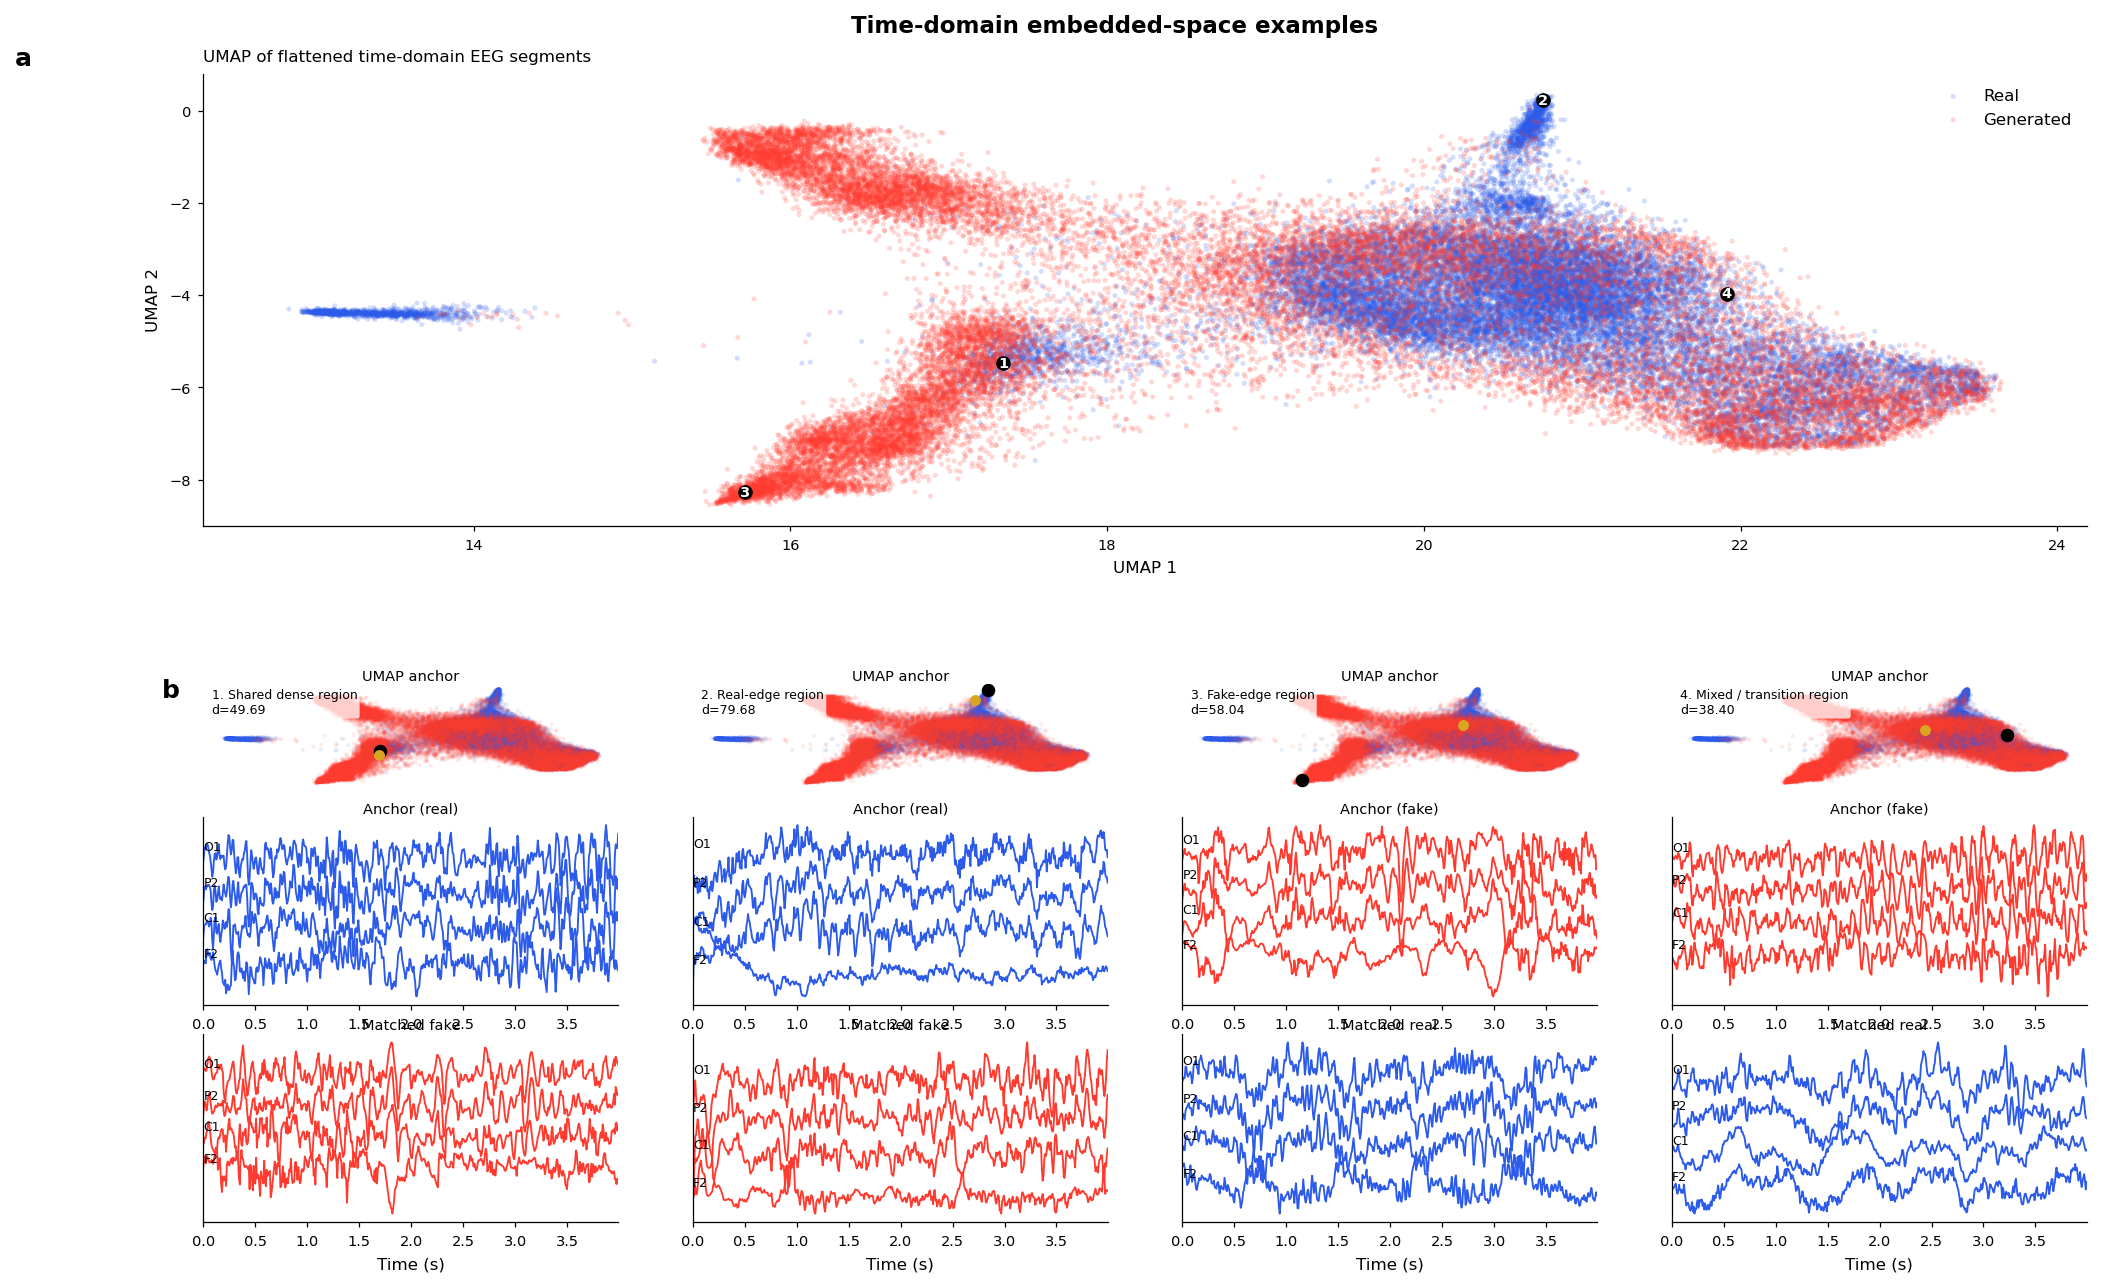

In [7]:
from sklearn.neighbors import NearestNeighbors
from umap import UMAP
from scipy.spatial.distance import cdist


# =============================================================================
# Data containers
# =============================================================================

@dataclass
class UMAPExemplar:
    name: str
    anchor_index_global: int
    anchor_label: str           # "real" or "fake"
    match_index_global: int
    match_label: str            # opposite class
    anchor_xy: np.ndarray       # (2,)
    match_xy: np.ndarray        # (2,)
    feature_distance: float


@dataclass
class UMAPFigureData:
    embedding: np.ndarray               # (N_total, 2)
    labels: np.ndarray                  # (N_total,), values "real"/"fake"
    x_real: np.ndarray                  # standardized input shape preserved
    x_fake: np.ndarray
    features_real: np.ndarray           # (N_real, D), standardized
    features_fake: np.ndarray           # (N_fake, D), standardized
    exemplars: List[UMAPExemplar]
    channel_names: List[str]
    fs: float
    channels_last: bool


# =============================================================================
# Style
# =============================================================================

def set_publication_style() -> None:
    plt.rcParams.update({
        "font.family": "sans-serif",
        "font.size": 8,
        "axes.titlesize": 8,
        "axes.labelsize": 8,
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
        "legend.fontsize": 8,
        "axes.linewidth": 0.6,
        "xtick.major.width": 0.6,
        "ytick.major.width": 0.6,
        "xtick.major.size": 2.5,
        "ytick.major.size": 2.5,
        "figure.dpi": 150,
        "savefig.dpi": 300,
    })


def add_panel_label(ax: plt.Axes, label: str) -> None:
    ax.text(
        -0.10, 1.06, label,
        transform=ax.transAxes,
        fontsize=12,
        fontweight="bold",
        va="top",
        ha="left",
    )


# =============================================================================
# Utilities
# =============================================================================

def _ensure_numpy(x):
    if hasattr(x, "detach"):
        x = x.detach().cpu().numpy()
    return np.asarray(x)


def _maybe_reorder_segments(
    x: np.ndarray,
    channels_last: bool = True,
) -> np.ndarray:
    """
    Returns segments in shape (n_segments, n_time, n_channels) if channels_last=True,
    else converts from (n_segments, n_channels, n_time) to that format for plotting.
    """
    x = _ensure_numpy(x)

    if x.ndim != 3:
        raise ValueError(f"Expected 3D array, got shape {x.shape}")

    if channels_last:
        return x
    else:
        return np.transpose(x, (0, 2, 1))


def flatten_segments(x: np.ndarray, channels_last: bool = True) -> np.ndarray:
    """
    x:
      if channels_last=True:  (n_segments, n_time, n_channels)
      if channels_last=False: (n_segments, n_channels, n_time)

    returns:
      (n_segments, n_time * n_channels)
    """
    x = _ensure_numpy(x)
    if channels_last:
        return x.reshape(x.shape[0], -1)
    else:
        return np.transpose(x, (0, 2, 1)).reshape(x.shape[0], -1)


def fit_zscore(A: np.ndarray, eps: float = 1e-12):
    mu = A.mean(axis=0, keepdims=True)
    sd = A.std(axis=0, keepdims=True, ddof=1)
    keep = (sd.ravel() > eps)
    return mu[:, keep], sd[:, keep], keep


def apply_zscore(A: np.ndarray, mu: np.ndarray, sd: np.ndarray, keep: np.ndarray):
    return (A[:, keep] - mu) / sd


# =============================================================================
# Anchor selection
# =============================================================================

def _compute_local_umap_stats(embedding: np.ndarray, labels: np.ndarray, k: int = 50):
    """
    labels: array of "real"/"fake"
    Returns local mean neighbor distance and local real fraction for each point.
    """
    n = embedding.shape[0]
    k = min(k, n - 1)

    nn = NearestNeighbors(n_neighbors=k + 1, metric="euclidean")
    nn.fit(embedding)
    dists, inds = nn.kneighbors(embedding)

    # exclude self
    dists = dists[:, 1:]
    inds = inds[:, 1:]

    mean_dist = dists.mean(axis=1)
    neighbor_labels = labels[inds]
    real_frac = (neighbor_labels == "real").mean(axis=1)

    return mean_dist, real_frac


def _pick_with_distance_constraint(
    candidate_indices: np.ndarray,
    embedding: np.ndarray,
    score: np.ndarray,
    already_picked: List[int],
    min_sep: float = 0.6,
) -> int:
    """
    Pick the highest-scoring candidate that is at least min_sep away in UMAP space
    from already picked anchors.
    """
    ordered = candidate_indices[np.argsort(score[candidate_indices])[::-1]]

    for idx in ordered:
        if len(already_picked) == 0:
            return int(idx)
        d = np.linalg.norm(embedding[already_picked] - embedding[idx], axis=1)
        if np.all(d >= min_sep):
            return int(idx)

    # fallback
    return int(ordered[0])


def select_umap_anchors(
    embedding: np.ndarray,
    labels: np.ndarray,
    min_sep: float = 0.6,
    local_k: int = 50,
) -> Dict[str, int]:
    """
    Auto-select 4 anchor points:
      - shared_dense
      - real_edge
      - fake_edge
      - mixed_transition
    """
    mean_dist, real_frac = _compute_local_umap_stats(embedding, labels, k=local_k)

    # dense = low mean_dist
    density_score = -mean_dist
    mixed_score = 1.0 - np.abs(real_frac - 0.5)

    picked = {}

    # 1) dense shared region
    cand_shared = np.where((real_frac > 0.35) & (real_frac < 0.65))[0]
    if len(cand_shared) == 0:
        cand_shared = np.arange(len(labels))
    score_shared = density_score + 1.5 * mixed_score
    idx_shared = _pick_with_distance_constraint(cand_shared, embedding, score_shared, [], min_sep=min_sep)
    picked["shared_dense"] = idx_shared

    # 2) real edge region
    cand_real_edge = np.where((labels == "real") & (real_frac > 0.80))[0]
    if len(cand_real_edge) == 0:
        cand_real_edge = np.where(labels == "real")[0]
    idx_real_edge = _pick_with_distance_constraint(
        cand_real_edge, embedding, density_score, [idx_shared], min_sep=min_sep
    )
    picked["real_edge"] = idx_real_edge

    # 3) fake edge region
    cand_fake_edge = np.where((labels == "fake") & (real_frac < 0.20))[0]
    if len(cand_fake_edge) == 0:
        cand_fake_edge = np.where(labels == "fake")[0]
    idx_fake_edge = _pick_with_distance_constraint(
        cand_fake_edge, embedding, density_score, [idx_shared, idx_real_edge], min_sep=min_sep
    )
    picked["fake_edge"] = idx_fake_edge

    # 4) mixed transition region
    cand_mixed = np.where((real_frac > 0.35) & (real_frac < 0.65))[0]
    if len(cand_mixed) == 0:
        cand_mixed = np.arange(len(labels))
    idx_mixed = _pick_with_distance_constraint(
        cand_mixed, embedding, mixed_score, [idx_shared, idx_real_edge, idx_fake_edge], min_sep=min_sep
    )
    picked["mixed_transition"] = idx_mixed

    return picked


# =============================================================================
# Matching in original feature space
# =============================================================================

def _match_opposite_class(
    anchor_index_global: int,
    labels: np.ndarray,
    features_real: np.ndarray,
    features_fake: np.ndarray,
    metric: str = "euclidean",
) -> Tuple[int, str, float]:
    """
    Returns:
      match_index_global, match_label, distance
    """
    n_real = features_real.shape[0]
    label = labels[anchor_index_global]

    if label == "real":
        local_idx = anchor_index_global
        d = cdist(features_real[[local_idx]], features_fake, metric=metric)[0]
        j = int(np.argmin(d))
        return n_real + j, "fake", float(d[j])

    else:
        local_idx = anchor_index_global - n_real
        d = cdist(features_fake[[local_idx]], features_real, metric=metric)[0]
        j = int(np.argmin(d))
        return j, "real", float(d[j])


def build_exemplars(
    embedding: np.ndarray,
    labels: np.ndarray,
    features_real: np.ndarray,
    features_fake: np.ndarray,
    match_metric: str = "euclidean",
    min_sep: float = 0.6,
    local_k: int = 50,
) -> List[UMAPExemplar]:
    picked = select_umap_anchors(
        embedding=embedding,
        labels=labels,
        min_sep=min_sep,
        local_k=local_k,
    )

    exemplar_names = [
        ("shared_dense", "Shared dense region"),
        ("real_edge", "Real-edge region"),
        ("fake_edge", "Fake-edge region"),
        ("mixed_transition", "Mixed / transition region"),
    ]

    exemplars = []
    for key, pretty_name in exemplar_names:
        anchor_idx = picked[key]
        match_idx, match_label, dist = _match_opposite_class(
            anchor_idx,
            labels,
            features_real,
            features_fake,
            metric=match_metric,
        )

        exemplars.append(
            UMAPExemplar(
                name=pretty_name,
                anchor_index_global=anchor_idx,
                anchor_label=str(labels[anchor_idx]),
                match_index_global=match_idx,
                match_label=match_label,
                anchor_xy=embedding[anchor_idx].copy(),
                match_xy=embedding[match_idx].copy(),
                feature_distance=dist,
            )
        )

    return exemplars


# =============================================================================
# Build figure data from real/fake segment arrays
# =============================================================================

def build_umap_figure_data(
    x_real,
    x_fake,
    fs: float = 128.0,
    channel_names: Optional[Sequence[str]] = None,
    channels_last: bool = True,
    umap_n_neighbors: int = 15,
    umap_min_dist: float = 0.1,
    umap_metric: str = "euclidean",
    match_metric: str = "euclidean",
    min_anchor_sep: float = 0.6,
    local_k: int = 50,
    random_state: int = 7,
) -> UMAPFigureData:
    """
    x_real, x_fake:
      segment arrays
      if channels_last=True:  (n_segments, n_time, n_channels)
      else:                   (n_segments, n_channels, n_time)
    """
    x_real = _ensure_numpy(x_real)
    x_fake = _ensure_numpy(x_fake)

    if channel_names is None:
        n_ch = x_real.shape[-1] if channels_last else x_real.shape[1]
        channel_names = [f"Ch{i+1}" for i in range(n_ch)]
    channel_names = list(channel_names)

    # original segment arrays preserved for plotting
    xr_plot = _maybe_reorder_segments(x_real, channels_last=channels_last)
    xg_plot = _maybe_reorder_segments(x_fake, channels_last=channels_last)

    # flatten in original high-dimensional segment space
    Fr = flatten_segments(x_real, channels_last=channels_last)
    Fg = flatten_segments(x_fake, channels_last=channels_last)

    # fit scaling on real only, apply to both
    mu, sd, keep = fit_zscore(Fr)
    Fr_z = apply_zscore(Fr, mu, sd, keep)
    Fg_z = apply_zscore(Fg, mu, sd, keep)

    # fit UMAP on pooled standardized segments
    pooled = np.vstack([Fr_z, Fg_z])
    labels = np.array(["real"] * len(Fr_z) + ["fake"] * len(Fg_z))

    umapper = UMAP(
        n_neighbors=umap_n_neighbors,
        min_dist=umap_min_dist,
        metric=umap_metric,
        random_state=random_state,
    )
    embedding = umapper.fit_transform(pooled)

    exemplars = build_exemplars(
        embedding=embedding,
        labels=labels,
        features_real=Fr_z,
        features_fake=Fg_z,
        match_metric=match_metric,
        min_sep=min_anchor_sep,
        local_k=local_k,
    )

    return UMAPFigureData(
        embedding=embedding,
        labels=labels,
        x_real=xr_plot,
        x_fake=xg_plot,
        features_real=Fr_z,
        features_fake=Fg_z,
        exemplars=exemplars,
        channel_names=channel_names,
        fs=fs,
        channels_last=True,   # plotting arrays are now standardized to (seg, time, ch)
    )


# =============================================================================
# Plotting helpers
# =============================================================================

def plot_umap_scatter(
    ax: plt.Axes,
    data: UMAPFigureData,
    alpha: float = 0.20,
    size: float = 6,
) -> None:
    emb = data.embedding
    labels = data.labels

    mask_r = labels == "real"
    mask_g = labels == "fake"

    ax.scatter(
        emb[mask_r, 0], emb[mask_r, 1],
        s=size, alpha=alpha, label="Real",
        color="#2C5BEA", edgecolors="none"
    )
    ax.scatter(
        emb[mask_g, 0], emb[mask_g, 1],
        s=size, alpha=alpha, label="Generated",
        color="#FF3B30", edgecolors="none"
    )

    # overlay numbered anchors
    for i, ex in enumerate(data.exemplars, start=1):
        ax.scatter(
            ex.anchor_xy[0], ex.anchor_xy[1],
            s=36, color="black", zorder=4
        )
        ax.text(
            ex.anchor_xy[0], ex.anchor_xy[1],
            str(i), color="white", fontsize=7, fontweight="bold",
            ha="center", va="center", zorder=5
        )

    ax.set_title("UMAP of flattened time-domain EEG segments", loc="left", pad=6)
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(frameon=False, loc="upper right")


def _get_segment_by_global_index(data: UMAPFigureData, global_idx: int) -> Tuple[np.ndarray, str]:
    n_real = data.x_real.shape[0]
    if global_idx < n_real:
        return data.x_real[global_idx], "real"
    else:
        return data.x_fake[global_idx - n_real], "fake"


def plot_segment_stack(
    ax: plt.Axes,
    segment: np.ndarray,                    # (time, channels)
    fs: float,
    channel_names: Sequence[str],
    selected_channels: Optional[Sequence[str]] = None,
    color: str = "black",
    title: Optional[str] = None,
) -> None:
    """
    Plot stacked time series for a single segment.
    """
    if selected_channels is None:
        # default to 4 spread-out channels if available
        if len(channel_names) >= 4:
            selected_channels = [channel_names[0], channel_names[len(channel_names)//3],
                                 channel_names[2*len(channel_names)//3], channel_names[-1]]
        else:
            selected_channels = list(channel_names)

    idx = [channel_names.index(ch) for ch in selected_channels]
    y = segment[:, idx]  # (time, n_sel)
    t = np.arange(y.shape[0]) / fs

    # z-score each selected channel within the segment just for display
    yy = y.copy()
    yy = (yy - yy.mean(axis=0, keepdims=True)) / (yy.std(axis=0, keepdims=True) + 1e-9)

    offsets = np.arange(len(idx))[::-1] * 3.0

    for k, ch in enumerate(selected_channels):
        ax.plot(t, yy[:, k] + offsets[k], color=color, lw=0.9)
        ax.text(t[0], offsets[k] + 0.9, ch, fontsize=6, ha="left", va="center")

    if title is not None:
        ax.set_title(title, fontsize=7, pad=2)

    ax.set_xlim(t[0], t[-1])
    ax.set_yticks([])
    ax.set_xlabel("Time (s)")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


def plot_exemplar_column(
    fig: plt.Figure,
    subspec,
    data: UMAPFigureData,
    exemplar: UMAPExemplar,
    exemplar_number: int,
    selected_channels: Optional[Sequence[str]] = None,
) -> List[plt.Axes]:
    """
    One exemplar column:
      tiny UMAP inset
      anchor segment
      matched segment
    """
    sub = subspec.subgridspec(3, 1, height_ratios=[0.55, 1.0, 1.0], hspace=0.18)

    # -------------------------------------------------------------------------
    # tiny UMAP inset
    # -------------------------------------------------------------------------
    ax0 = fig.add_subplot(sub[0, 0])

    emb = data.embedding
    labels = data.labels
    mask_r = labels == "real"
    mask_g = labels == "fake"

    ax0.scatter(emb[mask_r, 0], emb[mask_r, 1], s=4, alpha=0.10, color="#2C5BEA", edgecolors="none")
    ax0.scatter(emb[mask_g, 0], emb[mask_g, 1], s=4, alpha=0.10, color="#FF3B30", edgecolors="none")

    ax0.scatter(exemplar.anchor_xy[0], exemplar.anchor_xy[1], s=30, color="black", zorder=3)
    ax0.scatter(exemplar.match_xy[0], exemplar.match_xy[1], s=18, color="goldenrod", zorder=3)

    ax0.text(
        0.02, 0.96,
        f"{exemplar_number}. {exemplar.name}\nd={exemplar.feature_distance:.2f}",
        transform=ax0.transAxes,
        ha="left", va="top", fontsize=6,
        bbox=dict(boxstyle="round,pad=0.18", fc="white", ec="none", alpha=0.75),
    )
    ax0.set_xticks([])
    ax0.set_yticks([])
    ax0.set_title("UMAP anchor", fontsize=7, pad=2)
    for spine in ax0.spines.values():
        spine.set_visible(False)

    # -------------------------------------------------------------------------
    # anchor segment
    # -------------------------------------------------------------------------
    ax1 = fig.add_subplot(sub[1, 0])
    seg_anchor, lbl_anchor = _get_segment_by_global_index(data, exemplar.anchor_index_global)
    plot_segment_stack(
        ax1,
        segment=seg_anchor,
        fs=data.fs,
        channel_names=data.channel_names,
        selected_channels=selected_channels,
        color="#2C5BEA" if lbl_anchor == "real" else "#FF3B30",
        title=f"Anchor ({lbl_anchor})",
    )

    # -------------------------------------------------------------------------
    # matched opposite-class segment
    # -------------------------------------------------------------------------
    ax2 = fig.add_subplot(sub[2, 0])
    seg_match, lbl_match = _get_segment_by_global_index(data, exemplar.match_index_global)
    plot_segment_stack(
        ax2,
        segment=seg_match,
        fs=data.fs,
        channel_names=data.channel_names,
        selected_channels=selected_channels,
        color="#2C5BEA" if lbl_match == "real" else "#FF3B30",
        title=f"Matched {lbl_match}",
    )

    return [ax0, ax1, ax2]


# =============================================================================
# Main figure builder
# =============================================================================

def build_umap_exemplar_figure(
    data: UMAPFigureData,
    selected_channels: Optional[Sequence[str]] = None,
    figsize: Tuple[float, float] = (13.5, 8.8),
    save_path: Optional[str] = None,
) -> plt.Figure:
    set_publication_style()

    fig = plt.figure(figsize=figsize)
    outer = fig.add_gridspec(
        2, 4,
        height_ratios=[1.05, 1.25],
        width_ratios=[1, 1, 1, 1],
        left=0.05, right=0.98, top=0.95, bottom=0.08,
        hspace=0.32, wspace=0.18,
    )

    # -------------------------------------------------------------------------
    # a: UMAP scatter
    # -------------------------------------------------------------------------
    ax_a = fig.add_subplot(outer[0, :])
    plot_umap_scatter(ax_a, data)
    add_panel_label(ax_a, "a")

    # -------------------------------------------------------------------------
    # b: exemplar columns
    # -------------------------------------------------------------------------
    bottom_axes = []
    for i, ex in enumerate(data.exemplars):
        axes = plot_exemplar_column(
            fig,
            outer[1, i],
            data=data,
            exemplar=ex,
            exemplar_number=i + 1,
            selected_channels=selected_channels,
        )
        bottom_axes.extend(axes)

    add_panel_label(bottom_axes[0], "b")

    fig.suptitle(
        "Time-domain embedded-space examples",
        y=0.995,
        fontsize=11,
        fontweight="bold",
    )

    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight")

    return fig


# =============================================================================
# usage
# =============================================================================

if __name__ == "__main__":
    # Data Parameters
    TIME_DIM = 512
    N_SUBJECTS = 202
    CHANNELS = ['O1', 'O2', 'P1', 'P2', 'C1', 'C2', 'F1', 'F2']
    LATENT_DIM = 128

    # real data
    x, sub, state, _ = open_real_data(
        eeg_data_path='data/LEMON_DATA/EC_ch-8_sf-128.nc5',
        channels=CHANNELS,
        n_subjects=N_SUBJECTS,
        time_dim=TIME_DIM,
        condition='EC'
    )
    # fake data
    CHECKPOINTS_PATH = 'logs/eo/20260302_v2_best_gloss.model.keras'
    model = keras.saving.load_model(CHECKPOINTS_PATH, custom_objects={'FiLMGAN': FiLMGAN}, compile=False)
    with torch.no_grad():
        x_gen = generate_data(model, x, sub, state, N_SUBJECTS, latent_dim=LATENT_DIM, use_random_sub=False).cpu()

    data = build_umap_figure_data(
        x_real=x,
        x_fake=x_gen,
        fs=fs,
        channel_names=CHANNELS,
        channels_last=True,
        umap_n_neighbors=15,
        umap_min_dist=0.1,
        umap_metric="euclidean",
        match_metric="euclidean",
        min_anchor_sep=0.8,
        local_k=50,
        random_state=None,
    )

    fig = build_umap_exemplar_figure(
        data,
        selected_channels=["O1", "P2", "C1", "F2"],
        figsize=(13.5, 8.8),
        save_path=None,
    )
    plt.show()

TODOS:
- for EO? if EO is qualitatively similar to EC, we can say that in the caption and perhaps add a supplementary figure for EO.
- channel names and the titles in panel b should be placed in a better position.

For selected regions of the UMAP, we show representative anchor segments and their nearest opposite-class matches in the original segment space. This illustrates what samples from shared, edge, and transition regions of the embedding look like beyond the 2D projection.


in current figure:

- the shared / mixed regions do show broadly similar real–fake segments, which is what you would expect;

- the edge regions do not look dramatically different by eye in the raw traces;

- therefore, panel b currently works more as a grounding panel than as a strong “look how different these regions are” panel.

That is not a failure. It just means the exemplars are saying: these parts of the UMAP correspond to plausible EEG segments, and the central shared region contains visually similar real and generated snippets.

D shows the distance between the flattened 512×8 segment vectors in the original high-dimensional space..

# Figure 5: Individual-level analysis